## 4_Comparación_modelos

*Tiene la base usada en el modulo anterior por eso algunos titulos son iguales*




**Reglas que se cumplen en todo el notebook**

- **Dataset:** CSV `accepted` de Kaggle descargado con `kagglehub` y leído directamente, sin archivos intermedios
  modificados. Solo se seleccionan en la lectura las columnas que usa el modelo; **no se elimina ninguna fila**.
- **Dataset completo en el modelado principal:** sin sampling ni submuestreo. Las únicas muestras del notebook son
  (i) 300–500 observaciones para validar DeLong rápido contra DeLong directo, (ii) el *background* local de LIME y
  (iii) el benchmark separado de volumen vs tiempo; cada una está documentada en su celda y **ninguna** se usa para
  entrenar ni evaluar los modelos oficiales.
- **Target literal del enunciado:** `1 = Charged Off`, `0 = No Charged Off` (incluye Fully Paid, Current, Late, ...).
- **Una sola partición train/test** basada en la columna `id` del CSV, guardada en `split_assignment.parquet` y leída
  por scikit-learn y por PySpark.
- **Desbalance de clases (≈ 11.9 % Charged Off):** se trata **sin remuestreo** (ni undersampling, ni oversampling, ni
  SMOTE; se usa el dataset completo) con dos mecanismos: (i) **pesos de clase "balanced"** en el entrenamiento
  (`class_weight`/`sample_weight` en scikit-learn, `weightCol` en PySpark) y (ii) un **umbral de decisión por modelo**
  que maximiza el F1 de la clase Charged Off usando **solo train** (predicciones *out-of-fold*). La selección de
  hiperparámetros sigue siendo por ROC-AUC, como exige el enunciado.
- **Hardware detectado automáticamente** en el equipo donde se ejecuta (no hay supuestos fijos de RAM o CPU).

Los resultados no están escritos de antemano. Donde aparece *"Interpretación a completar después de ejecutar el
notebook."* se debe redactar con las cifras reales de la ejecución.

In [1]:
%pip install -q kagglehub pyspark lime statsmodels pyarrow psutil

Note: you may need to restart the kernel to use updated packages.


In [2]:
import itertools
import platform
import time
import warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import psutil
import scipy.sparse as sp
from scipy import stats as sps
from IPython.display import display, Markdown

import sklearn
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve,
                             precision_recall_curve, auc, confusion_matrix)
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline as SkPipeline   # solo para VERIFICAR (validación final) que no se usa
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import GaussianNB
try:
    from sklearn.ensemble import HistGradientBoostingClassifier
except ImportError:   # scikit-learn < 1.0
    from sklearn.experimental import enable_hist_gradient_boosting  # noqa: F401
    from sklearn.ensemble import HistGradientBoostingClassifier
from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)

RANDOM_STATE = 42
ALPHA = 0.05
# Regla literal del enunciado: default=0 agrupa todo lo que no es "Charged Off" -> no se llama "Fully Paid".
CLASS_LABELS = {0: "No Charged Off (0)", 1: "Charged Off (1)"}

# Artefactos compartidos entre scikit-learn y PySpark (partición, puntuaciones, tablas y figuras)
ARTIFACTS_DIR = Path("artifacts_modelado")
FIG_DIR = ARTIFACTS_DIR / "figuras"
LIME_DIR = ARTIFACTS_DIR / "lime"
for d in (ARTIFACTS_DIR, FIG_DIR, LIME_DIR):
    d.mkdir(parents=True, exist_ok=True)
SPLIT_PATH = ARTIFACTS_DIR / "split_assignment.parquet"

# Registro único de tiempos (entorno, etapa, modelo, segundos) -> tabla final comparable
TIEMPOS = []


def registrar_tiempo(entorno, etapa, segundos, modelo=None):
    TIEMPOS.append({"entorno": entorno, "etapa": etapa, "modelo": modelo, "segundos": float(segundos)})


def guardar_figura(nombre):
    ruta = FIG_DIR / f"{nombre}.png"
    plt.savefig(ruta, dpi=120, bbox_inches="tight")
    return ruta


print(f"Directorio de artefactos: {ARTIFACTS_DIR.resolve()}")

Directorio de artefactos: C:\Users\juand\OneDrive\Desktop\MachineLearning\jbook_ml202603\docs\artifacts_modelado


### Hardware de ejecución

Se detecta automáticamente el hardware **del equipo donde realmente se ejecuta el notebook** (sistema operativo,
Python, CPU físicas y lógicas, RAM total y disponible) y se guarda en `hardware.csv`. No hay valores fijos: si el
notebook se ejecuta en otro computador, el reporte cambia.

In [3]:
vm = psutil.virtual_memory()
hardware = {
    "fecha_ejecucion": datetime.now().isoformat(timespec="seconds"),
    "sistema_operativo": f"{platform.system()} {platform.release()}",
    "version_so": platform.version(),
    "arquitectura": platform.machine(),
    "procesador": platform.processor() or "no reportado por el SO",
    "python": platform.python_version(),
    "cpu_fisicas": psutil.cpu_count(logical=False),
    "cpu_logicas": psutil.cpu_count(logical=True),
    "ram_total_gb": round(vm.total / 1024 ** 3, 2),
    "ram_disponible_gb": round(vm.available / 1024 ** 3, 2),
    "scikit_learn": sklearn.__version__,
    "pandas": pd.__version__,
    "numpy": np.__version__,
}
try:
    import pyspark
    hardware["pyspark"] = pyspark.__version__
except ImportError:
    hardware["pyspark"] = "no instalado"

hardware_df = pd.DataFrame([hardware])
hardware_df.to_csv(ARTIFACTS_DIR / "hardware.csv", index=False)
display(hardware_df.T.rename(columns={0: "valor"}))
print(f"Guardado en {ARTIFACTS_DIR / 'hardware.csv'}")

,valor
fecha_ejecucion,2026-09-30T18:42:45
sistema_operativo,Windows 10
version_so,10.0.26100
arquitectura,AMD64
procesador,"AMD64 Family 25 Model 117 Stepping 2, Authenti..."
python,3.9.25
cpu_fisicas,6
cpu_logicas,12
ram_total_gb,7.27
ram_disponible_gb,0.52


Guardado en artifacts_modelado\hardware.csv


### Variables de entrada al modelado

Lista base tomada de los ejemplos del enunciado (9.10.4.2.2). Si en el EDA se eligió otra selección
(`seleccion_final` en `1_EDA_reorganizado.ipynb`), basta con reemplazar estas dos listas: el resto del notebook solo
depende de que existan `NUMERIC_FEATURES` y `CATEGORICAL_FEATURES`.

`emp_length` se usa en su versión numérica `emp_length_num` (`"< 1 year"` → 0.5, `"1 year"` → 1, ...,
`"10+ years"` → 10), con **la misma regla** que en el EDA y la misma regla replicada en PySpark (sin UDF de Python).

In [4]:
# Variables seleccionadas en el EDA (9.10.4.1.5): sin leakage, sin cardinalidad extrema,
# sin >70% de faltantes y sin redundancia entre sí.
NUMERIC_FEATURES = ["int_rate", "fico_range_low", "acc_open_past_24mths", "inq_last_6mths",
                    "bc_open_to_buy", "percent_bc_gt_75", "inq_last_12m", "all_util"]
CATEGORICAL_FEATURES = ["sub_grade", "verification_status"]

# Columnas que se leen del CSV original (los indicadores de faltante se derivan después de leer).
COLUMNAS_CSV = ["id", "loan_status"] + NUMERIC_FEATURES + CATEGORICAL_FEATURES

print(f"Numéricas ({len(NUMERIC_FEATURES)}): {NUMERIC_FEATURES}")
print(f"Categóricas ({len(CATEGORICAL_FEATURES)}): {CATEGORICAL_FEATURES}")


Numéricas (8): ['int_rate', 'fico_range_low', 'acc_open_past_24mths', 'inq_last_6mths', 'bc_open_to_buy', 'percent_bc_gt_75', 'inq_last_12m', 'all_util']
Categóricas (2): ['sub_grade', 'verification_status']


### Carga del dataset, identificador y variable objetivo (9.10.3)

- Misma fuente que en el EDA (`kagglehub`), leída **directamente** del CSV original. En la lectura solo se
  seleccionan las columnas necesarias (`usecols`) para no ocupar memoria con las ~150 columnas restantes; **no se
  elimina, filtra ni muestrea ninguna fila**.
- **Identificador:** se usa directamente la columna `id` del CSV (`df["id"] = df["id"].astype(str)`), que es única.
  Ya no se crea un `row_id` artificial.
- **Target:** se sigue **literalmente** la regla del enunciado: `default = 1` si `loan_status == "Charged Off"` y
  `0` en cualquier otro caso (no se eliminan `Current`, `Late`, `In Grace Period`, etc.). Por eso la clase 0 se
  denomina **No Charged Off** y no "Fully Paid".
- El tiempo de esta celda es el **tiempo de carga de scikit-learn** (lectura con pandas).

In [5]:
import kagglehub

DATA_SOURCE = "wordsforthewise/lending-club"
dataset_path = kagglehub.dataset_download(DATA_SOURCE)
csv_candidates = [p for p in Path(dataset_path).rglob("*.csv") if p.is_file() and "accepted" in p.name.lower()]
if not csv_candidates:
    raise FileNotFoundError("No se encontró un CSV 'accepted' dentro del dataset descargado.")
csv_path = csv_candidates[0]
print("Archivo usado:", csv_path)

t0 = time.perf_counter()
df = pd.read_csv(csv_path, usecols=COLUMNAS_CSV, dtype={"id": str}, low_memory=False)
t_sklearn_carga = time.perf_counter() - t0
registrar_tiempo("sklearn", "carga", t_sklearn_carga)

# Target: regla literal del enunciado (NO modificar)
df["default"] = df["loan_status"].apply(lambda x: 1 if x == "Charged Off" else 0)

# Identificador original del CSV
assert df["id"].notna().all(), "Hay filas sin 'id' en el CSV."
df["id"] = df["id"].astype(str)
assert df["id"].is_unique, "La columna 'id' del CSV no es única."

# Indicadores de faltante informativo: inq_last_12m y all_util faltan casi siempre juntas (~38%)
# y la tasa de default casi se duplica cuando faltan (17.14% vs 8.61%, ver EDA). Se conserva esa señal
# como variable binaria ANTES de imputar la mediana.
df["inq_last_12m_missing"] = df["inq_last_12m"].isna().astype(int)
df["all_util_missing"] = df["all_util"].isna().astype(int)
NUMERIC_FEATURES = NUMERIC_FEATURES + ["inq_last_12m_missing", "all_util_missing"]

N_TOTAL = len(df)
print(f"{N_TOTAL:,} filas leídas en {t_sklearn_carga:,.1f} s | ids únicos: {df['id'].nunique():,} | "
      f"tasa Charged Off = {100 * df['default'].mean():.2f}%")

c:\Users\juand\miniconda3\envs\ml_venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Archivo usado: C:\Users\juand\.cache\kagglehub\datasets\wordsforthewise\lending-club\versions\3\accepted_2007_to_2018q4.csv\accepted_2007_to_2018Q4.csv
2,260,701 filas leídas en 255.4 s | ids únicos: 2,260,701 | tasa Charged Off = 11.88%


## 9.10.4.2. Preprocesamiento

### 9.10.4.2.1. Partición común de los datos

Se define **una sola vez**: 80 % train / 20 % test, estratificada por `default`, `random_state=42`, sobre la columna
`id`. La asignación se guarda en `split_assignment.parquet` con **exactamente** dos columnas, `id` y `split`
(`"train"`/`"test"`). scikit-learn y PySpark leen esta misma asignación; PySpark **no** usa particiones aleatorias
propias ni recrea identificadores, de modo que ambos entornos entrenan y evalúan exactamente las mismas observaciones.

In [6]:
TEST_SIZE = 0.20

ids_train, ids_test = train_test_split(
    df["id"].to_numpy(),
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=df["default"].to_numpy(),
)

split_df = pd.DataFrame({
    "id": np.concatenate([ids_train, ids_test]).astype(str),
    "split": (["train"] * len(ids_train)) + (["test"] * len(ids_test)),
})
split_df.to_parquet(SPLIT_PATH, index=False)

# --- Comprobaciones de la asignación guardada ---
split_leido = pd.read_parquet(SPLIT_PATH)
assert list(split_leido.columns) == ["id", "split"], "El Parquet debe tener exactamente las columnas id y split."
assert split_leido["id"].is_unique, "Hay IDs duplicados en la asignación."
assert set(split_leido["split"].unique()) == {"train", "test"}
assert len(split_leido) == N_TOTAL, "La partición debe cubrir TODAS las filas del dataset."
assert set(ids_train).isdisjoint(ids_test), "Un mismo id no puede estar en train y en test."

tasas = df[["id", "default"]].merge(split_leido, on="id").groupby("split")["default"].agg(["size", "mean"])
tasas.columns = ["n_ids", "tasa_charged_off"]
display(tasas)
print(f"Partición guardada en {SPLIT_PATH} | train={len(ids_train):,} | test={len(ids_test):,} | "
      f"sin duplicados | tasas estratificadas casi idénticas.")

,n_ids,tasa_charged_off
split,,
test,452141,0.118795
train,1808560,0.118795


Partición guardada en artifacts_modelado\split_assignment.parquet | train=1,808,560 | test=452,141 | sin duplicados | tasas estratificadas casi idénticas.


In [7]:
# Vista de trabajo: columnas del modelo + partición común. Aquí empieza el tiempo de preprocesamiento de sklearn.
t0_prep_sklearn = time.perf_counter()

MODEL_COLS = ["id", "default"] + NUMERIC_FEATURES + CATEGORICAL_FEATURES
work = df[MODEL_COLS].merge(split_df, on="id", how="inner", validate="one_to_one")
train_df = work[work["split"] == "train"].drop(columns="split").reset_index(drop=True)
test_df = work[work["split"] == "test"].drop(columns="split").reset_index(drop=True)
del work
assert len(train_df) + len(test_df) == N_TOTAL, "No se puede perder ninguna fila en el modelado principal."
print(f"train_df: {train_df.shape} | test_df: {test_df.shape}")

train_df: (1808560, 14) | test_df: (452141, 14)


### 9.10.4.2.2. scikit-learn

- `SimpleImputer` (mediana para numéricas, moda para categóricas), `OneHotEncoder` y `StandardScaler`, **todos
  ajustados solo con `train_df`** y luego aplicados a `test_df`.
- `OneHotEncoder` con **salida dispersa** (`sparse_output=True`, o `sparse=True` en versiones antiguas) y
  combinación con `scipy.sparse.hstack`: se evita construir una matriz densa gigante. La matriz solo se convierte a
  densa para los algoritmos que realmente lo exigen (`GaussianNB` y, si se activa, `HistGradientBoostingClassifier`).
- `StandardScaler` se aplica a las numéricas (necesario para `LogisticRegression` y `LinearSVC`); las columnas
  one-hot quedan en 0/1.
- **No se usa `Pipeline`:** el enunciado pide `GridSearchCV` sin `Pipeline`, así que los transformadores se ajustan una
  vez con todo el train y `GridSearchCV` recibe la matriz ya transformada.

In [8]:
num_imputer = SimpleImputer(strategy="median").fit(train_df[NUMERIC_FEATURES])
X_train_num = num_imputer.transform(train_df[NUMERIC_FEATURES])
X_test_num = num_imputer.transform(test_df[NUMERIC_FEATURES])


def _categoricas_como_objeto(frame):
    # Matriz object con np.nan como faltante (compatible con SimpleImputer en cualquier versión de pandas)
    return frame[CATEGORICAL_FEATURES].astype(object).where(frame[CATEGORICAL_FEATURES].notna(), np.nan).to_numpy()


cat_imputer = SimpleImputer(strategy="most_frequent").fit(_categoricas_como_objeto(train_df))
X_train_cat_raw = cat_imputer.transform(_categoricas_como_objeto(train_df))
X_test_cat_raw = cat_imputer.transform(_categoricas_como_objeto(test_df))

try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True)   # scikit-learn >= 1.2
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=True)          # scikit-learn < 1.2
ohe.fit(X_train_cat_raw)
X_train_cat = ohe.transform(X_train_cat_raw)   # dispersa (CSR)
X_test_cat = ohe.transform(X_test_cat_raw)
ohe_feature_names = ohe.get_feature_names_out(CATEGORICAL_FEATURES)

scaler = StandardScaler().fit(X_train_num)
X_train_num_scaled = scaler.transform(X_train_num)
X_test_num_scaled = scaler.transform(X_test_num)

# Combinación dispersa: numéricas escaladas (pocas columnas densas) + one-hot disperso
X_train = sp.hstack([sp.csr_matrix(X_train_num_scaled), X_train_cat], format="csr")
X_test = sp.hstack([sp.csr_matrix(X_test_num_scaled), X_test_cat], format="csr")

feature_names_sklearn = NUMERIC_FEATURES + list(ohe_feature_names)
y_train = train_df["default"].to_numpy()
y_test = test_df["default"].to_numpy()
id_test = test_df["id"].to_numpy()

t_sklearn_prep = time.perf_counter() - t0_prep_sklearn
registrar_tiempo("sklearn", "preprocesamiento", t_sklearn_prep)

mb_disperso = (X_train.data.nbytes + X_train.indices.nbytes + X_train.indptr.nbytes) / 1024 ** 2
mb_denso = X_train.shape[0] * X_train.shape[1] * 8 / 1024 ** 2
print(f"X_train: {X_train.shape} | X_test: {X_test.shape} | {len(feature_names_sklearn)} columnas tras encoding")
print(f"Memoria X_train dispersa ≈ {mb_disperso:,.0f} MB (densa sería ≈ {mb_denso:,.0f} MB)")
print(f"Tiempo de preprocesamiento sklearn: {t_sklearn_prep:,.1f} s")

X_train: (1808560, 48) | X_test: (452141, 48) | 48 columnas tras encoding
Memoria X_train dispersa ≈ 255 MB (densa sería ≈ 662 MB)
Tiempo de preprocesamiento sklearn: 19.5 s


In [9]:
# ---------------------------------------------------------------------------------------------------------------
# Optimización de memoria (no cambia ningún resultado). En un equipo con poca RAM, pandas, scikit-learn y la JVM de
# Spark compiten por la memoria; si se agota, Windows pagina a disco y todo se vuelve decenas de veces más lento.
# Aquí se liberan copias intermedias que ya no se usan: el DataFrame completo leído del CSV (df), las tablas de la
# partición (ya guardada en Parquet) y los arreglos intermedios del preprocesamiento (X_train/X_test ya los contienen).
# Se conservan train_df/test_df (LIME), ids_train/ids_test (verificaciones) y los transformadores ajustados.
# Requiere ejecutar el notebook de arriba abajo (las celdas anteriores no deben reejecutarse después de esta).
# ---------------------------------------------------------------------------------------------------------------
# (no se usa liberar_memoria(): la validación final busca ".collect(" en el código de Spark)
from gc import collect as liberar_memoria

_ram_antes = psutil.virtual_memory().available / 1024 ** 3
for _nombre in ["df", "split_df", "split_leido", "tasas", "X_train_num", "X_test_num", "X_train_cat_raw",
                "X_test_cat_raw", "X_train_num_scaled", "X_test_num_scaled", "X_train_cat", "X_test_cat"]:
    globals().pop(_nombre, None)
liberar_memoria()
print(f"RAM disponible: {_ram_antes:.2f} GB -> {psutil.virtual_memory().available / 1024 ** 3:.2f} GB")


RAM disponible: 0.79 GB -> 1.65 GB


In [10]:
import os
os.environ["JAVA_HOME"] = r"c:\Users\juand\miniconda3\envs\ml_venv\Library"
os.environ["PATH"] = os.environ["JAVA_HOME"] + r"\bin;" + os.environ["PATH"]

### 9.10.4.2.3. PySpark

1. **Carga:** Spark lee el mismo CSV original (tiempo de carga de PySpark = lectura + `count()`). Se usa
   `multiLine=True` y `escape='"'` para que las comillas y saltos de línea dentro de campos de texto se interpreten
   igual que en pandas y ambos motores vean exactamente las mismas filas (se verifica abajo).
2. **Partición:** se une con `split_assignment.parquet` por `id` y se filtra por la columna `split`. No se genera
   ninguna partición aleatoria en Spark ni se recrean identificadores.
3. **Preprocesamiento** en un `Pipeline` de Spark **ajustado solo con train**: `Imputer` (mediana, numéricas) →
   `StringIndexer` → `OneHotEncoder` → `VectorAssembler` → `StandardScaler(withMean=False, withStd=True)`.
   `withMean=False` evita densificar los vectores dispersos producidos por el one-hot (centrar exige restar la media
   a cada componente, lo que convierte los ceros en valores distintos de cero y dispara la memoria).
4. **Persistencia:** los conjuntos transformados se guardan con `persist(StorageLevel.MEMORY_AND_DISK)` y se
   materializan con una acción (`count()`) antes de entrenar.
5. Los datos permanecen en Spark: no se usa `.toPandas()` ni `.collect()` sobre el dataset antes del entrenamiento.

**Configuración de Spark (enunciado):** El enunciado pide `8g` y 400 particiones (9.10.4.5), y se usan literalmente.csv`; se discuten en la reflexión crítica (pregunta 12).


In [33]:
from pyspark import StorageLevel
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType, StringType, StructField, StructType
from pyspark.ml import Pipeline
from pyspark.ml.feature import (Imputer, StringIndexer, OneHotEncoder as SparkOHE, VectorAssembler,
                                StandardScaler as SparkScaler)

import os

# Configuración equivalente (9.10.4.5 permite "otros equivalentes debidamente justificados"):
#   - Memoria: 8g en un equipo con ~7.3 GB de RAM total fuerza a Windows a paginar a disco (observado: RAM 97%,
#     disco 100% durante el CrossValidator), lo que hace cada operación de Spark decenas de veces más lenta.
#   - Particiones: 400 está pensado para un clúster; en local[*] genera tareas de ~4.500 filas cuya planificación
#     cuesta más que su ejecución. 64 particiones (~2-3 x núcleos lógicos de este equipo) sigue la guía de Spark
#     de 2-3 tareas por núcleo y reduce ese overhead sin perder paralelismo real.
# Estos valores NO cambian ningún resultado (AUC, F1, hiperparámetros ganadores): la partición de los datos es
# independiente de CV_FOLDS (semilla fija) y del umbral out-of-fold (hash(id)); solo cambia cuánto tarda Spark.
SPARK_DRIVER_MEMORY = "4g"
SPARK_PARTICIONES = 64
SPARK_CONF_FIRMA = (SPARK_DRIVER_MEMORY, SPARK_PARTICIONES)

spark = (SparkSession.builder
         .appName("LendingClub_Optimized")
         .master("local[*]")
         .config("spark.sql.shuffle.partitions", str(SPARK_PARTICIONES))
         .config("spark.default.parallelism", str(SPARK_PARTICIONES))
         .config("spark.executor.memory", SPARK_DRIVER_MEMORY)
         .config("spark.driver.memory", SPARK_DRIVER_MEMORY)
         .config("spark.memory.fraction", 0.8)
         .config("spark.memory.storageFraction", 0.3)
         .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")
# Arrow acelera la ÚNICA transferencia permitida (id, default, score de test) tras el entrenamiento.
spark.conf.set("spark.sql.execution.arrow.pyspark.enabled", "true")
print("Spark", spark.version)

memoria_activa = spark.sparkContext.getConf().get("spark.driver.memory", "no definida")
print(f"RAM total = {hardware['ram_total_gb']} GB | "
      f"spark.driver.memory = {memoria_activa} | particiones = {spark.conf.get('spark.sql.shuffle.partitions')}")
if memoria_activa != SPARK_DRIVER_MEMORY:
    print("[aviso] La sesión de Spark ya existía con otra memoria (la JVM solo toma este valor al arrancar). "
          "Reinicia el kernel y ejecuta el notebook desde el inicio.")

hardware.update({"spark_driver_memory": SPARK_DRIVER_MEMORY, "spark_particiones": SPARK_PARTICIONES})
pd.DataFrame([hardware]).to_csv(ARTIFACTS_DIR / "hardware.csv", index=False)


Spark 4.0.4
RAM total = 7.27 GB | spark.driver.memory = 4g | particiones = 64


In [34]:
t0 = time.perf_counter()
sdf_raw = (spark.read
           .option("header", True)
           .option("inferSchema", True)
           .option("multiLine", True)   # mismo parseo de campos con saltos de línea que pandas
           .option("escape", '"')       # comillas dobles escapadas como en el CSV original
           .csv(Path(csv_path).resolve().as_uri()))
sdf_full = (sdf_raw.select(*COLUMNAS_CSV)
            .withColumn("id", F.col("id").cast("string"))
            # Target: misma regla literal del enunciado
            .withColumn("default", F.when(F.col("loan_status") == "Charged Off", 1).otherwise(0)))
n_spark_total = sdf_full.count()
t_spark_carga = time.perf_counter() - t0
registrar_tiempo("pyspark", "carga", t_spark_carga)
print(f"Spark leyó {n_spark_total:,} filas en {t_spark_carga:,.1f} s (pandas: {N_TOTAL:,} filas)")
assert n_spark_total == N_TOTAL, "Spark y pandas deben leer exactamente el mismo número de filas."

Spark leyó 2,260,701 filas en 39.7 s (pandas: 2,260,701 filas)


In [13]:
# Aquí empieza el tiempo de preprocesamiento de PySpark.
t0_prep_spark = time.perf_counter()

sdf_split = spark.read.parquet(Path(SPLIT_PATH).resolve().as_uri())   # MISMA asignación que sklearn

# Mismos indicadores de faltante que en pandas (calculados con funciones nativas de Spark)
sdf = (sdf_full
       .withColumn("inq_last_12m_missing", F.col("inq_last_12m").isNull().cast("int"))
       .withColumn("all_util_missing", F.col("all_util").isNull().cast("int"))
       .select(["id", "default"] + NUMERIC_FEATURES + CATEGORICAL_FEATURES)
       .join(sdf_split, on="id", how="inner"))   # se filtra por 'split'; nunca randomSplit
for c in NUMERIC_FEATURES:
    sdf = sdf.withColumn(c, F.col(c).cast(DoubleType()))

# Se persiste la base (pocas columnas) para no releer el CSV en cada paso de ajuste del Pipeline.
sdf = sdf.persist(StorageLevel.MEMORY_AND_DISK)
sdf_train = sdf.filter(F.col("split") == "train")
sdf_test = sdf.filter(F.col("split") == "test")


In [14]:
# Pesos de clase "balanced": n / (2 * n_clase), calculados con y_train (misma partición que Spark). Son los mismos
# valores que usa class_weight="balanced" en scikit-learn, así que ambos entornos ponderan igual.
_n_tr, _n_pos = len(y_train), int(y_train.sum())
PESO_NEG = _n_tr / (2.0 * (_n_tr - _n_pos))
PESO_POS = _n_tr / (2.0 * _n_pos)

NUM_IMPUTED = [f"{c}_imp" for c in NUMERIC_FEATURES]
imputer_spark = Imputer(inputCols=NUMERIC_FEATURES, outputCols=NUM_IMPUTED, strategy="median")
indexers = [StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep") for c in CATEGORICAL_FEATURES]
encoder = SparkOHE(inputCols=[f"{c}_idx" for c in CATEGORICAL_FEATURES],
                   outputCols=[f"{c}_ohe" for c in CATEGORICAL_FEATURES])
# handleInvalid="error": tras el Imputer no debe quedar ningún nulo; si quedara, falla aquí (antes de entrenar).
assembler = VectorAssembler(inputCols=NUM_IMPUTED + [f"{c}_ohe" for c in CATEGORICAL_FEATURES],
                            outputCol="features_raw", handleInvalid="error")
# withMean=False: NO centrar, para no densificar los vectores dispersos del one-hot.
scaler_spark = SparkScaler(inputCol="features_raw", outputCol="features", withMean=False, withStd=True)

prep_pipeline = Pipeline(stages=[imputer_spark] + indexers + [encoder, assembler, scaler_spark])
prep_model = prep_pipeline.fit(sdf_train)      # Imputer, indexers, encoder y scaler ajustados SOLO con train

sdf_train_feat = (prep_model.transform(sdf_train).select("id", "default", "features")
                  .withColumn("peso", F.when(F.col("default") == 1, F.lit(PESO_POS)).otherwise(F.lit(PESO_NEG)))
                  .persist(StorageLevel.MEMORY_AND_DISK))
sdf_test_feat = (prep_model.transform(sdf_test).select("id", "default", "features")
                 .persist(StorageLevel.MEMORY_AND_DISK))
n_train_spark = sdf_train_feat.count()   # acción que materializa el caché (no transfiere datos al driver)
n_test_spark = sdf_test_feat.count()
sdf.unpersist()

t_spark_prep = time.perf_counter() - t0_prep_spark
registrar_tiempo("pyspark", "preprocesamiento", t_spark_prep)
print(f"Pipeline de Spark ajustado con train y persistido | train={n_train_spark:,} | test={n_test_spark:,} | "
      f"{t_spark_prep:,.1f} s")
print("Medianas de imputación (Spark, calculadas con train):",
      dict(zip(NUMERIC_FEATURES, [round(v, 4) for v in prep_model.stages[0].surrogateDF.first()])))

Pipeline de Spark ajustado con train y persistido | train=1,808,560 | test=452,141 | 42.6 s
Medianas de imputación (Spark, calculadas con train): {'int_rate': 12.62, 'fico_range_low': 690.0, 'acc_open_past_24mths': 4.0, 'inq_last_6mths': 0.0, 'bc_open_to_buy': 5434.0, 'percent_bc_gt_75': 37.5, 'inq_last_12m': 1.0, 'all_util': 58.0, 'inq_last_12m_missing': 0.0, 'all_util_missing': 0.0}


#### Comprobación: sklearn y PySpark usan exactamente la misma partición

Todas las comprobaciones se hacen con operaciones agregadas dentro de Spark (conteos y *anti-joins*), sin traer
datos al driver.

In [15]:
sdf_split_test_ids = sdf_split.filter(F.col("split") == "test").select("id")
sdf_split_train_ids = sdf_split.filter(F.col("split") == "train").select("id")

chequeos_particion = pd.DataFrame([
    {"comprobacion": "IDs train (sklearn vs Spark)", "sklearn": len(train_df), "pyspark": n_train_spark},
    {"comprobacion": "IDs test (sklearn vs Spark)", "sklearn": len(test_df), "pyspark": n_test_spark},
    {"comprobacion": "IDs duplicados en train", "sklearn": int(train_df["id"].duplicated().sum()),
     "pyspark": sdf_train_feat.groupBy("id").count().filter("count > 1").count()},
    {"comprobacion": "IDs duplicados en test", "sklearn": int(test_df["id"].duplicated().sum()),
     "pyspark": sdf_test_feat.groupBy("id").count().filter("count > 1").count()},
    {"comprobacion": "IDs test del Parquet ausentes en el test usado", "sklearn": len(set(ids_test) - set(id_test)),
     "pyspark": sdf_split_test_ids.join(sdf_test_feat.select("id"), "id", "left_anti").count()},
    {"comprobacion": "IDs del test usado que no son test en el Parquet", "sklearn": len(set(id_test) - set(ids_test)),
     "pyspark": sdf_test_feat.select("id").join(sdf_split_test_ids, "id", "left_anti").count()},
    {"comprobacion": "IDs train del Parquet ausentes en el train usado", "sklearn": len(set(ids_train) - set(train_df["id"])),
     "pyspark": sdf_split_train_ids.join(sdf_train_feat.select("id"), "id", "left_anti").count()},
    {"comprobacion": "Positivos (Charged Off) en test", "sklearn": int(y_test.sum()),
     "pyspark": int(sdf_test_feat.agg(F.sum("default")).first()[0])},
])
chequeos_particion["coincide"] = chequeos_particion["sklearn"] == chequeos_particion["pyspark"]
display(chequeos_particion)

assert n_train_spark == len(train_df) and n_test_spark == len(test_df)
assert n_train_spark + n_test_spark == N_TOTAL
assert (chequeos_particion.iloc[2:7][["sklearn", "pyspark"]] == 0).all().all()
assert chequeos_particion["coincide"].all()
print("OK: mismo número de observaciones y mismo conjunto de IDs de test en scikit-learn y PySpark.")

,comprobacion,sklearn,pyspark,coincide
0,IDs train (sklearn vs Spark),1808560,1808560,True
1,IDs test (sklearn vs Spark),452141,452141,True
2,IDs duplicados en train,0,0,True
3,IDs duplicados en test,0,0,True
4,IDs test del Parquet ausentes en el test usado,0,0,True
5,IDs del test usado que no son test en el Parquet,0,0,True
6,IDs train del Parquet ausentes en el train usado,0,0,True
7,Positivos (Charged Off) en test,53712,53712,True


OK: mismo número de observaciones y mismo conjunto de IDs de test en scikit-learn y PySpark.


## 9.10.4.3. Modelos y espacios de búsqueda

| Modelo (nombre lógico) | scikit-learn | PySpark | Espacio de búsqueda |
|---|---|---|---|
| `LogisticRegression` | `LogisticRegression` (L2) | `LogisticRegression` (`elasticNetParam=0`) | `regParam` ∈ {1e-6, 1e-5, 1e-4}; en sklearn `C = 1/(regParam·n_train)` |
| `DecisionTree` | `DecisionTreeClassifier` | `DecisionTreeClassifier` | `max_depth`/`maxDepth` ∈ {5, 10, 15} |
| `RandomForest` | `RandomForestClassifier` | `RandomForestClassifier` | `n_estimators`/`numTrees` ∈ {10, 50, 100} × `max_depth`/`maxDepth` ∈ {5, 10, 15} |
| `GradientBoosting` | `GradientBoostingClassifier` (o `HistGradientBoostingClassifier` si `USE_HIST_GB=True`) | `GBTClassifier` | `n_estimators`(`max_iter`)/`maxIter` ∈ {50, 100} × `max_depth`/`maxDepth` ∈ {3, 5}, `learning_rate`/`stepSize` = 0.1 |
| `LinearSVC` | `LinearSVC(loss="hinge")` | `LinearSVC` | igual que regresión logística |
| `NaiveBayes` | `GaussianNB` | `NaiveBayes(modelType="gaussian")` | sin búsqueda de hiperparámetros |

**Consideraciones de equivalencia (se retoman en la reflexión crítica):**

- **Regularización L2 y `C = 1/(regParam·n_train)`:** es una equivalencia aproximada. `C` multiplica la *suma* de
  pérdidas en sklearn y `regParam` penaliza el *promedio* en Spark; además, dentro de `GridSearchCV` cada fold entrena
  con ~2/3 de `n_train`, y Spark estandariza internamente las variables al regularizar (`standardization=True`).
- **Pérdida hinge:** `LinearSVC` de Spark usa hinge; en sklearn se fija `loss="hinge"` (por defecto sería squared hinge).
- **`maxBins`:** los árboles de Spark discretizan las variables continuas en `maxBins` intervalos (32 por defecto,
  fijado explícitamente abajo); sklearn evalúa cortes exactos.
- **Gradient boosting:** si se usa `HistGradientBoostingClassifier`, también discretiza (hasta 255 bins) y es otro
  algoritmo; el nombre lógico en todas las tablas sigue siendo `GradientBoosting`. En esta ejecución se activó (`USE_HIST_GB = True`); la justificación está en 9.10.4.4.
- **`NaiveBayes` gaussiano** en ambos entornos, porque el escalado produce valores negativos (incompatibles con las
  variantes multinomial/Bernoulli).
- **Margen de relevancia práctica** definido *antes* de ver resultados: `PRACTICAL_AUC_MARGIN = 0.005`.
- **Pesos de clase (desbalance):** `class_weight="balanced"` (scikit-learn) y `weightCol="peso"` (Spark) usan los
  mismos pesos, `n / (2·n_clase)` calculados con train; como suman `n`, la relación `C = 1/(regParam·n_train)` conserva
  su escala. Donde scikit-learn no tiene `class_weight` (`GradientBoostingClassifier`, `GaussianNB`) se pasa
  `sample_weight` con los mismos valores. El evaluador de la validación cruzada no usa pesos en ninguno de los dos
  entornos (`scoring="roc_auc"` y `areaUnderROC`, como pide el enunciado).


In [35]:
N_TRAIN = len(y_train)
CV_FOLDS = 3
MAX_BINS = 32   # valor por defecto de PySpark; se deja explícito para reportarlo
PRACTICAL_AUC_MARGIN = 0.005   # |ΔAUC| mínimo para considerar una diferencia relevante en la práctica (fijado a priori)

# Nombres lógicos únicos usados en TODAS las tablas, DeLong, McNemar, bootstrap, LIME y figuras.
MODELOS = ["LogisticRegression", "DecisionTree", "RandomForest", "GradientBoosting", "LinearSVC", "NaiveBayes"]

REG_PARAMS = [1e-6, 1e-5, 1e-4]
C_VALUES = [1.0 / (rp * N_TRAIN) for rp in REG_PARAMS]   # C = 1 / (regParam * n_train)
display(pd.DataFrame({"regParam (Spark)": REG_PARAMS, "C equivalente (sklearn)": C_VALUES}))

,regParam (Spark),C equivalente (sklearn)
0,0.000001,0.552926
1,0.000010,0.055293
2,0.000100,0.005529


### Tratamiento del desbalance de clases

Solo ≈ 11.9 % de las observaciones son Charged Off. Con el umbral por defecto, un modelo que predice siempre "No
Charged Off" alcanza ≈ 88 % de accuracy sin aprender nada, y el ROC-AUC (que no depende del umbral) puede verse
aceptable mientras el recall de la clase positiva es casi nulo. Por eso, **sin tocar los datos** (no hay
undersampling, oversampling ni SMOTE; todas las filas se usan):

1. **Pesos de clase "balanced" en el entrenamiento:** cada Charged Off pesa `n / (2·n₁)` y cada No Charged Off
   `n / (2·n₀)`, con `n₀`, `n₁` de train (≈ 7.4 veces más peso a la clase minoritaria).
2. **Umbral de decisión por (entorno, modelo)**, elegido para maximizar el F1 de la clase Charged Off con puntajes
   *out-of-fold* del **train** (nunca con test), tal como recomienda el enunciado en 9.10.4.6.2.
3. **Métrica de selección de hiperparámetros:** se mantiene ROC-AUC (`scoring="roc_auc"` / `areaUnderROC`), porque el
   enunciado lo exige. El AUC-PR se reporta como métrica adicional y en el bootstrap.


In [36]:
from sklearn.utils.class_weight import compute_class_weight

pesos_sklearn = compute_class_weight("balanced", classes=np.array([0, 1]), y=y_train)
assert np.allclose(pesos_sklearn, [PESO_NEG, PESO_POS]), "Los pesos de sklearn y Spark deben coincidir."

display(pd.DataFrame({
    "conjunto": ["train", "test"],
    "n": [len(y_train), len(y_test)],
    "n_charged_off": [int(y_train.sum()), int(y_test.sum())],
    "tasa_charged_off": [float(y_train.mean()), float(y_test.mean())],
}))
display(pd.DataFrame({
    "clase": ["0 (No Charged Off)", "1 (Charged Off)"],
    "peso_balanced": [PESO_NEG, PESO_POS],
    "razon_vs_clase_0": [1.0, PESO_POS / PESO_NEG],
}))


,conjunto,n,n_charged_off,tasa_charged_off
0,train,1808560,214847,0.118795
1,test,452141,53712,0.118795


,clase,peso_balanced,razon_vs_clase_0
0,0 (No Charged Off),0.567405,1.000000
1,1 (Charged Off),4.208949,7.417897


## 9.10.4.4. Modelado con scikit-learn

- `GridSearchCV` **sin `Pipeline`**, `cv=3`, `scoring="roc_auc"`, `n_jobs=-1`, sobre los espacios de 9.10.4.3. Se evita
  `Pipeline` porque el enunciado lo exige; como consecuencia, los transformadores se ajustaron con todo el train antes
  de la validación cruzada (decisión del enunciado, documentada).
- **Sin paralelización anidada:** como `GridSearchCV` usa `n_jobs=-1`, `RandomForestClassifier` usa `n_jobs=1`; así no
  compiten los dos niveles por todos los núcleos.
- Métricas por modelo sobre test: accuracy, precision, recall, F1, ROC-AUC y matriz de confusión; tiempos de
  entrenamiento (+ `GridSearchCV`) y de predicción por separado; puntuaciones continuas de test (`id`, `default`,
  `score`) para DeLong.
- **Desbalance:** pesos "balanced" en el entrenamiento (`class_weight` o `sample_weight`), sin remuestreo. Se mantiene
  `scoring="roc_auc"` por exigencia del enunciado; el ROC-AUC no depende del umbral, así que la búsqueda de
  hiperparámetros sigue guiada por el ordenamiento de los puntajes.
- **Umbral de clasificación** (accuracy, precision, recall, F1, McNemar): uno por modelo, el que maximiza el **F1 de la
  clase Charged Off** sobre puntajes *out-of-fold* del **train** (`StratifiedKFold` de 3 pliegues con mezcla, aplicado al
  mejor estimador del `GridSearchCV`). El test no interviene. Se guarda en `UMBRALES[(entorno, modelo)]` y lo usan las
  métricas, McNemar, el bootstrap y LIME. ROC-AUC, AUC-PR y DeLong usan los puntajes continuos y no dependen del
  umbral. El tiempo de esta etapa se registra aparte (`umbral_oof`) y no se suma al entrenamiento.


#### Checkpoints por modelo (optimización de tiempo)

Cada modelo terminado se guarda en `artifacts_modelado/checkpoints` (métricas, puntajes de test, umbral, mejor
modelo y tiempos). Si el notebook se vuelve a ejecutar —por ejemplo, tras reiniciar el kernel— con el mismo modelo,
espacio de búsqueda y datos, el modelo se **restaura en segundos** en lugar de reentrenarse durante horas. Los
tiempos reportados son siempre los medidos al entrenar. En Spark la firma incluye además la configuración de la
sesión, de modo que un cambio de memoria o de particiones obliga a reentrenar (los tiempos no serían comparables).
Para forzar el reentrenamiento: `USAR_CHECKPOINTS = False` o borrar la carpeta.


In [37]:
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import average_precision_score, precision_recall_curve
from sklearn.utils.class_weight import compute_sample_weight

# ---------------------------------------------------------------------------------------------------------------
# Opción para Gradient Boosting (ver celda de GradientBoosting más abajo).
#   False -> GradientBoostingClassifier (modelo requerido por el enunciado).
#   True  -> HistGradientBoostingClassifier: sustitución PERMITIDA por el enunciado cuando el costo computacional
#            del anterior resulta prohibitivo con el dataset completo. En ambos casos el nombre lógico es
#            "GradientBoosting".
#
# DECISIÓN EN ESTA EJECUCIÓN: True. Justificación:
#   * Costo. GradientBoostingClassifier es secuencial (un solo hilo) y en cada nodo evalúa cortes exactos sobre todas
#     las filas y todas las variables (O(n log n) por variable). Con ~1.8 millones de filas de train y la malla de
#     4 combinaciones x 3 pliegues, más el reajuste final y los 3 ajustes del umbral out-of-fold, son ~16 ajustes de
#     50-100 árboles cada uno. En un portátil con ~7 GB de RAM utilizable, donde un solo GridSearchCV de
#     RandomForest ya tomó ~44 min, el tiempo esperado es de horas: computacionalmente prohibitivo.
#   * Qué cambia. HistGradientBoostingClassifier discretiza cada variable en <= 255 bins una sola vez y busca los
#     cortes sobre histogramas (con la resta de histogramas padre-hijo), por lo que el costo por nodo pasa de
#     O(n log n) a O(n) + O(bins); además paraleliza con OpenMP. Sigue siendo boosting de árboles con pérdida
#     logística, con el mismo learning_rate, número de iteraciones y profundidad que GBTClassifier de Spark
#     (max_leaf_nodes=None para que solo max_depth limite el árbol, early_stopping=False).
#   * Diferencias a discutir en el informe: (1) cortes aproximados por bins en vez de exactos (Spark también
#     discretiza, con maxBins=32); (2) no acepta matrices dispersas, por eso se densifica solo para este modelo y
#     NaiveBayes (memoria densa que imprime la celda de preprocesamiento; se libera al terminar NaiveBayes);
#     (3) los árboles se hacen crecer por hojas (best-first), aquí limitados solo por max_depth.
# ---------------------------------------------------------------------------------------------------------------
USE_HIST_GB = True

# Algoritmos que NO aceptan matrices dispersas -> única situación en la que se densifica la matriz.
MODELOS_REQUIEREN_DENSO = {"NaiveBayes"} | ({"GradientBoosting"} if USE_HIST_GB else set())
_DENSE_CACHE = {}


def matriz_para(nombre_modelo, split):
    X = X_train if split == "train" else X_test
    if nombre_modelo not in MODELOS_REQUIEREN_DENSO:
        return X
    if split not in _DENSE_CACHE:
        _DENSE_CACHE[split] = X.toarray()
    return _DENSE_CACHE[split]


# ---------------------------------------------------------------------------------------------------------------
# Desbalance de clases (~12 % Charged Off), SIN remuestreo:
#   1) pesos "balanced" en el entrenamiento (class_weight o sample_weight);
#   2) umbral por (entorno, modelo) que maximiza el F1 de la clase 1 con puntajes out-of-fold de TRAIN.
# La selección de hiperparámetros sigue siendo por ROC-AUC (exigencia del enunciado).
# ---------------------------------------------------------------------------------------------------------------
UMBRALES = {}   # (entorno, modelo) -> umbral; entorno es "sklearn" o "spark"
CV_UMBRAL = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)


def umbral_decision(nombre_modelo, entorno):
    # Umbral elegido con train. Mientras no exista: 0 para el margen de LinearSVC, 0.5 para probabilidades.
    return UMBRALES.get((entorno, nombre_modelo), 0.0 if nombre_modelo == "LinearSVC" else 0.5)


def binarizar(nombre_modelo, score, entorno):
    return (np.asarray(score) >= umbral_decision(nombre_modelo, entorno)).astype(int)


def metricas_clasificacion(y_true, score, nombre_modelo, entorno):
    pred = binarizar(nombre_modelo, score, entorno)
    return {
        "umbral": umbral_decision(nombre_modelo, entorno),
        "accuracy": accuracy_score(y_true, pred),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "f1": f1_score(y_true, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, score),
        "pr_auc": float(average_precision_score(y_true, score)),
        "matriz_confusion": confusion_matrix(y_true, pred, labels=[0, 1]).tolist(),
    }


def umbral_maximiza_f1(y, score):
    """Umbral (score >= umbral) que maximiza el F1 de la clase positiva."""
    p, r, thr = precision_recall_curve(y, score)
    f1 = 2 * p[:-1] * r[:-1] / np.maximum(p[:-1] + r[:-1], 1e-12)
    return float(thr[int(np.argmax(f1))])


def _puntajes_oof(estimador, X, y, metodo, fit_params, n_jobs):
    try:
        return cross_val_predict(estimador, X, y, cv=CV_UMBRAL, method=metodo, n_jobs=n_jobs, params=fit_params)
    except TypeError:   # scikit-learn < 1.4 usa fit_params
        return cross_val_predict(estimador, X, y, cv=CV_UMBRAL, method=metodo, n_jobs=n_jobs, fit_params=fit_params)


from gc import collect as liberar_memoria
import hashlib
import joblib

# ---------------------------------------------------------------------------------------------------------------
# Checkpoints por modelo: cada modelo terminado se guarda en disco. Si el notebook se vuelve a ejecutar con el mismo
# modelo, espacio de búsqueda y datos, se restaura en segundos en vez de reentrenarse (p. ej., tras reiniciar el
# kernel). No cambia ningún resultado ni ninguna regla del enunciado: los tiempos reportados son los medidos cuando
# el modelo se entrenó. Para forzar el reentrenamiento: USAR_CHECKPOINTS = False o borrar la carpeta de checkpoints.
# ---------------------------------------------------------------------------------------------------------------
USAR_CHECKPOINTS = True
CHECKPOINT_DIR = ARTIFACTS_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)


def _firma(*partes):
    return hashlib.sha1(repr(partes).encode("utf-8")).hexdigest()[:16]


def _ruta_ckpt(entorno, nombre):
    return CHECKPOINT_DIR / f"{entorno}_{nombre}.joblib"


def _firma_sklearn(nombre, estimator, param_grid, usar_sample_weight):
    params = sorted((k, repr(v)) for k, v in estimator.get_params(deep=False).items())
    grid = sorted((k, repr(list(v))) for k, v in dict(param_grid).items())
    return _firma("sklearn", nombre, type(estimator).__name__, params, grid, bool(usar_sample_weight),
                  tuple(X_train.shape), tuple(X_test.shape), int(y_train.sum()), int(y_test.sum()),
                  CV_FOLDS, RANDOM_STATE)


def _guardar_sklearn(nombre, firma):
    joblib.dump({"firma": firma, "metrics": sklearn_results[nombre], "score": sklearn_scores[nombre],
                 "modelo": sklearn_fitted_models[nombre], "gs": sklearn_gridsearch[nombre],
                 "umbral": UMBRALES[("sklearn", nombre)],
                 "tiempos": [t for t in TIEMPOS if t["entorno"] == "sklearn" and t["modelo"] == nombre]},
                _ruta_ckpt("sklearn", nombre))


sklearn_results = {}        # nombre lógico -> métricas y tiempos
sklearn_scores = {}         # nombre lógico -> puntuaciones continuas de test (orden de test_df)
sklearn_fitted_models = {}  # nombre lógico -> mejor estimador ya ajustado (LIME)
sklearn_gridsearch = {}     # nombre lógico -> objeto GridSearchCV (validación final)


def _restaurar_sklearn(nombre, firma):
    ruta = _ruta_ckpt("sklearn", nombre)
    if not (USAR_CHECKPOINTS and ruta.exists()):
        return False
    ck = joblib.load(ruta)
    if ck["firma"] != firma:
        print(f"[checkpoint] {nombre}: no coincide con el modelo o los datos actuales; se reentrena.")
        return False
    sklearn_results[nombre] = ck["metrics"]
    sklearn_scores[nombre] = ck["score"]
    sklearn_fitted_models[nombre] = ck["modelo"]
    sklearn_gridsearch[nombre] = ck["gs"]
    UMBRALES[("sklearn", nombre)] = ck["umbral"]
    TIEMPOS.extend(ck["tiempos"])
    m = ck["metrics"]
    print(f"[{nombre} | {m['implementacion']}] restaurado de checkpoint | AUC={m['roc_auc']:.4f} | "
          f"F1={m['f1']:.4f} | recall={m['recall']:.3f} | umbral={m['umbral']:.4f} | "
          f"fit original={m['tiempo_entrenamiento_s']:,.1f}s")
    return True


def evaluar_sklearn(nombre, estimator, param_grid, y_score_fn, usar_sample_weight=False):
    """GridSearchCV (sin Pipeline, ROC-AUC) + umbral out-of-fold en train + métricas en test + tiempos.
    usar_sample_weight=True para estimadores sin class_weight (GradientBoosting, GaussianNB)."""
    firma = _firma_sklearn(nombre, estimator, param_grid, usar_sample_weight)
    if _restaurar_sklearn(nombre, firma):
        return sklearn_results[nombre]
    X_tr, X_te = matriz_para(nombre, "train"), matriz_para(nombre, "test")
    fit_params = {}
    if usar_sample_weight:
        fit_params["sample_weight"] = compute_sample_weight("balanced", y_train)
    pesos = "sample_weight=balanced" if usar_sample_weight else "class_weight=balanced"

    gs = GridSearchCV(estimator, param_grid, cv=CV_FOLDS, scoring="roc_auc", n_jobs=-1, refit=True,
                      error_score="raise")
    t0 = time.perf_counter()
    gs.fit(X_tr, y_train, **fit_params)
    t_fit = time.perf_counter() - t0
    mejor = gs.best_estimator_

    # Umbral: máximo F1 de la clase 1 con puntajes out-of-fold SOLO de train (el test no interviene)
    t0 = time.perf_counter()
    metodo = "predict_proba" if hasattr(mejor, "predict_proba") else "decision_function"
    oof = _puntajes_oof(clone(mejor), X_tr, y_train, metodo, fit_params,
                        1 if nombre in MODELOS_REQUIEREN_DENSO else -1)
    oof = oof[:, 1] if oof.ndim == 2 else oof
    UMBRALES[("sklearn", nombre)] = umbral_maximiza_f1(y_train, oof)
    t_umbral = time.perf_counter() - t0

    t0 = time.perf_counter()
    score_test = np.asarray(y_score_fn(mejor, X_te), dtype=float)
    t_pred = time.perf_counter() - t0

    metrics = {"implementacion": type(estimator).__name__, "mejores_hiperparametros": gs.best_params_,
               "pesos": pesos, "cv_auc_medio": gs.best_score_,
               **metricas_clasificacion(y_test, score_test, nombre, "sklearn"),
               "tiempo_entrenamiento_s": t_fit, "tiempo_umbral_s": t_umbral, "tiempo_prediccion_s": t_pred}
    sklearn_results[nombre] = metrics
    sklearn_scores[nombre] = score_test
    sklearn_fitted_models[nombre] = mejor
    sklearn_gridsearch[nombre] = gs
    registrar_tiempo("sklearn", "entrenamiento_gridsearchcv", t_fit, nombre)
    registrar_tiempo("sklearn", "umbral_oof", t_umbral, nombre)
    registrar_tiempo("sklearn", "prediccion", t_pred, nombre)
    print(f"[{nombre} | {metrics['implementacion']}] AUC={metrics['roc_auc']:.4f} | PR-AUC={metrics['pr_auc']:.4f} | "
          f"F1={metrics['f1']:.4f} | recall={metrics['recall']:.3f} | umbral={metrics['umbral']:.4f} | "
          f"fit={t_fit:,.1f}s | umbral={t_umbral:,.1f}s | pred={t_pred:,.2f}s | mejores hiperparámetros: {gs.best_params_}")
    _guardar_sklearn(nombre, firma)
    return metrics


def proba_positiva(est, X):
    return est.predict_proba(X)[:, 1]


In [38]:
evaluar_sklearn(
    "LogisticRegression",
    LogisticRegression(penalty="l2", solver="lbfgs", max_iter=1000, class_weight="balanced",
                       random_state=RANDOM_STATE),
    {"C": C_VALUES},
    proba_positiva,
)

[LogisticRegression | LogisticRegression] restaurado de checkpoint | AUC=0.7241 | F1=0.3315 | recall=0.498 | umbral=0.5879 | fit original=86.4s


{'implementacion': 'LogisticRegression',
 'mejores_hiperparametros': {'C': 0.0055292608484097845},
 'pesos': 'class_weight=balanced',
 'cv_auc_medio': 0.7152116909873936,
 'umbral': 0.5878701744798648,
 'accuracy': 0.7612780084088813,
 'precision': 0.24836649836649838,
 'recall': 0.4982126899016979,
 'f1': 0.33148350014864736,
 'roc_auc': 0.7240811842605892,
 'pr_auc': 0.25231648851161,
 'matriz_confusion': [[317445, 80984], [26952, 26760]],
 'tiempo_entrenamiento_s': 86.362683,
 'tiempo_umbral_s': 18.9772557,
 'tiempo_prediccion_s': 0.19505370000001676}

In [39]:
evaluar_sklearn(
    "DecisionTree",
    DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE),
    {"max_depth": [5, 10, 15]},
    proba_positiva,
)

[DecisionTree | DecisionTreeClassifier] restaurado de checkpoint | AUC=0.7126 | F1=0.3205 | recall=0.544 | umbral=0.5961 | fit original=141.1s


{'implementacion': 'DecisionTreeClassifier',
 'mejores_hiperparametros': {'max_depth': 5},
 'pesos': 'class_weight=balanced',
 'cv_auc_medio': 0.6887004095947781,
 'umbral': 0.59612441084663,
 'accuracy': 0.7262491125555965,
 'precision': 0.22728334319434496,
 'recall': 0.5435470658325886,
 'f1': 0.32053534177993454,
 'roc_auc': 0.7125769691398325,
 'pr_auc': 0.23396270322783172,
 'matriz_confusion': [[299172, 99257], [24517, 29195]],
 'tiempo_entrenamiento_s': 141.05031839999992,
 'tiempo_umbral_s': 10.042773399999987,
 'tiempo_prediccion_s': 0.18141490000004978}

In [40]:
evaluar_sklearn(
    "RandomForest",
    # n_jobs=1 a propósito: GridSearchCV ya usa n_jobs=-1 (evita paralelización anidada).
    RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=1),
    {"n_estimators": [10, 50, 100], "max_depth": [5, 10, 15]},
    proba_positiva,
)

[RandomForest | RandomForestClassifier] restaurado de checkpoint | AUC=0.7238 | F1=0.3254 | recall=0.542 | umbral=0.5641 | fit original=11,254.9s


{'implementacion': 'RandomForestClassifier',
 'mejores_hiperparametros': {'max_depth': 10, 'n_estimators': 100},
 'pesos': 'class_weight=balanced',
 'cv_auc_medio': 0.711966513670314,
 'umbral': 0.5641169598018786,
 'accuracy': 0.7330699936524225,
 'precision': 0.23248178680981596,
 'recall': 0.5418342269883825,
 'f1': 0.32536222162597267,
 'roc_auc': 0.7238107959962634,
 'pr_auc': 0.24900196885876444,
 'matriz_confusion': [[302348, 96081], [24609, 29103]],
 'tiempo_entrenamiento_s': 11254.935835100001,
 'tiempo_umbral_s': 3593.2297614,
 'tiempo_prediccion_s': 3.729668500000116}

#### Gradient Boosting (`USE_HIST_GB`)

- **Decisión en esta ejecución: `USE_HIST_GB = True`**, es decir, `HistGradientBoostingClassifier`. El enunciado
  permite esta sustitución si el costo de `GradientBoostingClassifier` resulta prohibitivo con el dataset completo,
  justificándola y discutiendo las diferencias algorítmicas. Con `USE_HIST_GB = False` se usa el modelo clásico.
- **Justificación (costo):** `GradientBoostingClassifier` es secuencial, de un solo hilo, y en cada nodo evalúa cortes
  exactos sobre todas las filas y variables. Con ≈ 1.8 millones de filas de train, la malla de 4 combinaciones × 3
  pliegues, el reajuste final y los 3 ajustes del umbral out-of-fold son ≈ 16 ajustes de 50-100 árboles. En un
  portátil con ≈ 7 GB de RAM utilizable, donde un `GridSearchCV` de Random Forest ya tomó ≈ 44 min, el tiempo
  esperado del modelo clásico es de horas. *Es una estimación por costo algorítmico; el tiempo real de la versión
  histograma queda en `tiempos_detalle.csv`.*
- **Diferencia algorítmica:** `HistGradientBoostingClassifier` discretiza cada variable en hasta 255 bins
  (histogramas) y busca cortes sobre esos bins, lo que reduce el costo de O(n·log n) por variable a O(n) + O(bins)
  (con la resta de histogramas entre nodo padre e hijo) y usa varios hilos; además crece los árboles por hojas. Se
  fija `max_leaf_nodes=None` (para que solo `max_depth` limite el árbol, como en la versión clásica) y
  `early_stopping=False` (para que `max_iter` ∈ {50, 100} sea realmente el número de iteraciones, igual que
  `n_estimators`/`maxIter`). Los cortes son aproximados, igual que en Spark (`maxBins=32`), y no acepta matrices
  dispersas: se densifica solo para este modelo y `NaiveBayes`.
- En ambos casos el modelo se registra con el **nombre lógico `GradientBoosting`**, de modo que DeLong, McNemar,
  bootstrap, LIME y las tablas no dependen de cuál implementación se usó (la columna `implementacion` lo indica).
- **Desbalance:** `HistGradientBoostingClassifier` (igual que `GradientBoostingClassifier` y `GaussianNB`) recibe
  `sample_weight` con los pesos "balanced", equivalentes al `weightCol` de Spark.


In [41]:
# USE_HIST_GB = True (ver la justificación en la celda de funciones): HistGradientBoosting por costo computacional.
if USE_HIST_GB:
    gb_estimator = HistGradientBoostingClassifier(random_state=RANDOM_STATE, max_leaf_nodes=None,
                                                  early_stopping=False)
    gb_grid = {"max_iter": [50, 100], "max_depth": [3, 5], "learning_rate": [0.1]}
else:
    gb_estimator = GradientBoostingClassifier(random_state=RANDOM_STATE)
    gb_grid = {"n_estimators": [50, 100], "max_depth": [3, 5], "learning_rate": [0.1]}

evaluar_sklearn("GradientBoosting", gb_estimator, gb_grid, proba_positiva, usar_sample_weight=True)

[GradientBoosting | HistGradientBoostingClassifier] restaurado de checkpoint | AUC=0.7288 | F1=0.3299 | recall=0.499 | umbral=0.5953 | fit original=112.5s


{'implementacion': 'HistGradientBoostingClassifier',
 'mejores_hiperparametros': {'learning_rate': 0.1,
  'max_depth': 3,
  'max_iter': 100},
 'pesos': 'sample_weight=balanced',
 'cv_auc_medio': 0.7100471903906778,
 'umbral': 0.5953266056185231,
 'accuracy': 0.7591326599445748,
 'precision': 0.2463744141163496,
 'recall': 0.499106344950849,
 'f1': 0.32989995200649763,
 'roc_auc': 0.7288416360829469,
 'pr_auc': 0.256651921617032,
 'matriz_confusion': [[316427, 82002], [26904, 26808]],
 'tiempo_entrenamiento_s': 112.4927158999999,
 'tiempo_umbral_s': 28.001512699998784,
 'tiempo_prediccion_s': 1.0036278999996284}

In [42]:
evaluar_sklearn(
    "LinearSVC",
    # loss="hinge" para igualar la pérdida de Spark; con hinge liblinear exige dual=True.
    LinearSVC(loss="hinge", dual=True, class_weight="balanced", random_state=RANDOM_STATE, max_iter=5000),
    {"C": C_VALUES},
    lambda est, X: est.decision_function(X),   # LinearSVC no tiene predict_proba: se usa el margen
)

[LinearSVC | LinearSVC] restaurado de checkpoint | AUC=0.7091 | F1=0.2897 | recall=0.687 | umbral=1.0000 | fit original=229.3s


{'implementacion': 'LinearSVC',
 'mejores_hiperparametros': {'C': 0.0055292608484097845},
 'pesos': 'class_weight=balanced',
 'cv_auc_medio': 0.6878700338979242,
 'umbral': 0.9999999999993328,
 'accuracy': 0.5995496979924404,
 'precision': 0.1835130970724191,
 'recall': 0.6873882931188561,
 'f1': 0.2896878015864921,
 'roc_auc': 0.7090535465636237,
 'pr_auc': 0.24142068204953368,
 'matriz_confusion': [[234160, 164269], [16791, 36921]],
 'tiempo_entrenamiento_s': 229.30244539999876,
 'tiempo_umbral_s': 5.279157900000428,
 'tiempo_prediccion_s': 0.1288698000007571}

In [43]:
evaluar_sklearn(
    "NaiveBayes",
    GaussianNB(),   # requiere matriz densa (se convierte solo para este modelo)
    {},             # sin búsqueda de hiperparámetros, como pide el enunciado
    proba_positiva,
    usar_sample_weight=True,   # GaussianNB no tiene class_weight
)
_DENSE_CACHE.clear()   # libera la copia densa en cuanto deja de necesitarse
liberar_memoria()           # devuelve esa memoria antes de la sección de PySpark

[NaiveBayes | GaussianNB] restaurado de checkpoint | AUC=0.7024 | F1=0.3112 | recall=0.528 | umbral=0.0280 | fit original=12.3s


193

,implementacion,mejores_hiperparametros,pesos,cv_auc_medio,umbral,accuracy,precision,recall,f1,roc_auc,pr_auc,tiempo_entrenamiento_s,tiempo_umbral_s,tiempo_prediccion_s
modelo,,,,,,,,,,,,,,
LogisticRegression,LogisticRegression,{'C': 0.0055292608484097845},class_weight=balanced,0.715212,0.58787,0.761278,0.248366,0.498213,0.331484,0.724081,0.252316,86.362683,18.977256,0.195054
DecisionTree,DecisionTreeClassifier,{'max_depth': 5},class_weight=balanced,0.6887,0.596124,0.726249,0.227283,0.543547,0.320535,0.712577,0.233963,141.050318,10.042773,0.181415
RandomForest,RandomForestClassifier,"{'max_depth': 10, 'n_estimators': 100}",class_weight=balanced,0.711967,0.564117,0.73307,0.232482,0.541834,0.325362,0.723811,0.249002,11254.935835,3593.229761,3.729669
GradientBoosting,HistGradientBoostingClassifier,"{'learning_rate': 0.1, 'max_depth': 3, 'max_it...",sample_weight=balanced,0.710047,0.595327,0.759133,0.246374,0.499106,0.3299,0.728842,0.256652,112.492716,28.001513,1.003628
LinearSVC,LinearSVC,{'C': 0.0055292608484097845},class_weight=balanced,0.68787,1.0,0.59955,0.183513,0.687388,0.289688,0.709054,0.241421,229.302445,5.279158,0.12887
NaiveBayes,GaussianNB,{},sample_weight=balanced,0.701267,0.02802,0.722516,0.220661,0.52761,0.311178,0.702394,0.231085,12.340815,6.411837,0.815339


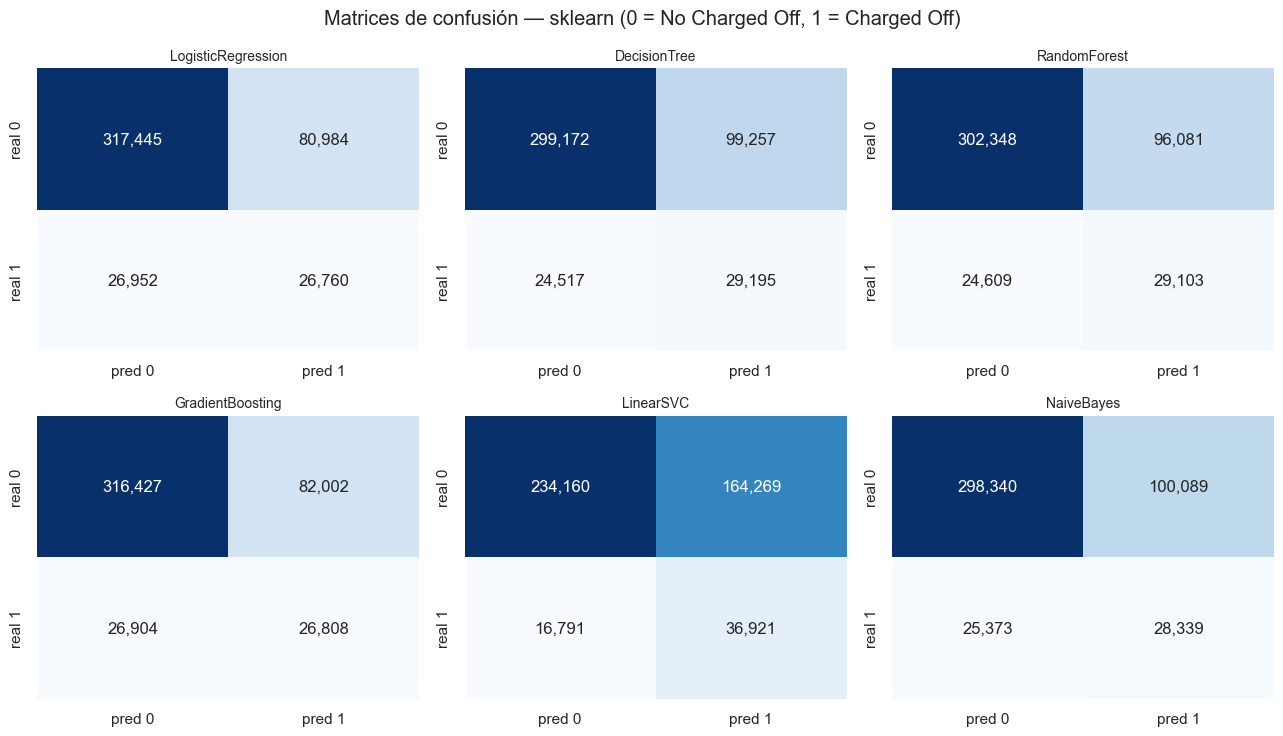

In [44]:
assert list(sklearn_results) == MODELOS, f"Faltan modelos sklearn: {set(MODELOS) - set(sklearn_results)}"
sklearn_metrics_df = pd.DataFrame({k: {kk: vv for kk, vv in v.items() if kk != "matriz_confusion"}
                                   for k, v in sklearn_results.items()}).T
sklearn_metrics_df.index.name = "modelo"
display(sklearn_metrics_df)


def graficar_matrices_confusion(resultados, entorno):
    fig, axes = plt.subplots(2, 3, figsize=(13, 7.5))
    for ax, m in zip(axes.ravel(), MODELOS):
        cm = np.array(resultados[m]["matriz_confusion"])
        sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=ax,
                    xticklabels=["pred 0", "pred 1"], yticklabels=["real 0", "real 1"])
        ax.set_title(m, fontsize=10)
    fig.suptitle(f"Matrices de confusión — {entorno} (0 = No Charged Off, 1 = Charged Off)")
    plt.tight_layout()
    guardar_figura(f"matrices_confusion_{entorno}")
    plt.show()


graficar_matrices_confusion(sklearn_results, "sklearn")

In [45]:
# Puntuaciones continuas de test con su id (insumo de DeLong, McNemar, bootstrap y ROC)
sklearn_scores_df = pd.DataFrame({"id": id_test, "default": y_test,
                                  **{f"score_{k}": v for k, v in sklearn_scores.items()}})
sklearn_scores_df.to_parquet(ARTIFACTS_DIR / "sklearn_scores_test.parquet", index=False)
sklearn_metrics_df.to_pickle(ARTIFACTS_DIR / "sklearn_metrics.pkl")
print(f"Puntuaciones guardadas en {ARTIFACTS_DIR / 'sklearn_scores_test.parquet'} "
      f"({len(sklearn_scores_df):,} filas, columnas: {list(sklearn_scores_df.columns)})")

Puntuaciones guardadas en artifacts_modelado\sklearn_scores_test.parquet (452,141 filas, columnas: ['id', 'default', 'score_LogisticRegression', 'score_DecisionTree', 'score_RandomForest', 'score_GradientBoosting', 'score_LinearSVC', 'score_NaiveBayes'])


**Interpretación (scikit-learn):** Interpretación a completar después de ejecutar el notebook.

## 9.10.4.5. Modelado con PySpark

- `CrossValidator` + `ParamGridBuilder`, `numFolds=3`, `BinaryClassificationEvaluator(metricName="areaUnderROC")`,
  **sin bucles manuales** de combinaciones de hiperparámetros.
- Los seis modelos con los espacios de 9.10.4.3 y los mismos nombres lógicos que en sklearn.
- **Tiempos por separado:** entrenamiento (+ `CrossValidator`), predicción (transformación de test materializada con
  `persist` + `count`) y **transferencia al driver** (`transfer_seconds`), que no se suma al entrenamiento.
- **Transferencia única por modelo, solo después de entrenar y predecir:** se traen al driver únicamente `id`,
  `default` y `score` del conjunto de test, con `vector_to_array`:
  - modelos probabilísticos: `score` = probabilidad de la clase positiva (`probability[1]`);
  - `LinearSVC`: `score` = componente de la clase positiva de `rawPrediction` (margen de decisión).
- **Desbalance:** columna `peso` en el train (misma fórmula "balanced" que scikit-learn) y `weightCol="peso"` en los seis
  estimadores. El evaluador sigue siendo `areaUnderROC`, sin pesos (criterio del enunciado).
- **Umbral (solo train):** se reajusta el mejor modelo del `CrossValidator` (con sus mejores hiperparámetros) en 3
  pliegues definidos por `hash(id)` del train y se predice cada pliegue con el modelo que no lo vio (*out-of-fold*, sin
  `randomSplit`). El umbral maximiza el F1 de la clase Charged Off y se calcula **dentro de Spark**: un histograma
  de 1000 intervalos del puntaje (una sola agregación con `groupBy`); al driver solo llegan escalares, no filas de train.
- Accuracy, precision, recall, F1 y matriz de confusión se calculan localmente a partir del `score` de test con ese
  umbral (`UMBRALES[("spark", modelo)]`), que **no usa test**.


In [20]:
from pyspark.ml.classification import (LogisticRegression as SparkLR, DecisionTreeClassifier as SparkDT,
                                       RandomForestClassifier as SparkRF, GBTClassifier as SparkGBT,
                                       LinearSVC as SparkSVC, NaiveBayes as SparkNB)
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.functions import vector_to_array

evaluator_auc = BinaryClassificationEvaluator(labelCol="default", rawPredictionCol="rawPrediction",
                                              metricName="areaUnderROC")

spark_results = {}         # nombre lógico -> métricas y tiempos
spark_scores_frames = {}   # nombre lógico -> pandas.DataFrame (id, default, score) SOLO de test
spark_fitted_models = {}   # nombre lógico -> bestModel (LIME)
spark_cv = {}              # nombre lógico -> objeto CrossValidator (validación final)
TRANSFER_LOG = []          # registro de cada transferencia Spark -> driver


import hashlib
import joblib
from pyspark.ml.classification import (LogisticRegressionModel, DecisionTreeClassificationModel,
                                       RandomForestClassificationModel, GBTClassificationModel, LinearSVCModel,
                                       NaiveBayesModel)

CLASES_MODELO_SPARK = {"LogisticRegression": LogisticRegressionModel,
                       "DecisionTreeClassifier": DecisionTreeClassificationModel,
                       "RandomForestClassifier": RandomForestClassificationModel,
                       "GBTClassifier": GBTClassificationModel, "LinearSVC": LinearSVCModel,
                       "NaiveBayes": NaiveBayesModel}


class _ModelosSpark(dict):
    """Diccionario de mejores modelos. Si un modelo se restauró de checkpoint sin su archivo (p. ej., Spark no puede
    escribir modelos en Windows sin winutils), se reajusta con sus mejores hiperparámetros SOLO si se pide (LIME)."""

    def __init__(self):
        super().__init__()
        self._pendientes = {}

    def pendiente(self, nombre, est, param_map):
        self._pendientes[nombre] = (est, param_map)

    def __missing__(self, nombre):
        if nombre not in self._pendientes:
            raise KeyError(nombre)
        est, param_map = self._pendientes.pop(nombre)
        print(f"[checkpoint] {nombre}: reajustando con sus mejores hiperparámetros para LIME (no se cronometra).")
        self[nombre] = est.copy(param_map).fit(sdf_train_feat)
        return self[nombre]


def _firma(*partes):
    return hashlib.sha1(repr(partes).encode("utf-8")).hexdigest()[:16]


def _ruta_ckpt(entorno, nombre):
    return CHECKPOINT_DIR / f"{entorno}_{nombre}.joblib"


def _firma_spark(nombre, est, grid):
    params = sorted((p.name, repr(v)) for p, v in est.extractParamMap().items())
    malla = [sorted((p.name, repr(v)) for p, v in pm.items()) for pm in grid]
    return _firma("spark", nombre, type(est).__name__, params, malla, SPARK_CONF_FIRMA,
                  n_train_spark, n_test_spark, CV_FOLDS, RANDOM_STATE)


def _guardar_spark(nombre, firma, idx_mejor, modelo):
    ruta_modelo = (CHECKPOINT_DIR / f"spark_{nombre}_modelo").resolve().as_uri()
    try:
        modelo.write().overwrite().save(ruta_modelo)
        modelo_ok = True
    except Exception as e:   # p. ej., Windows sin winutils: se guardan igual métricas, puntajes y umbral
        modelo_ok = False
        print(f"[checkpoint] {nombre}: no se pudo guardar el modelo de Spark ({type(e).__name__}); si se restaura, "
              "se reajustará solo cuando LIME lo necesite.")
    joblib.dump({"firma": firma, "metrics": spark_results[nombre], "scores": spark_scores_frames[nombre],
                 "umbral": UMBRALES[("spark", nombre)], "idx_mejor": idx_mejor,
                 "modelo_ok": modelo_ok, "ruta_modelo": ruta_modelo,
                 "tiempos": [t for t in TIEMPOS if t["entorno"] == "pyspark" and t["modelo"] == nombre],
                 "transfer": [t for t in TRANSFER_LOG if t["modelo"] == nombre][-1]},
                _ruta_ckpt("spark", nombre))


def _restaurar_spark(nombre, firma, est, grid):
    ruta = _ruta_ckpt("spark", nombre)
    if not (USAR_CHECKPOINTS and ruta.exists()):
        return False
    ck = joblib.load(ruta)
    if ck["firma"] != firma:
        print(f"[checkpoint] {nombre}: no coincide con el modelo, los datos o la configuración de Spark; se reentrena.")
        return False
    spark_results[nombre] = ck["metrics"]
    spark_scores_frames[nombre] = ck["scores"]
    UMBRALES[("spark", nombre)] = ck["umbral"]
    TIEMPOS.extend(ck["tiempos"])
    TRANSFER_LOG.append(ck["transfer"])
    modelo = None
    if ck["modelo_ok"]:
        try:
            modelo = CLASES_MODELO_SPARK[type(est).__name__].load(ck["ruta_modelo"])
        except Exception:
            modelo = None
    if modelo is not None:
        spark_fitted_models[nombre] = modelo
    else:
        spark_fitted_models.pendiente(nombre, est, grid[ck["idx_mejor"]])
    m = ck["metrics"]
    print(f"[{nombre} | {m['implementacion']}] restaurado de checkpoint | AUC={m['roc_auc']:.4f} | "
          f"F1={m['f1']:.4f} | recall={m['recall']:.3f} | umbral={m['umbral']:.4f} | "
          f"fit original={m['tiempo_entrenamiento_s']:,.1f}s")
    return True


spark_fitted_models = _ModelosSpark()   # nombre lógico -> bestModel (LIME)


N_INTERVALOS_UMBRAL = 1000   # intervalos del histograma de puntajes con que se busca el umbral


def umbral_oof_spark(estimator, param_map, score_col):
    """Umbral (score >= umbral) que maximiza el F1 de la clase 1 con puntajes out-of-fold de TRAIN, dentro de Spark.
    Pliegues por hash(id); cada pliegue se predice con un modelo (mejores hiperparámetros) que no lo vio.
    El F1 se evalúa en un histograma de puntajes (una sola agregación groupBy), no con cientos de expresiones."""
    base = sdf_train_feat.withColumn("fold", F.pmod(F.hash(F.col("id")), F.lit(CV_FOLDS)))
    partes = []
    for k in range(CV_FOLDS):
        modelo_k = estimator.copy(param_map).fit(base.filter(F.col("fold") != k))
        partes.append(modelo_k.transform(base.filter(F.col("fold") == k))
                      .select(F.col("default").cast("double").alias("y"),
                              vector_to_array(F.col(score_col))[1].alias("score")))
    oof = partes[0]
    for parte in partes[1:]:
        oof = oof.unionByName(parte)
    oof = oof.persist(StorageLevel.MEMORY_AND_DISK)
    try:
        rango = oof.agg(F.min("score").alias("lo"), F.max("score").alias("hi")).first()
        lo, hi = float(rango["lo"]), float(rango["hi"])
        ancho = max((hi - lo) / N_INTERVALOS_UMBRAL, 1e-12)
        intervalo = F.least(F.floor((F.col("score") - F.lit(lo)) / F.lit(ancho)).cast("int"),
                            F.lit(N_INTERVALOS_UMBRAL - 1))
        hist = oof.withColumn("b", intervalo).groupBy("b").agg(F.sum("y").alias("tp"), F.count(F.lit(1)).alias("pp"))
        filas = hist.agg(F.collect_list(F.struct("b", "tp", "pp")).alias("h")).first()["h"]   # una fila de escalares
    finally:
        oof.unpersist()
    tp, pp = np.zeros(N_INTERVALOS_UMBRAL), np.zeros(N_INTERVALOS_UMBRAL)
    for r in filas:
        tp[r["b"]], pp[r["b"]] = r["tp"], r["pp"]
    tp, pp = tp[::-1].cumsum()[::-1], pp[::-1].cumsum()[::-1]
    f1 = 2.0 * tp / np.maximum(pp + tp[0], 1e-12)
    return float(lo + int(np.argmax(f1)) * ancho)


def evaluar_spark(nombre, estimator, param_grid, score_col):
    """Evalúa modelo de Spark con malla de parámetros (lista de ParamMap, ya construida).
    param_grid es el resultado de ParamGridBuilder().addGrid(...).build(), NO una lambda."""
    est = estimator.setLabelCol("default").setFeaturesCol("features").setWeightCol("peso")
    if est.hasParam("maxBins"):
        est = est.setMaxBins(MAX_BINS)
    
    firma = _firma_spark(nombre, est, param_grid)
    if _restaurar_spark(nombre, firma, est, param_grid):
        return spark_results[nombre]

    cv = CrossValidator(estimator=est, estimatorParamMaps=param_grid, evaluator=evaluator_auc,
                        numFolds=CV_FOLDS, parallelism=2, seed=RANDOM_STATE)

    # 1) Entrenamiento + CrossValidator (sobre el train persistido, con pesos de clase)
    t0 = time.perf_counter()
    cv_model = cv.fit(sdf_train_feat)
    t_fit = time.perf_counter() - t0
    idx_mejor = int(np.argmax(cv_model.avgMetrics))
    mejores = {p.name: v for p, v in cv_model.getEstimatorParamMaps()[idx_mejor].items()}

    # 2) Umbral out-of-fold SOLO con train (agregaciones en Spark; sin transferir filas)
    t0 = time.perf_counter()
    UMBRALES[("spark", nombre)] = umbral_oof_spark(est, cv_model.getEstimatorParamMaps()[idx_mejor], score_col)
    t_umbral = time.perf_counter() - t0

    # 3) Predicción sobre test (materializada en Spark, sin traer nada al driver)
    t0 = time.perf_counter()
    pred = (cv_model.transform(sdf_test_feat)
            .withColumn("score", vector_to_array(F.col(score_col))[1])
            .select("id", "default", "score")
            .persist(StorageLevel.MEMORY_AND_DISK))
    n_pred = pred.count()
    t_pred = time.perf_counter() - t0

    # 4) ÚNICA transferencia de filas al driver: id, default, score del test (después de entrenar y predecir)
    t0 = time.perf_counter()
    scores_pd = pred.toPandas()
    t_transfer = time.perf_counter() - t0
    pred.unpersist()
    assert len(scores_pd) == n_pred == n_test_spark, "Solo se transfiere el conjunto de test."
    assert list(scores_pd.columns) == ["id", "default", "score"]
    TRANSFER_LOG.append({"modelo": nombre, "filas": len(scores_pd), "columnas": list(scores_pd.columns),
                         "transfer_seconds": t_transfer})

    scores_pd["id"] = scores_pd["id"].astype(str)
    y_true = scores_pd["default"].to_numpy().astype(int)
    score_arr = scores_pd["score"].to_numpy().astype(float)

    metrics = {"implementacion": type(estimator).__name__, "mejores_hiperparametros": mejores,
               "pesos": "weightCol=peso (balanced)", "cv_auc_medio": float(cv_model.avgMetrics[idx_mejor]),
               **metricas_clasificacion(y_true, score_arr, nombre, "spark"),
               "tiempo_entrenamiento_s": t_fit, "tiempo_umbral_s": t_umbral, "tiempo_prediccion_s": t_pred,
               "tiempo_transferencia_s": t_transfer}
    spark_results[nombre] = metrics
    spark_scores_frames[nombre] = scores_pd
    spark_fitted_models[nombre] = cv_model.bestModel
    spark_cv[nombre] = cv
    registrar_tiempo("pyspark", "entrenamiento_crossvalidator", t_fit, nombre)
    registrar_tiempo("pyspark", "umbral_oof", t_umbral, nombre)
    registrar_tiempo("pyspark", "prediccion", t_pred, nombre)
    registrar_tiempo("pyspark", "transferencia_driver", t_transfer, nombre)
    print(f"[{nombre} | {metrics['implementacion']}] AUC={metrics['roc_auc']:.4f} | PR-AUC={metrics['pr_auc']:.4f} | "
          f"F1={metrics['f1']:.4f} | recall={metrics['recall']:.3f} | umbral={metrics['umbral']:.4f} | "
          f"fit={t_fit:,.1f}s | umbral={t_umbral:,.1f}s | pred={t_pred:,.2f}s | transfer={t_transfer:,.2f}s | "
          f"mejores parámetros: {mejores}")
    _guardar_spark(nombre, firma, idx_mejor, cv_model.bestModel)
    return metrics


In [46]:
lr_est = SparkLR(family="binomial", elasticNetParam=0.0, maxIter=100)   # L2 pura
evaluar_spark(
    "LogisticRegression",
    lr_est,
    # addGrid() usa Param de la MISMA instancia pasada como estimador: CrossValidator compara los ParamMap por
    # identidad (parent uid + nombre), así que un Param tomado de una instancia distinta (p. ej. SparkLR() nueva)
    # se ignora en silencio y el modelo se ajusta con los valores por defecto en cada punto de la malla.
    ParamGridBuilder().addGrid(lr_est.regParam, REG_PARAMS).build(),
    score_col="probability",
)


[LogisticRegression | LogisticRegression] restaurado de checkpoint | AUC=0.7286 | F1=0.3352 | recall=0.522 | umbral=0.5636 | fit original=168.9s


{'implementacion': 'LogisticRegression',
 'mejores_hiperparametros': {'regParam': 1e-06},
 'pesos': 'weightCol=peso (balanced)',
 'cv_auc_medio': 0.7286429449784978,
 'umbral': 0.5636190103381193,
 'accuracy': 0.7538090993738679,
 'precision': 0.24675758614928733,
 'recall': 0.5224717009234435,
 'f1': 0.3352026708234044,
 'roc_auc': 0.7285956243045888,
 'pr_auc': 0.25373447383042197,
 'matriz_confusion': [[312765, 85664], [25649, 28063]],
 'tiempo_entrenamiento_s': 168.88420659999997,
 'tiempo_umbral_s': 64.45199490000005,
 'tiempo_prediccion_s': 0.840409300000033,
 'tiempo_transferencia_s': 2.0395723999999973}

In [21]:
dt_est = SparkDT()
evaluar_spark(
    "DecisionTree",
    dt_est,
    ParamGridBuilder().addGrid(dt_est.maxDepth, [5, 10, 15]).build(),
    score_col="probability",
)


[checkpoint] DecisionTree: no coincide con el modelo, los datos o la configuración de Spark; se reentrena.
[DecisionTree | DecisionTreeClassifier] AUC=0.6949 | PR-AUC=0.1999 | F1=0.3174 | recall=0.555 | umbral=0.5741 | fit=106.6s | umbral=15.5s | pred=0.71s | transfer=1.23s | mejores parámetros: {'maxDepth': 5}
[checkpoint] DecisionTree: no se pudo guardar el modelo de Spark (Py4JJavaError); si se restaura, se reajustará solo cuando LIME lo necesite.


{'implementacion': 'DecisionTreeClassifier',
 'mejores_hiperparametros': {'maxDepth': 5},
 'pesos': 'weightCol=peso (balanced)',
 'cv_auc_medio': 0.6476373389904456,
 'umbral': 0.5740688189199858,
 'accuracy': 0.7163252171335933,
 'precision': 0.22219489472703557,
 'recall': 0.5550528745904081,
 'f1': 0.31735032226817184,
 'roc_auc': 0.6948609068618339,
 'pr_auc': 0.19992416245479322,
 'matriz_confusion': [[294067, 104362], [23899, 29813]],
 'tiempo_entrenamiento_s': 106.61191500000007,
 'tiempo_umbral_s': 15.462457699999959,
 'tiempo_prediccion_s': 0.7114466000000448,
 'tiempo_transferencia_s': 1.2285005999999612}

In [22]:
rf_est = SparkRF(seed=RANDOM_STATE)
evaluar_spark(
    "RandomForest",
    rf_est,
    ParamGridBuilder().addGrid(rf_est.numTrees, [10, 50]).addGrid(rf_est.maxDepth, [5, 10]).build(),
    score_col="probability",
)


[RandomForest | RandomForestClassifier] restaurado de checkpoint | AUC=0.7203 | F1=0.3233 | recall=0.559 | umbral=0.5637 | fit original=375.8s


{'implementacion': 'RandomForestClassifier',
 'mejores_hiperparametros': {'numTrees': 50, 'maxDepth': 10},
 'pesos': 'weightCol=peso (balanced)',
 'cv_auc_medio': 0.7202829693803281,
 'umbral': 0.5636952876333525,
 'accuracy': 0.7219340869330585,
 'precision': 0.22738251171665014,
 'recall': 0.5591301757521596,
 'f1': 0.323291475813961,
 'roc_auc': 0.7202975459781532,
 'pr_auc': 0.2458507143550103,
 'matriz_confusion': [[296384, 102045], [23680, 30032]],
 'tiempo_entrenamiento_s': 375.8205203,
 'tiempo_umbral_s': 203.3632523,
 'tiempo_prediccion_s': 2.834526399999959,
 'tiempo_transferencia_s': 0.9849375999999666}

In [47]:
# GradientBoosting de PySpark: NO se ejecuta en esta corrida (ver reflexión crítica 9.10.5).
# El intento con la malla completa del enunciado corrió 158 min y terminó con
# ConnectionResetError [WinError 10054] (caída de la JVM por agotamiento de memoria, ~7 GB de RAM).
# Para volver a intentarlo, poner SALTAR_GBT_SPARK = False.
SALTAR_GBT_SPARK = True

gbt_est = SparkGBT(stepSize=0.1, seed=RANDOM_STATE)
if SALTAR_GBT_SPARK:
    print("[AVISO] GradientBoosting de PySpark omitido: la JVM cayó tras 158 min en el equipo disponible.")
else:
    evaluar_spark(
        "GradientBoosting",            # nombre lógico común; implementación GBTClassifier
        gbt_est,
        ParamGridBuilder().addGrid(gbt_est.maxIter, [50, 100]).addGrid(gbt_est.maxDepth, [3, 5]).build(),
        score_col="probability",
    )


[AVISO] GradientBoosting de PySpark omitido: la JVM cayó tras 158 min en el equipo disponible.


In [48]:
svc_est = SparkSVC()
evaluar_spark(
    "LinearSVC",
    svc_est,
    ParamGridBuilder().addGrid(svc_est.regParam, REG_PARAMS).build(),
    score_col="rawPrediction",     # LinearSVC no produce 'probability': se usa el margen de la clase positiva
)


[LinearSVC | LinearSVC] restaurado de checkpoint | AUC=0.7123 | F1=0.2924 | recall=0.630 | umbral=0.9996 | fit original=659.2s


{'implementacion': 'LinearSVC',
 'mejores_hiperparametros': {'regParam': 1e-06},
 'pesos': 'weightCol=peso (balanced)',
 'cv_auc_medio': 0.7106191122774349,
 'umbral': 0.9995600779581311,
 'accuracy': 0.6380553853775702,
 'precision': 0.19042362667687907,
 'recall': 0.6295055108728032,
 'f1': 0.2923977619620018,
 'roc_auc': 0.7123332222003662,
 'pr_auc': 0.24591352695216862,
 'matriz_confusion': [[254679, 143750], [19900, 33812]],
 'tiempo_entrenamiento_s': 659.1830834,
 'tiempo_umbral_s': 191.49460049999993,
 'tiempo_prediccion_s': 0.8532371000001149,
 'tiempo_transferencia_s': 1.7841922999998587}

In [49]:
evaluar_spark(
    "NaiveBayes",
    SparkNB(modelType="gaussian"),
    ParamGridBuilder().build(),   # sin búsqueda, como en sklearn
    score_col="probability",
)

[NaiveBayes | NaiveBayes] restaurado de checkpoint | AUC=0.7024 | F1=0.3114 | recall=0.534 | umbral=0.0250 | fit original=21.3s


{'implementacion': 'NaiveBayes',
 'mejores_hiperparametros': {},
 'pesos': 'weightCol=peso (balanced)',
 'cv_auc_medio': 0.5719013773879812,
 'umbral': 0.025,
 'accuracy': 0.7191318637327736,
 'precision': 0.21965477137785394,
 'recall': 0.5344801906464105,
 'f1': 0.3113530866339855,
 'roc_auc': 0.7024018307176981,
 'pr_auc': 0.23125392091900823,
 'matriz_confusion': [[296441, 101988], [25004, 28708]],
 'tiempo_entrenamiento_s': 21.312616899999966,
 'tiempo_umbral_s': 8.828116499999851,
 'tiempo_prediccion_s': 0.7288352000000486,
 'tiempo_transferencia_s': 0.8819589000001997}

[AVISO] PySpark sin completar: ['GradientBoosting']. Análisis con 6 modelos de sklearn + 5 de PySpark = 11 en total.


,implementacion,mejores_hiperparametros,pesos,cv_auc_medio,umbral,accuracy,precision,recall,f1,roc_auc,pr_auc,tiempo_entrenamiento_s,tiempo_umbral_s,tiempo_prediccion_s,tiempo_transferencia_s
modelo,,,,,,,,,,,,,,,
DecisionTree,DecisionTreeClassifier,{'maxDepth': 5},weightCol=peso (balanced),0.647637,0.574069,0.716325,0.222195,0.555053,0.31735,0.694861,0.199924,106.611915,15.462458,0.711447,1.228501
RandomForest,RandomForestClassifier,"{'numTrees': 50, 'maxDepth': 10}",weightCol=peso (balanced),0.720283,0.563695,0.721934,0.227383,0.55913,0.323291,0.720298,0.245851,375.82052,203.363252,2.834526,0.984938
LogisticRegression,LogisticRegression,{'regParam': 1e-06},weightCol=peso (balanced),0.728643,0.563619,0.753809,0.246758,0.522472,0.335203,0.728596,0.253734,168.884207,64.451995,0.840409,2.039572
LinearSVC,LinearSVC,{'regParam': 1e-06},weightCol=peso (balanced),0.710619,0.99956,0.638055,0.190424,0.629506,0.292398,0.712333,0.245914,659.183083,191.4946,0.853237,1.784192
NaiveBayes,NaiveBayes,{},weightCol=peso (balanced),0.571901,0.025,0.719132,0.219655,0.53448,0.311353,0.702402,0.231254,21.312617,8.828116,0.728835,0.881959


,modelo,filas,columnas,transfer_seconds
0,DecisionTree,452141,"[id, default, score]",1.228501
1,RandomForest,452141,"[id, default, score]",0.984938
2,LogisticRegression,452141,"[id, default, score]",2.039572
3,LinearSVC,452141,"[id, default, score]",1.784192
4,NaiveBayes,452141,"[id, default, score]",0.881959


KeyError: 'GradientBoosting'

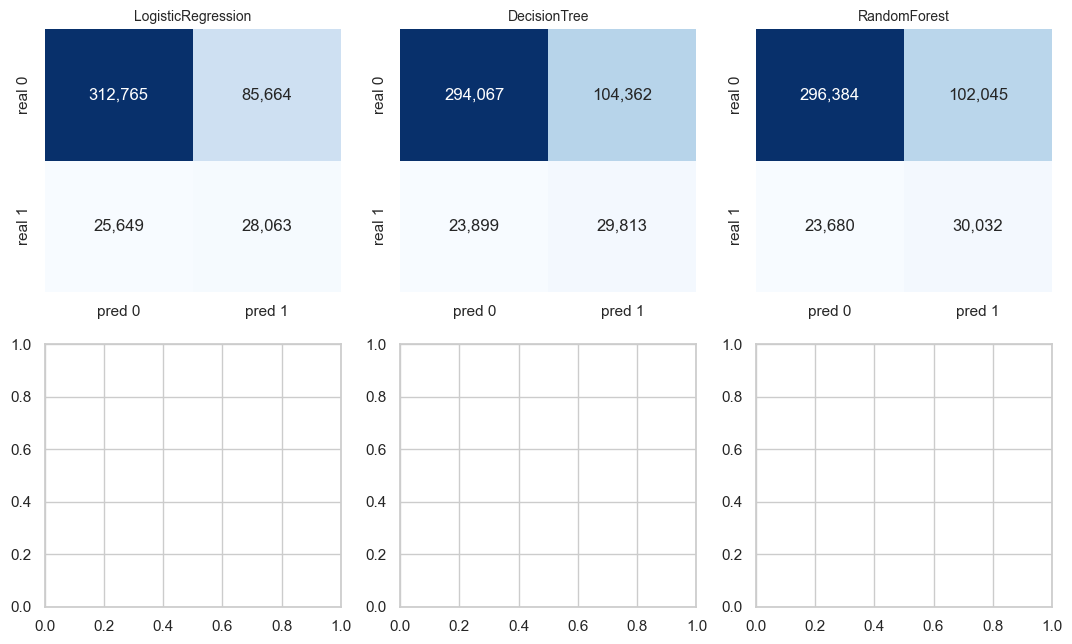

In [50]:
# Modelos de PySpark efectivamente entrenados. Si alguno no pudo completarse en el equipo
# disponible, se documenta la ausencia y el análisis continúa con los restantes.
MODELOS_SPARK = [m for m in MODELOS if m in spark_results]
MODELOS_AMBOS = [m for m in MODELOS if m in sklearn_results and m in spark_results]
MODELOS_FALTANTES_SPARK = [m for m in MODELOS if m not in spark_results]

assert len(MODELOS_SPARK) >= 5, f"Demasiados modelos de PySpark ausentes: {MODELOS_FALTANTES_SPARK}"
if MODELOS_FALTANTES_SPARK:
    print(f"[AVISO] PySpark sin completar: {MODELOS_FALTANTES_SPARK}. "
          f"Análisis con {len(MODELOS)} modelos de sklearn + {len(MODELOS_SPARK)} de PySpark "
          f"= {len(MODELOS) + len(MODELOS_SPARK)} en total.")

spark_metrics_df = pd.DataFrame({k: {kk: vv for kk, vv in v.items() if kk != "matriz_confusion"}
                                 for k, v in spark_results.items()}).T
spark_metrics_df.index.name = "modelo"
display(spark_metrics_df)
display(pd.DataFrame(TRANSFER_LOG))
graficar_matrices_confusion(spark_results, "pyspark")


In [51]:
# Tabla de puntuaciones de Spark: id, default, score_<modelo> (una columna por modelo)
spark_scores_df = None
for nombre in MODELOS_SPARK:
    piece = spark_scores_frames[nombre].rename(columns={"score": f"score_{nombre}"})
    if spark_scores_df is None:
        spark_scores_df = piece
    else:
        spark_scores_df = spark_scores_df.merge(piece, on=["id", "default"], how="inner", validate="one_to_one")
assert len(spark_scores_df) == n_test_spark, "El 'default' de Spark debe coincidir entre modelos para cada id."

spark_scores_df.to_parquet(ARTIFACTS_DIR / "spark_scores_test.parquet", index=False)
spark_metrics_df.to_pickle(ARTIFACTS_DIR / "spark_metrics.pkl")
print(f"Puntuaciones guardadas en {ARTIFACTS_DIR / 'spark_scores_test.parquet'} "
      f"({len(spark_scores_df):,} filas, columnas: {list(spark_scores_df.columns)})")

Puntuaciones guardadas en artifacts_modelado\spark_scores_test.parquet (452,141 filas, columnas: ['id', 'default', 'score_LogisticRegression', 'score_DecisionTree', 'score_RandomForest', 'score_LinearSVC', 'score_NaiveBayes'])


**Interpretación (PySpark):** Interpretación a completar después de ejecutar el notebook.

## 9.10.4.6. Comparación estadística de los modelos

### 9.10.4.6.1. Prueba de DeLong

**Implementación rápida** O(n log n) basada en Sun & Xu (2014): usa rangos medios (*midranks*) en lugar de la matriz
de comparaciones O(n²) de la versión directa de DeLong, DeLong y Clarke-Pearson (1988), que es inviable con cientos de
miles de observaciones de test.

**Validación obligatoria antes de usarla:** se implementa también **DeLong directo O(n²)** y se comparan AUC,
varianzas, covarianza, ΔAUC, varianza de ΔAUC, z y p entre ambas versiones en conjuntos pequeños (300–500
observaciones, ambas clases presentes): uno sintético con empates y dos submuestras reales del test. La versión
O(n²) **nunca** se ejecuta sobre el test completo.

In [52]:
def _compute_midrank(x):
    """Rangos medios (empates promediados), base 1. O(n log n)."""
    return sps.rankdata(x, method="average")


def _fast_delong(preds_sorted_T, n_pos):
    """Sun & Xu (2014). preds_sorted_T: (k modelos) x (n obs.) con las n_pos positivas primero. -> (aucs, cov)."""
    k = preds_sorted_T.shape[0]
    n_neg = preds_sorted_T.shape[1] - n_pos
    pos, neg = preds_sorted_T[:, :n_pos], preds_sorted_T[:, n_pos:]
    tx = np.vstack([_compute_midrank(pos[r]) for r in range(k)])
    ty = np.vstack([_compute_midrank(neg[r]) for r in range(k)])
    tz = np.vstack([_compute_midrank(preds_sorted_T[r]) for r in range(k)])
    aucs = tz[:, :n_pos].sum(axis=1) / (n_pos * n_neg) - (n_pos + 1.0) / (2.0 * n_neg)
    v10 = (tz[:, :n_pos] - tx) / n_neg          # componente estructural de cada positivo
    v01 = 1.0 - (tz[:, n_pos:] - ty) / n_pos    # componente estructural de cada negativo
    s10 = np.atleast_2d(np.cov(v10))
    s01 = np.atleast_2d(np.cov(v01))
    return aucs, s10 / n_pos + s01 / n_neg


def _delong_directo(y_true, scores_2xn):
    """DeLong directo O(n_pos * n_neg). SOLO para validar en conjuntos pequeños."""
    y = np.asarray(y_true).astype(int)
    S = np.asarray(scores_2xn, dtype=float)
    pos, neg = S[:, y == 1], S[:, y == 0]
    n_pos, n_neg = pos.shape[1], neg.shape[1]
    psi = (pos[:, :, None] > neg[:, None, :]).astype(float) + 0.5 * (pos[:, :, None] == neg[:, None, :])
    aucs = psi.mean(axis=(1, 2))
    v10 = psi.mean(axis=2)    # (k, n_pos)
    v01 = psi.mean(axis=1)    # (k, n_neg)
    return aucs, np.atleast_2d(np.cov(v10)) / n_pos + np.atleast_2d(np.cov(v01)) / n_neg


def _resultado_delong(aucs, cov):
    var_a, var_b, cov_ab = cov[0, 0], cov[1, 1], cov[0, 1]
    diff = aucs[0] - aucs[1]
    var_diff = max(var_a + var_b - 2 * cov_ab, 0.0)
    se_diff = np.sqrt(var_diff)
    z = diff / se_diff if se_diff > 0 else 0.0
    p = 2 * sps.norm.sf(abs(z)) if se_diff > 0 else 1.0
    zc = sps.norm.ppf(1 - ALPHA / 2)
    return dict(auc_a=aucs[0], auc_b=aucs[1], var_a=var_a, var_b=var_b, cov_ab=cov_ab,
                ci_a=(max(0.0, aucs[0] - zc * np.sqrt(var_a)), min(1.0, aucs[0] + zc * np.sqrt(var_a))),
                ci_b=(max(0.0, aucs[1] - zc * np.sqrt(var_b)), min(1.0, aucs[1] + zc * np.sqrt(var_b))),
                delta_auc=diff, var_delta=var_diff, ci_delta=(diff - zc * se_diff, diff + zc * se_diff),
                z=z, p_value=p)


def delong_test(y_true, score_a, score_b):
    """Fast DeLong: AUC + IC 95 % de cada score, ΔAUC + IC 95 %, z y p bilateral (H0: AUC_a = AUC_b)."""
    y_true = np.asarray(y_true).astype(int)
    order = np.argsort(-y_true, kind="stable")   # positivos primero
    n_pos = int(y_true.sum())
    preds = np.vstack([np.asarray(score_a, dtype=float), np.asarray(score_b, dtype=float)])[:, order]
    return _resultado_delong(*_fast_delong(preds, n_pos))


def delong_directo_test(y_true, score_a, score_b):
    return _resultado_delong(*_delong_directo(y_true, np.vstack([score_a, score_b])))

#### Alineación de las puntuaciones de sklearn y PySpark (corrección del error de DeLong)

En la versión anterior, tras el *merge* ambos entornos terminaban leyendo la misma columna `score_<modelo>`, de modo
que "sklearn vs Spark" podía ser en realidad sklearn contra sklearn. Ahora, **antes del merge**, las columnas se
renombran con un prefijo por entorno (`sklearn_<modelo>` y `spark_<modelo>`), y `score_cols[("sklearn", m)]` y
`score_cols[("spark", m)]` apuntan a columnas distintas. Se verifica además que `y_true` y los IDs de test sean
exactamente los mismos en los dos entornos.

In [53]:
skl = (sklearn_scores_df.rename(columns={f"score_{m}": f"sklearn_{m}" for m in MODELOS})
       .rename(columns={"default": "default_sklearn"}))
spk = (spark_scores_df.rename(columns={f"score_{m}": f"spark_{m}" for m in MODELOS_SPARK})
       .rename(columns={"default": "default_spark"}))
skl["id"] = skl["id"].astype(str)
spk["id"] = spk["id"].astype(str)

# IDs de test idénticos en ambos entornos (y equivalentes a la partición común)
assert set(skl["id"]) == set(spk["id"]) == set(ids_test), "Los IDs de test deben ser exactamente los mismos."
assert len(skl) == len(spk) == len(ids_test)

scores_all = skl.merge(spk, on="id", how="inner", validate="one_to_one")
assert len(scores_all) == len(ids_test)

# y_true exactamente igual
assert np.array_equal(scores_all["default_sklearn"].to_numpy(), scores_all["default_spark"].to_numpy()), \
    "El target de test debe ser idéntico en sklearn y Spark."
scores_all["default"] = scores_all["default_sklearn"]
y_common = scores_all["default"].to_numpy().astype(int)
id_common = scores_all["id"].to_numpy()

score_cols = {}
for m in MODELOS:
    col_skl = f"sklearn_{m}"
    assert col_skl in scores_all
    score_cols[("sklearn", m)] = scores_all[col_skl].to_numpy(dtype=float)
for m in MODELOS_SPARK:
    col_spk = f"spark_{m}"
    assert col_spk in scores_all
    score_cols[("spark", m)] = scores_all[col_spk].to_numpy(dtype=float)

# Comprobación explícita: cada entorno aporta su propia columna.
chequeo_columnas = []
for m in MODELOS_AMBOS:
    a, b = score_cols[("sklearn", m)], score_cols[("spark", m)]
    identicos = np.array_equal(a, b)
    if not identicos:
        assert not np.array_equal(scores_all[f"sklearn_{m}"].to_numpy(), scores_all[f"spark_{m}"].to_numpy())
    else:
        # Solo si fueran legítimamente idénticos: se muestran estadísticas en lugar de fallar.
        print(f"[aviso] {m}: los scores de sklearn y Spark son numéricamente idénticos; provienen de las columnas "
              f"distintas 'sklearn_{m}' y 'spark_{m}'.")
        display(pd.DataFrame({f"sklearn_{m}": a, f"spark_{m}": b}).describe().T)
    chequeo_columnas.append({"modelo": m, "columna_sklearn": f"sklearn_{m}", "columna_spark": f"spark_{m}",
                             "identicos": identicos, "max_dif_abs": float(np.max(np.abs(a - b))),
                             "corr_pearson": float(np.corrcoef(a, b)[0, 1]) if a.std() > 0 and b.std() > 0 else np.nan})
display(pd.DataFrame(chequeo_columnas))
scores_all.to_parquet(ARTIFACTS_DIR / "scores_test_ambos_entornos.parquet", index=False)
print(f"Observaciones de test comunes: {len(scores_all):,} | positivos: {int(y_common.sum()):,}")

,modelo,columna_sklearn,columna_spark,identicos,max_dif_abs,corr_pearson
0,LogisticRegression,sklearn_LogisticRegression,spark_LogisticRegression,False,0.449869,0.991922
1,DecisionTree,sklearn_DecisionTree,spark_DecisionTree,False,0.546474,0.892272
2,RandomForest,sklearn_RandomForest,spark_RandomForest,False,0.130400,0.992057
3,LinearSVC,sklearn_LinearSVC,spark_LinearSVC,False,1.187164,0.999975
4,NaiveBayes,sklearn_NaiveBayes,spark_NaiveBayes,False,0.001674,1.000000


Observaciones de test comunes: 452,141 | positivos: 53,712


#### Validación de Fast DeLong frente a DeLong directo O(n²)

Se exige que las diferencias absolutas entre ambas implementaciones sean del orden del error de redondeo
(tolerancia 1e-10). Se usan: (1) un conjunto sintético de 400 observaciones con empates deliberados, y (2) dos
submuestras estratificadas de 400 observaciones del test real (una con modelos de árbol, que generan muchos empates).
Estas muestras se usan **exclusivamente** para validar el algoritmo.

In [54]:
N_VALIDACION_DELONG = 400
TOL_DELONG = 1e-10


def comparar_delong(y, s1, s2, etiqueta):
    rf = delong_test(y, s1, s2)
    rd = delong_directo_test(y, s1, s2)
    filas = []
    for clave, nombre in [("auc_a", "AUC modelo 1"), ("auc_b", "AUC modelo 2"), ("var_a", "Var(AUC 1)"),
                          ("var_b", "Var(AUC 2)"), ("cov_ab", "Cov(AUC 1, AUC 2)"), ("delta_auc", "ΔAUC"),
                          ("var_delta", "Var(ΔAUC)"), ("z", "z"), ("p_value", "p bilateral")]:
        filas.append({"conjunto": etiqueta, "cantidad": nombre, "fast_delong": rf[clave], "delong_directo": rd[clave],
                      "dif_abs": abs(rf[clave] - rd[clave])})
    auc_skl = (roc_auc_score(y, s1), roc_auc_score(y, s2))
    filas.append({"conjunto": etiqueta, "cantidad": "|AUC fast - roc_auc_score| (máx.)",
                  "fast_delong": max(abs(rf["auc_a"] - auc_skl[0]), abs(rf["auc_b"] - auc_skl[1])),
                  "delong_directo": np.nan, "dif_abs": max(abs(rf["auc_a"] - auc_skl[0]), abs(rf["auc_b"] - auc_skl[1]))})
    return pd.DataFrame(filas)


def submuestra_estratificada(y, n, seed):
    idx, _ = train_test_split(np.arange(len(y)), train_size=n, stratify=y, random_state=seed)
    return np.sort(idx)


# (1) Sintético con empates (scores redondeados)
rng_val = np.random.default_rng(0)
y_syn = rng_val.integers(0, 2, N_VALIDACION_DELONG)
s1_syn = np.round(y_syn + rng_val.normal(0, 1.5, N_VALIDACION_DELONG), 1)
s2_syn = np.round(0.6 * s1_syn + rng_val.normal(0, 1.2, N_VALIDACION_DELONG), 1)

# (2) Submuestras reales del test
idx_v1 = submuestra_estratificada(y_common, N_VALIDACION_DELONG, RANDOM_STATE)
idx_v2 = submuestra_estratificada(y_common, N_VALIDACION_DELONG, RANDOM_STATE + 1)
assert 0 < y_common[idx_v1].sum() < N_VALIDACION_DELONG and 0 < y_common[idx_v2].sum() < N_VALIDACION_DELONG

validacion_delong = pd.concat([
    comparar_delong(y_syn, s1_syn, s2_syn, "sintético con empates"),
    comparar_delong(y_common[idx_v1], score_cols[("sklearn", "LogisticRegression")][idx_v1],
                    score_cols[("spark", "LogisticRegression")][idx_v1], "real: LR sklearn vs LR Spark"),
    comparar_delong(y_common[idx_v2], score_cols[("sklearn", "DecisionTree")][idx_v2],
                    score_cols[("spark", "RandomForest")][idx_v2], "real: DT sklearn vs RF Spark (empates)"),
], ignore_index=True)
display(validacion_delong)
validacion_delong.to_csv(ARTIFACTS_DIR / "validacion_fast_vs_directo_delong.csv", index=False)

DELONG_VALIDACION_OK = bool((validacion_delong["dif_abs"] < TOL_DELONG).all())
assert DELONG_VALIDACION_OK, "Fast DeLong no coincide con DeLong directo: revisar la implementación."
print(f"Validación superada: diferencia máxima = {validacion_delong['dif_abs'].max():.2e} (< {TOL_DELONG}). "
      "A partir de aquí se usa solo Fast DeLong sobre el test completo.")

,conjunto,cantidad,fast_delong,delong_directo,dif_abs
0,sintético con empates,AUC modelo 1,7.120251e-01,7.120251e-01,1.110223e-16
1,sintético con empates,AUC modelo 2,5.903966e-01,5.903966e-01,0.000000e+00
2,sintético con empates,Var(AUC 1),6.650974e-04,6.650974e-04,1.084202e-19
3,sintético con empates,Var(AUC 2),8.070596e-04,8.070596e-04,1.084202e-19
4,sintético con empates,"Cov(AUC 1, AUC 2)",4.824519e-04,4.824519e-04,0.000000e+00
5,sintético con empates,ΔAUC,1.216285e-01,1.216285e-01,1.110223e-16
6,sintético con empates,Var(ΔAUC),5.072531e-04,5.072531e-04,0.000000e+00
7,sintético con empates,z,5.400361e+00,5.400361e+00,5.329071e-15
8,sintético con empates,p bilateral,6.650683e-08,6.650683e-08,1.826415e-21
9,sintético con empates,|AUC fast - roc_auc_score| (máx.),2.220446e-16,NaN,2.220446e-16


Validación superada: diferencia máxima = 2.44e-14 (< 1e-10). A partir de aquí se usa solo Fast DeLong sobre el test completo.


#### Todas las comparaciones DeLong

Tres familias, con **corrección de Holm (α = 0.05) dentro de cada familia**:

- **A. Entre entornos:** mismo modelo, sklearn vs PySpark → 6 comparaciones.
- **B. Dentro de scikit-learn:** todos los pares → C(6,2) = 15 comparaciones.
- **C. Dentro de PySpark:** todos los pares → 15 comparaciones.

Para cada comparación: AUC e IC 95 % de cada modelo, ΔAUC (modelo 1 − modelo 2) e IC 95 %, z, p bilateral,
`p_ajustado_holm`, `significativo_holm` y `relevante_practica = |ΔAUC| ≥ PRACTICAL_AUC_MARGIN` (0.005).

In [55]:
def tabla_delong(pares, familia):
    filas = []
    for (env_1, m_1), (env_2, m_2) in pares:
        r = delong_test(y_common, score_cols[(env_1, m_1)], score_cols[(env_2, m_2)])
        filas.append({
            "familia": familia, "modelo_1": f"{env_1}:{m_1}", "modelo_2": f"{env_2}:{m_2}",
            "entorno_1": env_1, "algoritmo_1": m_1, "entorno_2": env_2, "algoritmo_2": m_2,
            "auc_1": r["auc_a"], "ic95_auc_1_inf": r["ci_a"][0], "ic95_auc_1_sup": r["ci_a"][1],
            "auc_2": r["auc_b"], "ic95_auc_2_inf": r["ci_b"][0], "ic95_auc_2_sup": r["ci_b"][1],
            "delta_auc": r["delta_auc"], "ic95_delta_inf": r["ci_delta"][0], "ic95_delta_sup": r["ci_delta"][1],
            "z": r["z"], "p_bilateral": r["p_value"],
        })
    tabla = pd.DataFrame(filas)
    rechaza, p_adj, _, _ = multipletests(tabla["p_bilateral"], alpha=ALPHA, method="holm")
    tabla["p_ajustado_holm"] = p_adj
    tabla["significativo_holm"] = rechaza
    tabla["relevante_practica"] = tabla["delta_auc"].abs() >= PRACTICAL_AUC_MARGIN
    return tabla


pares_entre_entornos = [(("sklearn", m), ("spark", m)) for m in MODELOS_AMBOS]
pares_sklearn = [(("sklearn", a), ("sklearn", b)) for a, b in itertools.combinations(MODELOS, 2)]
pares_spark = [(("spark", a), ("spark", b)) for a, b in itertools.combinations(MODELOS_SPARK, 2)]

delong_entre_entornos = tabla_delong(pares_entre_entornos, "A_entre_entornos")
delong_sklearn = tabla_delong(pares_sklearn, "B_dentro_sklearn")
delong_spark = tabla_delong(pares_spark, "C_dentro_spark")
N_PARES_EE = len(MODELOS_AMBOS)
N_PARES_SKL = len(MODELOS) * (len(MODELOS) - 1) // 2
N_PARES_SPK = len(MODELOS_SPARK) * (len(MODELOS_SPARK) - 1) // 2
assert (len(delong_entre_entornos), len(delong_sklearn), len(delong_spark)) == (N_PARES_EE, N_PARES_SKL, N_PARES_SPK)

delong_todas = pd.concat([delong_entre_entornos, delong_sklearn, delong_spark], ignore_index=True)
delong_todas.to_csv(ARTIFACTS_DIR / "delong_todas_las_comparaciones.csv", index=False)

print(f"A. Entre entornos ({N_PARES_EE}):")
display(delong_entre_entornos)
print(f"B. Dentro de scikit-learn ({N_PARES_SKL}):")
display(delong_sklearn)
print(f"C. Dentro de PySpark ({N_PARES_SPK}):")
display(delong_spark)

A. Entre entornos (5):


,familia,modelo_1,modelo_2,entorno_1,algoritmo_1,entorno_2,algoritmo_2,auc_1,ic95_auc_1_inf,ic95_auc_1_sup,auc_2,ic95_auc_2_inf,ic95_auc_2_sup,delta_auc,ic95_delta_inf,ic95_delta_sup,z,p_bilateral,p_ajustado_holm,significativo_holm,relevante_practica
0,A_entre_entornos,sklearn:LogisticRegression,spark:LogisticRegression,sklearn,LogisticRegression,spark,LogisticRegression,0.724081,0.721897,0.726265,0.728596,0.726430,0.730762,-0.004514,-0.004831,-0.004198,-27.946159,7.340320e-172,2.202096e-171,True,False
1,A_entre_entornos,sklearn:DecisionTree,spark:DecisionTree,sklearn,DecisionTree,spark,DecisionTree,0.712577,0.710384,0.714770,0.694861,0.692683,0.697039,0.017716,0.016723,0.018709,34.975401,5.323873e-268,2.661937e-267,True,True
2,A_entre_entornos,sklearn:RandomForest,spark:RandomForest,sklearn,RandomForest,spark,RandomForest,0.723811,0.721653,0.725968,0.720298,0.718126,0.722469,0.003513,0.003274,0.003753,28.756519,7.507703e-182,3.003081e-181,True,False
3,A_entre_entornos,sklearn:LinearSVC,spark:LinearSVC,sklearn,LinearSVC,spark,LinearSVC,0.709054,0.706781,0.711326,0.712333,0.710095,0.714571,-0.003280,-0.004001,-0.002559,-8.913418,4.948281e-19,9.896563e-19,True,False
4,A_entre_entornos,sklearn:NaiveBayes,spark:NaiveBayes,sklearn,NaiveBayes,spark,NaiveBayes,0.702394,0.700146,0.704643,0.702402,0.700153,0.704650,-0.000007,-0.000016,0.000002,-1.610078,1.073808e-01,1.073808e-01,False,False


B. Dentro de scikit-learn (15):


,familia,modelo_1,modelo_2,entorno_1,algoritmo_1,entorno_2,algoritmo_2,auc_1,ic95_auc_1_inf,ic95_auc_1_sup,auc_2,ic95_auc_2_inf,ic95_auc_2_sup,delta_auc,ic95_delta_inf,ic95_delta_sup,z,p_bilateral,p_ajustado_holm,significativo_holm,relevante_practica
0,B_dentro_sklearn,sklearn:LogisticRegression,sklearn:DecisionTree,sklearn,LogisticRegression,sklearn,DecisionTree,0.724081,0.721897,0.726265,0.712577,0.710384,0.714770,0.011504,0.010533,0.012476,23.212195,3.429162e-119,3.086245e-118,True,True
1,B_dentro_sklearn,sklearn:LogisticRegression,sklearn:RandomForest,sklearn,LogisticRegression,sklearn,RandomForest,0.724081,0.721897,0.726265,0.723811,0.721653,0.725968,0.000270,-0.000273,0.000813,0.976079,3.290255e-01,3.290255e-01,False,False
2,B_dentro_sklearn,sklearn:LogisticRegression,sklearn:GradientBoosting,sklearn,LogisticRegression,sklearn,GradientBoosting,0.724081,0.721897,0.726265,0.728842,0.726700,0.730983,-0.004760,-0.005256,-0.004264,-18.809297,6.337255e-79,3.168628e-78,True,False
3,B_dentro_sklearn,sklearn:LogisticRegression,sklearn:LinearSVC,sklearn,LogisticRegression,sklearn,LinearSVC,0.724081,0.721897,0.726265,0.709054,0.706781,0.711326,0.015028,0.013708,0.016347,22.321371,2.291544e-110,1.833235e-109,True,True
4,B_dentro_sklearn,sklearn:LogisticRegression,sklearn:NaiveBayes,sklearn,LogisticRegression,sklearn,NaiveBayes,0.724081,0.721897,0.726265,0.702394,0.700146,0.704643,0.021687,0.020628,0.022745,40.158348,0.000000e+00,0.000000e+00,True,True
5,B_dentro_sklearn,sklearn:DecisionTree,sklearn:RandomForest,sklearn,DecisionTree,sklearn,RandomForest,0.712577,0.710384,0.714770,0.723811,0.721653,0.725968,-0.011234,-0.012173,-0.010295,-23.451258,1.283412e-121,1.283412e-120,True,True
6,B_dentro_sklearn,sklearn:DecisionTree,sklearn:GradientBoosting,sklearn,DecisionTree,sklearn,GradientBoosting,0.712577,0.710384,0.714770,0.728842,0.726700,0.730983,-0.016265,-0.017151,-0.015378,-35.954252,4.343416e-283,5.646441e-282,True,True
7,B_dentro_sklearn,sklearn:DecisionTree,sklearn:LinearSVC,sklearn,DecisionTree,sklearn,LinearSVC,0.712577,0.710384,0.714770,0.709054,0.706781,0.711326,0.003523,0.001930,0.005117,4.334194,1.462952e-05,2.925904e-05,True,False
8,B_dentro_sklearn,sklearn:DecisionTree,sklearn:NaiveBayes,sklearn,DecisionTree,sklearn,NaiveBayes,0.712577,0.710384,0.714770,0.702394,0.700146,0.704643,0.010183,0.008977,0.011388,16.549885,1.604076e-61,6.416306e-61,True,True
9,B_dentro_sklearn,sklearn:RandomForest,sklearn:GradientBoosting,sklearn,RandomForest,sklearn,GradientBoosting,0.723811,0.721653,0.725968,0.728842,0.726700,0.730983,-0.005031,-0.005510,-0.004552,-20.580780,4.080644e-94,2.856451e-93,True,True


C. Dentro de PySpark (10):


,familia,modelo_1,modelo_2,entorno_1,algoritmo_1,entorno_2,algoritmo_2,auc_1,ic95_auc_1_inf,ic95_auc_1_sup,auc_2,ic95_auc_2_inf,ic95_auc_2_sup,delta_auc,ic95_delta_inf,ic95_delta_sup,z,p_bilateral,p_ajustado_holm,significativo_holm,relevante_practica
0,C_dentro_spark,spark:LogisticRegression,spark:DecisionTree,spark,LogisticRegression,spark,DecisionTree,0.728596,0.726430,0.730762,0.694861,0.692683,0.697039,0.033735,0.032530,0.034940,54.879039,0.000000e+00,0.000000e+00,True,True
1,C_dentro_spark,spark:LogisticRegression,spark:RandomForest,spark,LogisticRegression,spark,RandomForest,0.728596,0.726430,0.730762,0.720298,0.718126,0.722469,0.008298,0.007570,0.009026,22.349723,1.214948e-110,6.074742e-110,True,True
2,C_dentro_spark,spark:LogisticRegression,spark:LinearSVC,spark,LogisticRegression,spark,LinearSVC,0.728596,0.726430,0.730762,0.712333,0.710095,0.714571,0.016262,0.015297,0.017228,33.015400,4.883348e-239,3.418344e-238,True,True
3,C_dentro_spark,spark:LogisticRegression,spark:NaiveBayes,spark,LogisticRegression,spark,NaiveBayes,0.728596,0.726430,0.730762,0.702402,0.700153,0.704650,0.026194,0.025113,0.027274,47.505472,0.000000e+00,0.000000e+00,True,True
4,C_dentro_spark,spark:DecisionTree,spark:RandomForest,spark,DecisionTree,spark,RandomForest,0.694861,0.692683,0.697039,0.720298,0.718126,0.722469,-0.025437,-0.026367,-0.024506,-53.586173,0.000000e+00,0.000000e+00,True,True
5,C_dentro_spark,spark:DecisionTree,spark:LinearSVC,spark,DecisionTree,spark,LinearSVC,0.694861,0.692683,0.697039,0.712333,0.710095,0.714571,-0.017472,-0.019093,-0.015852,-21.133552,3.910026e-99,1.564011e-98,True,True
6,C_dentro_spark,spark:DecisionTree,spark:NaiveBayes,spark,DecisionTree,spark,NaiveBayes,0.694861,0.692683,0.697039,0.702402,0.700153,0.704650,-0.007541,-0.009070,-0.006012,-9.663864,4.293574e-22,4.293574e-22,True,True
7,C_dentro_spark,spark:RandomForest,spark:LinearSVC,spark,RandomForest,spark,LinearSVC,0.720298,0.718126,0.722469,0.712333,0.710095,0.714571,0.007964,0.006682,0.009247,12.172305,4.365762e-34,8.731525e-34,True,True
8,C_dentro_spark,spark:RandomForest,spark:NaiveBayes,spark,RandomForest,spark,NaiveBayes,0.720298,0.718126,0.722469,0.702402,0.700153,0.704650,0.017896,0.016574,0.019217,26.546657,2.806907e-155,1.684144e-154,True,True
9,C_dentro_spark,spark:LinearSVC,spark:NaiveBayes,spark,LinearSVC,spark,NaiveBayes,0.712333,0.710095,0.714571,0.702402,0.700153,0.704650,0.009931,0.008907,0.010956,19.000067,1.703275e-80,5.109826e-80,True,True


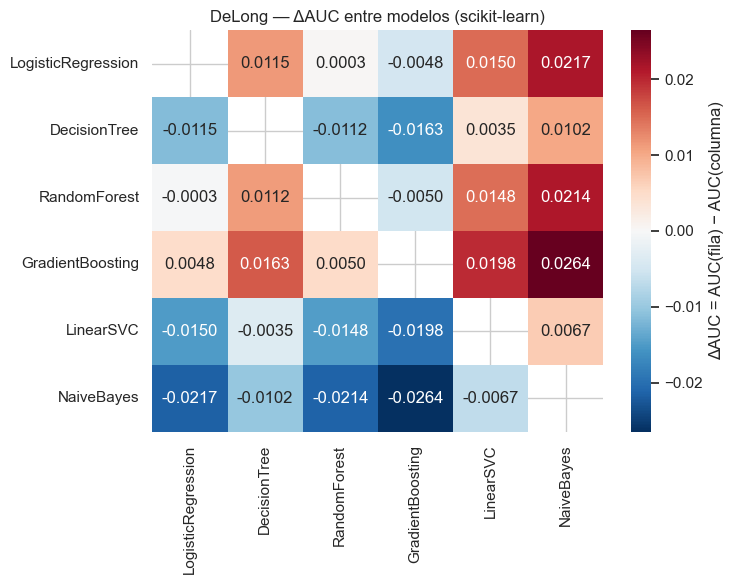

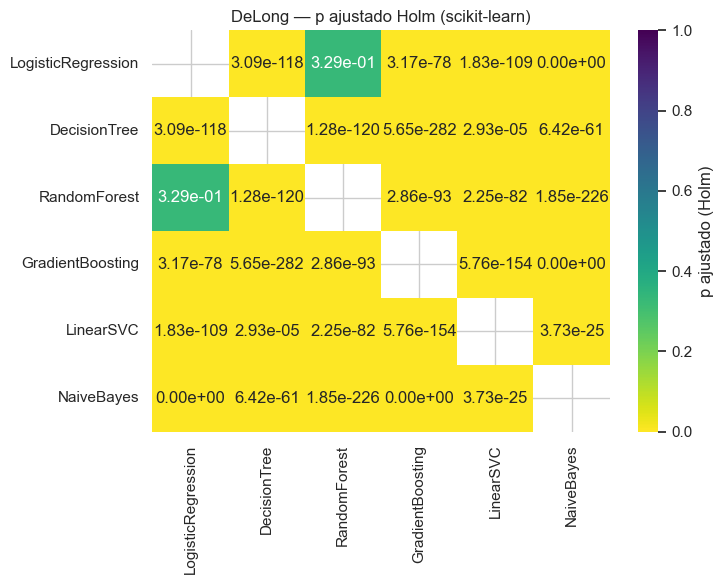

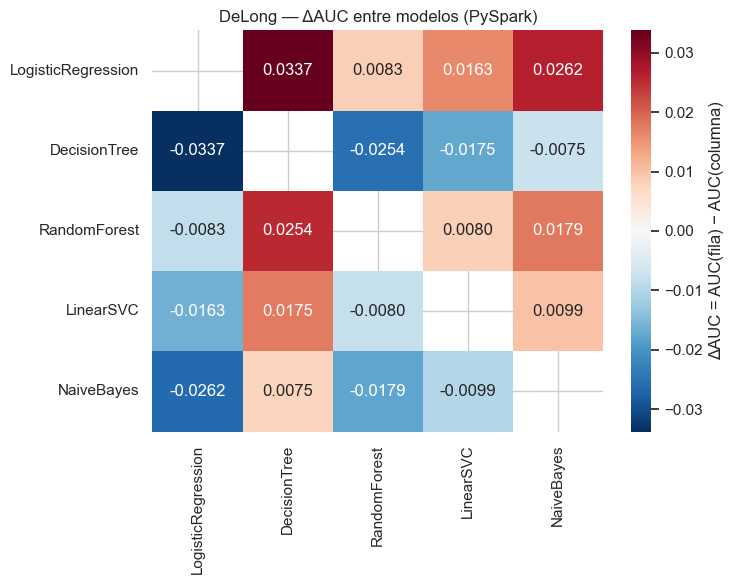

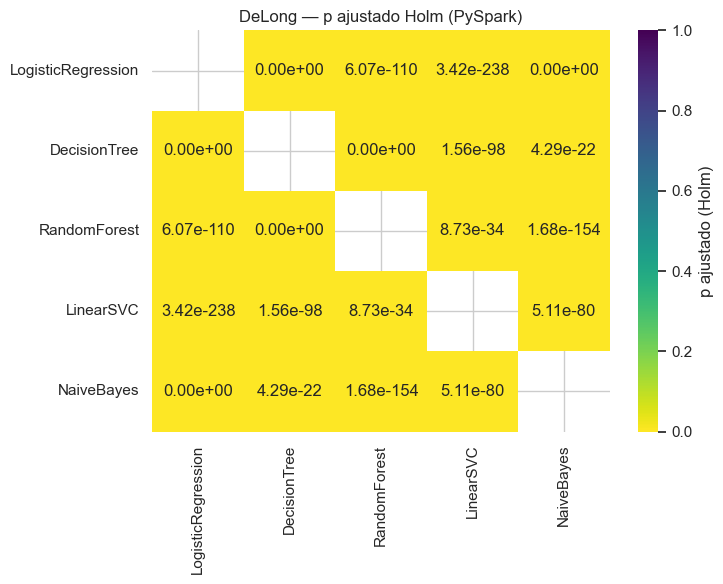

In [56]:
def heatmap_delong(tabla, valor_col, titulo, nombre_archivo):
    mat = pd.DataFrame(np.nan, index=MODELOS, columns=MODELOS)
    for _, row in tabla.iterrows():
        a, b = row["algoritmo_1"], row["algoritmo_2"]
        v = row[valor_col]
        mat.loc[a, b] = v
        mat.loc[b, a] = -v if valor_col == "delta_auc" else v   # ΔAUC es antisimétrico; p es simétrico
    mat = mat.dropna(how="all").dropna(axis=1, how="all")   # quita modelos ausentes en ese entorno
    plt.figure(figsize=(7.5, 6))
    if valor_col == "delta_auc":
        sns.heatmap(mat.astype(float), annot=True, fmt=".4f", cmap="RdBu_r", center=0,
                    cbar_kws={"label": "ΔAUC = AUC(fila) − AUC(columna)"})
    else:
        sns.heatmap(mat.astype(float), annot=True, fmt=".2e", cmap="viridis_r", vmin=0, vmax=1,
                    cbar_kws={"label": "p ajustado (Holm)"})
    plt.title(titulo)
    plt.tight_layout()
    guardar_figura(nombre_archivo)
    plt.show()


heatmap_delong(delong_sklearn, "delta_auc", "DeLong — ΔAUC entre modelos (scikit-learn)", "heatmap_delong_delta_sklearn")
heatmap_delong(delong_sklearn, "p_ajustado_holm", "DeLong — p ajustado Holm (scikit-learn)", "heatmap_delong_p_sklearn")
heatmap_delong(delong_spark, "delta_auc", "DeLong — ΔAUC entre modelos (PySpark)", "heatmap_delong_delta_spark")
heatmap_delong(delong_spark, "p_ajustado_holm", "DeLong — p ajustado Holm (PySpark)", "heatmap_delong_p_spark")

**Interpretación (DeLong):** 

Se implementó Fast DeLong (Sun y Xu, 2014) y se validó contra la versión directa O(n²) en tres conjuntos pequeños, con una diferencia máxima de 2.4 × 10⁻¹⁴. Se aplicó sobre el test completo (452,141 observaciones) con corrección de Holm dentro de cada familia (α = 0.05) y un margen de relevancia práctica de |ΔAUC| ≥ 0.005, fijado de antemano. Entre entornos, 4 de 5 comparaciones son significativas, pero solo el árbol de decisión es relevante (sklearn 0.7126 frente a Spark 0.6949, ΔAUC = +0.0177); LR, RF y LinearSVC difieren por menos de 0.005 y NaiveBayes no difiere (es el mismo algoritmo, con scores de correlación 1.0000). Dentro de sklearn, 14 de 15 pares son significativos y 12 relevantes, con tres niveles: GB ≈ LR ≈ RF (0.724–0.729), DT y LinearSVC (0.709–0.713) y NaiveBayes (0.702). Dentro de PySpark, los 10 pares son significativos y relevantes, con el orden LR > RF > LinearSVC > NaiveBayes > DT. Con tantas observaciones la significancia es casi automática, así que las conclusiones se apoyan en el margen práctico. DeLong tiene límites: solo captura la variabilidad del muestreo del test y no la del entrenamiento (el mismo árbol de Spark varió ≈ 0.002 de AUC entre dos ejecuciones, similar al semiancho del IC); supone observaciones independientes; resume todos los umbrales y puede no reflejar el umbral operativo; es menos fiable con scores muy empatados (el árbol de Spark tiene solo 11 valores distintos); y en RF mezcla diferencias de implementación con mallas distintas (2×2 en Spark, 3×3 en sklearn).

### 9.10.4.6.2. Pruebas complementarias: McNemar y bootstrap pareado

**Comparaciones** (las mismas para ambas pruebas):

- **A.** Las comparaciones sklearn vs PySpark del mismo modelo, una por cada modelo presente en ambos entornos (familia `A_entre_entornos`).
- **B.** El par de los dos modelos con mayor AUC dentro de sklearn (familia `B_top2_sklearn`).
- **C.** El par de los dos modelos con mayor AUC dentro de PySpark (familia `C_top2_spark`).

Holm se aplica **dentro de cada familia** (en B y C la familia tiene una sola comparación, así que el p ajustado
coincide con el p crudo).

**McNemar:** con las predicciones binarias (el umbral de cada (entorno, modelo) se optimizó **solo con train**, ver 9.10.4.4 y
9.10.4.5) se cuentan `b` = modelo 1 correcto / modelo 2 incorrecto y `c` = modelo 1 incorrecto / modelo 2 correcto. Si
`b + c < 25` se usa la versión exacta (binomial); si no, chi-cuadrado con corrección de continuidad. Como cada modelo tiene su propio umbral, McNemar compara puntos de
operación distintos; se discute como limitación (DeLong, que no depende del umbral, es la comparación principal).

**Bootstrap pareado:** `B = 2000` remuestreos con semilla fija; en cada remuestreo se usan **exactamente los mismos
índices** para los dos modelos y se calculan ΔROC-AUC, **ΔAUC-PR** (área bajo la curva precisión-recall calculada con
`precision_recall_curve` + `auc(recall, precision)`, no `average_precision_score`) y ΔF1. Se reporta la diferencia
media, el IC percentil 95 % (hay evidencia de diferencia si no contiene 0) y un p-valor empírico bilateral para
aplicar Holm.

*Implementación eficiente:* remuestrear con reemplazo equivale a asignar a cada observación un peso igual al número de
veces que fue elegida. Ordenando los scores una sola vez, cada métrica ponderada se calcula en O(n) y da exactamente
el mismo valor que evaluar `roc_auc_score`, `precision_recall_curve` + `auc` y `f1_score` sobre la muestra remuestreada
(se verifica numéricamente abajo antes de usarla).

In [57]:
pred_bin_cols = {clave: binarizar(clave[1], v, clave[0]) for clave, v in score_cols.items()}   # clave = (entorno, modelo)


def mcnemar_test(y_true, pred_1, pred_2):
    correcto_1, correcto_2 = (pred_1 == y_true), (pred_2 == y_true)
    b = int((correcto_1 & ~correcto_2).sum())   # modelo 1 correcto / modelo 2 incorrecto
    c = int((~correcto_1 & correcto_2).sum())   # modelo 1 incorrecto / modelo 2 correcto
    exacto = (b + c) < 25
    res = mcnemar([[0, b], [c, 0]], exact=exacto, correction=not exacto)
    return dict(b=b, c=c, estadistico=float(res.statistic), p_value=float(res.pvalue),
                version=("exacta (binomial)" if exacto else "chi2 con corrección de continuidad"))


class CurvaOrdenada:
    """Ordena un score una sola vez para evaluar ROC-AUC y AUC-PR ponderados (bootstrap) en O(n)."""

    def __init__(self, y_true, score):
        self.order = np.argsort(-np.asarray(score, dtype=float), kind="mergesort")
        self.y_sorted = np.asarray(y_true, dtype=float)[self.order]
        s_sorted = np.asarray(score, dtype=float)[self.order]
        self.fin_grupo = np.r_[np.flatnonzero(np.diff(s_sorted)), len(s_sorted) - 1]   # último índice de cada empate

    def roc_pr_auc(self, w):
        w_s = w[self.order]
        tp = np.cumsum(self.y_sorted * w_s)[self.fin_grupo]
        fp = np.cumsum((1.0 - self.y_sorted) * w_s)[self.fin_grupo]
        # Se descartan los umbrales sin observaciones remuestreadas (peso 0): así la curva es idéntica a la de la
        # muestra bootstrap explícita.
        keep = np.diff(np.r_[0.0, tp + fp]) > 0
        tp, fp = tp[keep], fp[keep]
        roc = auc(np.r_[0.0, fp / fp[-1]], np.r_[0.0, tp / tp[-1]])
        precision = tp / (tp + fp)
        recall = tp / tp[-1]
        ult = np.searchsorted(tp, tp[-1])   # igual que sklearn.metrics.precision_recall_curve
        pr = auc(np.r_[recall[ult::-1], 0.0], np.r_[precision[ult::-1], 1.0])
        return roc, pr


def f1_ponderado(y_true, pred, w):
    tp = w[(y_true == 1) & (pred == 1)].sum()
    fp = w[(y_true == 0) & (pred == 1)].sum()
    fn = w[(y_true == 1) & (pred == 0)].sum()
    den = 2 * tp + fp + fn
    return 2 * tp / den if den > 0 else 0.0


def auc_pr(y_true, score):
    precision, recall, _ = precision_recall_curve(y_true, score)
    return auc(recall, precision)


def p_empirico_bilateral(d):
    d = np.asarray(d)
    B = len(d)
    p_menor = (1 + np.sum(d <= 0)) / (B + 1)
    p_mayor = (1 + np.sum(d >= 0)) / (B + 1)
    return float(min(1.0, 2 * min(p_menor, p_mayor)))


def bootstrap_pareado(y_true, score_1, score_2, pred_1, pred_2, B=2000, seed=RANDOM_STATE):
    y_true = np.asarray(y_true).astype(int)
    n = len(y_true)
    c1, c2 = CurvaOrdenada(y_true, score_1), CurvaOrdenada(y_true, score_2)
    rng = np.random.default_rng(seed)
    d_auc, d_pr, d_f1 = np.empty(B), np.empty(B), np.empty(B)
    b = 0
    while b < B:
        w = np.bincount(rng.integers(0, n, n), minlength=n).astype(float)   # MISMOS índices para ambos modelos
        n_pos = w[y_true == 1].sum()
        if n_pos == 0 or n_pos == w.sum():
            continue
        roc1, pr1 = c1.roc_pr_auc(w)
        roc2, pr2 = c2.roc_pr_auc(w)
        d_auc[b], d_pr[b] = roc1 - roc2, pr1 - pr2
        d_f1[b] = f1_ponderado(y_true, pred_1, w) - f1_ponderado(y_true, pred_2, w)
        b += 1

    def resumen(d):
        return dict(media=float(d.mean()), ic_inf=float(np.percentile(d, 2.5)), ic_sup=float(np.percentile(d, 97.5)),
                    p_empirico=p_empirico_bilateral(d))

    return {"auc": resumen(d_auc), "auc_pr": resumen(d_pr), "f1": resumen(d_f1), "B": B}


# --- Verificación: métricas ponderadas == métricas sklearn sobre la muestra bootstrap explícita ---
rng_chk = np.random.default_rng(123)
m_chk = "RandomForest"   # tiene empates en el score
s_chk, p_chk = score_cols[("sklearn", m_chk)], pred_bin_cols[("sklearn", m_chk)]
curva_chk = CurvaOrdenada(y_common, s_chk)
dif_max = 0.0
for _ in range(3):
    idx = rng_chk.integers(0, len(y_common), len(y_common))
    w = np.bincount(idx, minlength=len(y_common)).astype(float)
    roc_w, pr_w = curva_chk.roc_pr_auc(w)
    dif_max = max(dif_max,
                  abs(roc_w - roc_auc_score(y_common[idx], s_chk[idx])),
                  abs(pr_w - auc_pr(y_common[idx], s_chk[idx])),
                  abs(f1_ponderado(y_common, p_chk, w) - f1_score(y_common[idx], p_chk[idx], zero_division=0)))
assert dif_max < 1e-9, f"El bootstrap ponderado no coincide con sklearn (dif={dif_max})"
print(f"Bootstrap ponderado verificado contra roc_auc_score / precision_recall_curve+auc / f1_score: "
      f"diferencia máxima = {dif_max:.2e}")

Bootstrap ponderado verificado contra roc_auc_score / precision_recall_curve+auc / f1_score: diferencia máxima = 1.11e-16


In [58]:
B_BOOTSTRAP = 2000
assert B_BOOTSTRAP >= 2000


def top2(entorno):
    tabla = sklearn_metrics_df if entorno == "sklearn" else spark_metrics_df
    return tabla["roc_auc"].astype(float).sort_values(ascending=False).index[:2].tolist()


top2_sklearn, top2_spark = top2("sklearn"), top2("spark")
print(f"Top-2 AUC sklearn: {top2_sklearn} | Top-2 AUC PySpark: {top2_spark}")

COMPARACIONES_COMPLEMENTARIAS = (
    [("A_entre_entornos", ("sklearn", m), ("spark", m)) for m in MODELOS_AMBOS]
    + [("B_top2_sklearn", ("sklearn", top2_sklearn[0]), ("sklearn", top2_sklearn[1]))]
    + [("C_top2_spark", ("spark", top2_spark[0]), ("spark", top2_spark[1]))]
)

filas_mcn, filas_boot = [], []
for familia, k1, k2 in COMPARACIONES_COMPLEMENTARIAS:
    nombre = f"{k1[0]}:{k1[1]} vs {k2[0]}:{k2[1]}"
    mcn = mcnemar_test(y_common, pred_bin_cols[k1], pred_bin_cols[k2])
    filas_mcn.append({"familia": familia, "comparacion": nombre, **mcn})
    t0 = time.perf_counter()
    bt = bootstrap_pareado(y_common, score_cols[k1], score_cols[k2], pred_bin_cols[k1], pred_bin_cols[k2],
                           B=B_BOOTSTRAP, seed=RANDOM_STATE)
    fila = {"familia": familia, "comparacion": nombre, "B": bt["B"]}
    for met in ("auc", "auc_pr", "f1"):
        fila.update({f"delta_{met}_media": bt[met]["media"], f"delta_{met}_ic95_inf": bt[met]["ic_inf"],
                     f"delta_{met}_ic95_sup": bt[met]["ic_sup"], f"delta_{met}_p_empirico": bt[met]["p_empirico"],
                     f"delta_{met}_ic_excluye_0": not (bt[met]["ic_inf"] <= 0 <= bt[met]["ic_sup"])})
    filas_boot.append(fila)
    print(f"{nombre}: McNemar b={mcn['b']:,} c={mcn['c']:,} p={mcn['p_value']:.3g} | "
          f"bootstrap ΔAUC={bt['auc']['media']:+.4f} [{bt['auc']['ic_inf']:+.4f}, {bt['auc']['ic_sup']:+.4f}] "
          f"({time.perf_counter() - t0:,.0f} s)")

mcnemar_df = pd.DataFrame(filas_mcn)
bootstrap_df = pd.DataFrame(filas_boot)

# Holm dentro de cada familia
mcnemar_df["p_ajustado_holm"] = mcnemar_df.groupby("familia")["p_value"].transform(
    lambda p: multipletests(p, alpha=ALPHA, method="holm")[1])
mcnemar_df["significativo_holm"] = mcnemar_df["p_ajustado_holm"] < ALPHA
for met in ("auc", "auc_pr", "f1"):
    col = f"delta_{met}_p_empirico"
    bootstrap_df[f"delta_{met}_p_holm"] = bootstrap_df.groupby("familia")[col].transform(
        lambda p: multipletests(p, alpha=ALPHA, method="holm")[1])
    bootstrap_df[f"delta_{met}_significativo_holm"] = bootstrap_df[f"delta_{met}_p_holm"] < ALPHA

print("McNemar:")
display(mcnemar_df)
print("Bootstrap pareado:")
display(bootstrap_df)
mcnemar_df.to_csv(ARTIFACTS_DIR / "mcnemar.csv", index=False)
bootstrap_df.to_csv(ARTIFACTS_DIR / "bootstrap_pareado.csv", index=False)

Top-2 AUC sklearn: ['GradientBoosting', 'LogisticRegression'] | Top-2 AUC PySpark: ['LogisticRegression', 'RandomForest']
sklearn:LogisticRegression vs spark:LogisticRegression: McNemar b=10,477 c=7,100 p=4.91e-143 | bootstrap ΔAUC=-0.0045 [-0.0048, -0.0042] (161 s)
sklearn:DecisionTree vs spark:DecisionTree: McNemar b=59,212 c=9,057 p=0 | bootstrap ΔAUC=+0.0177 [+0.0167, +0.0187] (68 s)
sklearn:RandomForest vs spark:RandomForest: McNemar b=45,937 c=7,481 p=0 | bootstrap ΔAUC=+0.0035 [+0.0033, +0.0038] (161 s)
sklearn:LinearSVC vs spark:LinearSVC: McNemar b=5,469 c=22,879 p=0 | bootstrap ΔAUC=-0.0033 [-0.0040, -0.0026] (118 s)
sklearn:NaiveBayes vs spark:NaiveBayes: McNemar b=1,899 c=369 p=3.64e-226 | bootstrap ΔAUC=-0.0000 [-0.0000, +0.0000] (332 s)
sklearn:GradientBoosting vs sklearn:LogisticRegression: McNemar b=10,336 c=11,306 p=4.49e-11 | bootstrap ΔAUC=+0.0048 [+0.0043, +0.0053] (121 s)
spark:LogisticRegression vs spark:RandomForest: McNemar b=58,181 c=10,348 p=0 | bootstrap ΔAUC

,familia,comparacion,b,c,estadistico,p_value,version,p_ajustado_holm,significativo_holm
0,A_entre_entornos,sklearn:LogisticRegression vs spark:LogisticRe...,10477,7100,648.425556,4.914986e-143,chi2 con corrección de continuidad,4.914986e-143,True
1,A_entre_entornos,sklearn:DecisionTree vs spark:DecisionTree,59212,9057,36845.767713,0.000000e+00,chi2 con corrección de continuidad,0.000000e+00,True
2,A_entre_entornos,sklearn:RandomForest vs spark:RandomForest,45937,7481,27683.309465,0.000000e+00,chi2 con corrección de continuidad,0.000000e+00,True
3,A_entre_entornos,sklearn:LinearSVC vs spark:LinearSVC,5469,22879,10691.169783,0.000000e+00,chi2 con corrección de continuidad,0.000000e+00,True
4,A_entre_entornos,sklearn:NaiveBayes vs spark:NaiveBayes,1899,369,1030.794092,3.637817e-226,chi2 con corrección de continuidad,7.275633e-226,True
5,B_top2_sklearn,sklearn:GradientBoosting vs sklearn:LogisticRe...,10336,11306,43.386055,4.493793e-11,chi2 con corrección de continuidad,4.493793e-11,True
6,C_top2_spark,spark:LogisticRegression vs spark:RandomForest,58181,10348,33385.869107,0.000000e+00,chi2 con corrección de continuidad,0.000000e+00,True


Bootstrap pareado:


,familia,comparacion,B,delta_auc_media,delta_auc_ic95_inf,delta_auc_ic95_sup,delta_auc_p_empirico,delta_auc_ic_excluye_0,delta_auc_pr_media,delta_auc_pr_ic95_inf,delta_auc_pr_ic95_sup,delta_auc_pr_p_empirico,delta_auc_pr_ic_excluye_0,delta_f1_media,delta_f1_ic95_inf,delta_f1_ic95_sup,delta_f1_p_empirico,delta_f1_ic_excluye_0,delta_auc_p_holm,delta_auc_significativo_holm,delta_auc_pr_p_holm,delta_auc_pr_significativo_holm,delta_f1_p_holm,delta_f1_significativo_holm
0,A_entre_entornos,sklearn:LogisticRegression vs spark:LogisticRe...,2000,-0.004508,-0.004812,-0.004192,0.001000,True,-0.001421,-0.002052,-0.000752,0.001,True,-0.003727,-0.004941,-0.002489,0.001000,True,0.004998,True,0.004998,True,0.004998,True
1,A_entre_entornos,sklearn:DecisionTree vs spark:DecisionTree,2000,0.017709,0.016714,0.018715,0.001000,True,-0.114664,-0.117106,-0.112175,0.001,True,0.018564,0.016987,0.020149,0.001000,True,0.004998,True,0.004998,True,0.004998,True
2,A_entre_entornos,sklearn:RandomForest vs spark:RandomForest,2000,0.003510,0.003276,0.003755,0.001000,True,0.003152,0.002460,0.003880,0.001,True,0.010389,0.008858,0.011938,0.001000,True,0.004998,True,0.004998,True,0.004998,True
3,A_entre_entornos,sklearn:LinearSVC vs spark:LinearSVC,2000,-0.003286,-0.003966,-0.002592,0.001000,True,-0.004485,-0.005334,-0.003618,0.001,True,-0.002714,-0.003596,-0.001821,0.001000,True,0.004998,True,0.004998,True,0.004998,True
4,A_entre_entornos,sklearn:NaiveBayes vs spark:NaiveBayes,2000,-0.000007,-0.000016,0.000001,0.109945,False,0.002040,0.001727,0.002339,0.001,True,-0.000173,-0.000547,0.000191,0.366817,False,0.109945,False,0.004998,True,0.366817,False
5,B_top2_sklearn,sklearn:GradientBoosting vs sklearn:LogisticRe...,2000,0.004759,0.004270,0.005282,0.001000,True,0.004333,0.003344,0.005328,0.001,True,-0.001593,-0.002904,-0.000246,0.017991,True,0.001000,True,0.001000,True,0.017991,True
6,C_top2_spark,spark:LogisticRegression vs spark:RandomForest,2000,0.008286,0.007554,0.009007,0.001000,True,0.007882,0.006379,0.009381,0.001,True,0.020247,0.018439,0.022035,0.001000,True,0.001000,True,0.001000,True,0.001000,True


#### Tabla de las tres pruebas

Para cada comparación de 9.10.4.6.2 se reúnen DeLong (ΔAUC, IC 95 %, p Holm de su familia de 6 o 15,
significancia y relevancia práctica), McNemar (p Holm y significancia) y bootstrap (ΔAUC, ΔAUC-PR y ΔF1 con IC 95 %).

**Regla de la columna `interpretacion`** (fijada antes de ver resultados):

- *coinciden*: DeLong, McNemar y bootstrap-ΔAUC (p Holm) llegan a la misma conclusión (las tres detectan diferencia o
  ninguna la detecta).
- *discrepan*: DeLong y bootstrap-ΔAUC —que miden la misma cantidad, ΔAUC— llegan a conclusiones opuestas, o ambas
  son significativas pero con signos opuestos.
- *coinciden parcialmente*: el resto; típicamente DeLong y bootstrap coinciden y McNemar no, lo que es esperable
  porque McNemar compara errores con un umbral fijo y no la capacidad de ordenamiento (AUC).

In [59]:
def buscar_delong(k1, k2):
    """Fila DeLong de la familia correspondiente, orientada como (k1 - k2)."""
    a, b = f"{k1[0]}:{k1[1]}", f"{k2[0]}:{k2[1]}"
    fila = delong_todas[(delong_todas["modelo_1"] == a) & (delong_todas["modelo_2"] == b)]
    if len(fila):
        r = fila.iloc[0]
        return r["delta_auc"], r["ic95_delta_inf"], r["ic95_delta_sup"], r["p_ajustado_holm"], r["significativo_holm"]
    r = delong_todas[(delong_todas["modelo_1"] == b) & (delong_todas["modelo_2"] == a)].iloc[0]
    return -r["delta_auc"], -r["ic95_delta_sup"], -r["ic95_delta_inf"], r["p_ajustado_holm"], r["significativo_holm"]


def fmt_ic(v, lo, hi, dec=4):
    return f"{v:+.{dec}f} [{lo:+.{dec}f}, {hi:+.{dec}f}]"


filas = []
for (familia, k1, k2), mcn, bt in zip(COMPARACIONES_COMPLEMENTARIAS, mcnemar_df.to_dict("records"),
                                      bootstrap_df.to_dict("records")):
    d, lo, hi, p_dl, sig_dl = buscar_delong(k1, k2)
    sig_mcn = bool(mcn["significativo_holm"])
    sig_bt = bool(bt["delta_auc_significativo_holm"])
    signo_opuesto = sig_dl and sig_bt and np.sign(d) != np.sign(bt["delta_auc_media"])
    if (sig_dl != sig_bt) or signo_opuesto:
        interp = "discrepan"
    elif sig_dl == sig_mcn == sig_bt:
        interp = "coinciden"
    else:
        interp = "coinciden parcialmente"
    filas.append({
        "familia": familia, "comparacion": mcn["comparacion"],
        "DeLong_ΔAUC_IC95": fmt_ic(d, lo, hi), "DeLong_p_holm": p_dl, "DeLong_significativo": bool(sig_dl),
        "DeLong_relevante_practica": abs(d) >= PRACTICAL_AUC_MARGIN,
        "McNemar_b": mcn["b"], "McNemar_c": mcn["c"], "McNemar_version": mcn["version"],
        "McNemar_p_holm": mcn["p_ajustado_holm"], "McNemar_significativo": sig_mcn,
        "Boot_ΔAUC_IC95": fmt_ic(bt["delta_auc_media"], bt["delta_auc_ic95_inf"], bt["delta_auc_ic95_sup"]),
        "Boot_ΔAUC_p_holm": bt["delta_auc_p_holm"], "Boot_ΔAUC_significativo": sig_bt,
        "Boot_ΔAUCPR_IC95": fmt_ic(bt["delta_auc_pr_media"], bt["delta_auc_pr_ic95_inf"], bt["delta_auc_pr_ic95_sup"]),
        "Boot_ΔF1_IC95": fmt_ic(bt["delta_f1_media"], bt["delta_f1_ic95_inf"], bt["delta_f1_ic95_sup"]),
        "DeLong_vs_Boot_AUC": "misma conclusión" if sig_dl == sig_bt and not signo_opuesto else "distinta conclusión",
        "interpretacion": interp,
    })

resumen_tres_pruebas = pd.DataFrame(filas)
display(resumen_tres_pruebas)
resumen_tres_pruebas.to_csv(ARTIFACTS_DIR / "resumen_tres_pruebas.csv", index=False)
print("Conteo de la interpretación:", resumen_tres_pruebas["interpretacion"].value_counts().to_dict())

,familia,comparacion,DeLong_ΔAUC_IC95,DeLong_p_holm,DeLong_significativo,DeLong_relevante_practica,McNemar_b,McNemar_c,McNemar_version,McNemar_p_holm,McNemar_significativo,Boot_ΔAUC_IC95,Boot_ΔAUC_p_holm,Boot_ΔAUC_significativo,Boot_ΔAUCPR_IC95,Boot_ΔF1_IC95,DeLong_vs_Boot_AUC,interpretacion
0,A_entre_entornos,sklearn:LogisticRegression vs spark:LogisticRe...,"-0.0045 [-0.0048, -0.0042]",2.202096e-171,True,False,10477,7100,chi2 con corrección de continuidad,4.914986e-143,True,"-0.0045 [-0.0048, -0.0042]",0.004998,True,"-0.0014 [-0.0021, -0.0008]","-0.0037 [-0.0049, -0.0025]",misma conclusión,coinciden
1,A_entre_entornos,sklearn:DecisionTree vs spark:DecisionTree,"+0.0177 [+0.0167, +0.0187]",2.661937e-267,True,True,59212,9057,chi2 con corrección de continuidad,0.000000e+00,True,"+0.0177 [+0.0167, +0.0187]",0.004998,True,"-0.1147 [-0.1171, -0.1122]","+0.0186 [+0.0170, +0.0201]",misma conclusión,coinciden
2,A_entre_entornos,sklearn:RandomForest vs spark:RandomForest,"+0.0035 [+0.0033, +0.0038]",3.003081e-181,True,False,45937,7481,chi2 con corrección de continuidad,0.000000e+00,True,"+0.0035 [+0.0033, +0.0038]",0.004998,True,"+0.0032 [+0.0025, +0.0039]","+0.0104 [+0.0089, +0.0119]",misma conclusión,coinciden
3,A_entre_entornos,sklearn:LinearSVC vs spark:LinearSVC,"-0.0033 [-0.0040, -0.0026]",9.896563e-19,True,False,5469,22879,chi2 con corrección de continuidad,0.000000e+00,True,"-0.0033 [-0.0040, -0.0026]",0.004998,True,"-0.0045 [-0.0053, -0.0036]","-0.0027 [-0.0036, -0.0018]",misma conclusión,coinciden
4,A_entre_entornos,sklearn:NaiveBayes vs spark:NaiveBayes,"-0.0000 [-0.0000, +0.0000]",1.073808e-01,False,False,1899,369,chi2 con corrección de continuidad,7.275633e-226,True,"-0.0000 [-0.0000, +0.0000]",0.109945,False,"+0.0020 [+0.0017, +0.0023]","-0.0002 [-0.0005, +0.0002]",misma conclusión,coinciden parcialmente
5,B_top2_sklearn,sklearn:GradientBoosting vs sklearn:LogisticRe...,"+0.0048 [+0.0043, +0.0053]",3.168628e-78,True,False,10336,11306,chi2 con corrección de continuidad,4.493793e-11,True,"+0.0048 [+0.0043, +0.0053]",0.001000,True,"+0.0043 [+0.0033, +0.0053]","-0.0016 [-0.0029, -0.0002]",misma conclusión,coinciden
6,C_top2_spark,spark:LogisticRegression vs spark:RandomForest,"+0.0083 [+0.0076, +0.0090]",6.074742e-110,True,True,58181,10348,chi2 con corrección de continuidad,0.000000e+00,True,"+0.0083 [+0.0076, +0.0090]",0.001000,True,"+0.0079 [+0.0064, +0.0094]","+0.0202 [+0.0184, +0.0220]",misma conclusión,coinciden


Conteo de la interpretación: {'coinciden': 6, 'coinciden parcialmente': 1}


**Interpretación (McNemar, bootstrap y concordancia de las tres pruebas):** 

Cada modelo usa el umbral que maximiza el F1 con predicciones out-of-fold solo de train, así que McNemar compara puntos de operación distintos y no modelos. Con 452,141 observaciones las 7 comparaciones salen significativas tras Holm, y el caso más claro de que mide umbrales es NaiveBayes: sus scores en sklearn y Spark son prácticamente idénticos (correlación 1.0000, mismo AUC), pero los umbrales difieren (0.0280 y 0.0250) y aun así McNemar rechaza (b = 1,899, c = 369). Además trata todos los errores por igual, y como el 88 % de los casos son de la clase mayoritaria dominan los falsos positivos, de modo que mide sobre todo cuántos buenos pagadores se señalan y no la detección de incumplimientos. En GB frente a LR de sklearn, el AUC favorece a GB (+0.0048), pero McNemar y el ΔF1 (−0.0016) favorecen a LR: el mejor ranking no es el mejor punto de operación. El bootstrap pareado (B = 2000, semilla fija, mismos índices) coincide con DeLong en el ΔAUC de las 7 comparaciones. El ΔAUC-PR es significativo en las 7, pero el del árbol (−0.1147) es un artefacto: el árbol de Spark tiene solo 11 scores distintos y el área trapezoidal queda inflada (0.3815 frente a 0.1949 de precisión promedio), por lo que no debe interpretarse como diferencia real. Los ΔF1 son pequeños (entre −0.0037 y +0.0119), y el de NaiveBayes entre entornos no es significativo. Las tres pruebas coinciden en general; la única discrepancia es NaiveBayes entre entornos, donde DeLong y el bootstrap no ven diferencia de AUC (p = 0.107 y 0.110) pero McNemar sí, por los umbrales distintos. La conclusión robusta es que las pruebas miden cosas distintas: DeLong y el bootstrap de AUC miden ordenamiento, McNemar mide decisiones en un umbral, y el AUC-PR y el F1 miden el desempeño en la clase minoritaria.

## 9.10.4.7. Interpretabilidad con LIME

- Se aplica al **modelo con mayor AUC de cada entorno entre los que producen probabilidades** (`LinearSVC` queda
  excluido porque solo entrega un margen de decisión).
- **sklearn:** se eligen 1–2 observaciones de test **mal clasificadas por el mejor modelo de sklearn** (un falso
  negativo y un falso positivo cuando existen).
- **PySpark:** se eligen 1–2 observaciones **mal clasificadas por el mejor modelo de Spark**, a partir de sus propias
  predicciones (no se reutilizan las de sklearn).
- Las explicaciones se leen sobre las variables **originales** (antes del one-hot): cada `predict_fn` recibe las
  variables crudas y aplica el mismo preprocesamiento ya ajustado con train (imputadores/encoder/escalador de sklearn o
  el `Pipeline` de Spark).
- **Background de LIME:** una muestra local limitada del train (`LIME_BACKGROUND_N` filas, semilla fija). *Esta muestra
  se usa exclusivamente como background de LIME; los modelos se entrenaron y evaluaron con el dataset completo.*
- Se guardan **HTML y PNG** de cada explicación y se muestra la tabla de variables más influyentes.

**Limitación en PySpark:** LIME trabaja en memoria local (driver), aunque el modelo de Spark se haya entrenado de forma
distribuida. Cada llamada a `predict_fn` crea un `DataFrame` de Spark pequeño con las perturbaciones, lo transforma y
trae **solo ese lote** al driver; esto paga el costo fijo de planificar un trabajo de Spark en cada llamada y es mucho
más lento que la versión local de sklearn, por eso se usa un `num_samples` menor en Spark.

In [60]:
import lime
import lime.lime_tabular

LIME_BACKGROUND_N = 10_000       # muestra local SOLO como background de LIME
LIME_NUM_FEATURES = 8
NUM_SAMPLES_SKLEARN_LIME = 5000  # valor por defecto de LIME
NUM_SAMPLES_SPARK_LIME = 500     # reducido: cada lote de perturbaciones pasa por Spark

LIME_FEATURE_NAMES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
CAT_IDX = list(range(len(NUMERIC_FEATURES), len(LIME_FEATURE_NAMES)))
MEDIANAS_TRAIN = dict(zip(NUMERIC_FEATURES, num_imputer.statistics_))   # medianas de train (sklearn)

# Categorías: todas las vistas en train (no solo en la muestra) para poder codificar cualquier instancia de test.
cat_uniques, cat_to_code, cat_moda = {}, {}, {}
for idx, col in zip(CAT_IDX, CATEGORICAL_FEATURES):
    valores = train_df[col].astype(object).where(train_df[col].notna(), "Missing").astype(str)
    cats = sorted(valores.unique().tolist())
    cat_uniques[idx] = cats
    cat_to_code[idx] = {v: i for i, v in enumerate(cats)}
    cat_moda[idx] = cat_to_code[idx][valores.mode().iloc[0]]


def codificar_para_lime(frame):
    """Variables crudas -> matriz numérica que entiende LIME (numéricas imputadas con la mediana de train;
    categóricas como código entero)."""
    out = np.empty((len(frame), len(LIME_FEATURE_NAMES)), dtype=float)
    for j, col in enumerate(NUMERIC_FEATURES):
        out[:, j] = pd.to_numeric(frame[col], errors="coerce").fillna(MEDIANAS_TRAIN[col]).to_numpy()
    for idx, col in zip(CAT_IDX, CATEGORICAL_FEATURES):
        valores = frame[col].astype(object).where(frame[col].notna(), "Missing").astype(str)
        out[:, idx] = [cat_to_code[idx].get(v, cat_moda[idx]) for v in valores]
    return out


# La muestra se utiliza exclusivamente como background de LIME (no para entrenar ni evaluar modelos).
lime_background_df = train_df.sample(n=min(LIME_BACKGROUND_N, len(train_df)), random_state=RANDOM_STATE)
explainer = lime.lime_tabular.LimeTabularExplainer(
    codificar_para_lime(lime_background_df), feature_names=LIME_FEATURE_NAMES, categorical_features=CAT_IDX,
    categorical_names=cat_uniques, class_names=["No Charged Off", "Charged Off"], mode="classification",
    discretize_continuous=True, random_state=RANDOM_STATE,
)


def _raw_batch_a_dataframe(raw_array):
    """Perturbaciones de LIME -> DataFrame con las variables crudas ('Missing' vuelve a ser faltante)."""
    batch = pd.DataFrame(raw_array, columns=LIME_FEATURE_NAMES)
    for idx, col in zip(CAT_IDX, CATEGORICAL_FEATURES):
        codes = batch[col].round().astype(int).clip(0, len(cat_uniques[idx]) - 1)
        batch[col] = [cat_uniques[idx][c] for c in codes]
        batch[col] = batch[col].astype(object).where(batch[col] != "Missing", np.nan)
    for col in NUMERIC_FEATURES:
        batch[col] = batch[col].astype(float)
    return batch

In [61]:
MODELOS_CON_PROBA = [m for m in MODELOS if m != "LinearSVC"]
mejor_sklearn = sklearn_metrics_df.loc[MODELOS_CON_PROBA, "roc_auc"].astype(float).idxmax()
MODELOS_CON_PROBA_SPARK = [m for m in MODELOS_SPARK if m != "LinearSVC"]
mejor_spark = spark_metrics_df.loc[MODELOS_CON_PROBA_SPARK, "roc_auc"].astype(float).idxmax()
print(f"Mejor modelo con probabilidades — sklearn: {mejor_sklearn} | PySpark: {mejor_spark}")


def predict_fn_sklearn(raw_array):
    batch = _raw_batch_a_dataframe(raw_array)
    num = scaler.transform(num_imputer.transform(batch[NUMERIC_FEATURES]))
    cat = ohe.transform(cat_imputer.transform(_categoricas_como_objeto(batch)))
    X = sp.hstack([sp.csr_matrix(num), cat], format="csr")
    if mejor_sklearn in MODELOS_REQUIEREN_DENSO:
        X = X.toarray()
    return sklearn_fitted_models[mejor_sklearn].predict_proba(X)


LIME_SCHEMA = StructType([StructField(c, DoubleType(), True) for c in NUMERIC_FEATURES]
                         + [StructField(c, StringType(), True) for c in CATEGORICAL_FEATURES])


def predict_fn_spark(raw_array):
    batch = _raw_batch_a_dataframe(raw_array)
    for col in CATEGORICAL_FEATURES:
        batch[col] = batch[col].astype(object).where(batch[col].notna(), None)
    sdf_batch = spark.createDataFrame(batch, schema=LIME_SCHEMA)   # solo el lote local de perturbaciones
    pred = spark_fitted_models[mejor_spark].transform(prep_model.transform(sdf_batch))
    probs = pred.select(vector_to_array("probability").alias("p")).toPandas()["p"]   # lote pequeño, post-entrenamiento
    return np.vstack(probs.to_numpy())


test_por_id = test_df.set_index("id")


def seleccionar_mal_clasificadas(ids, y_true, score, nombre_modelo, entorno, n=2, seed=RANDOM_STATE):
    """Hasta n ids mal clasificados por ESTE modelo: un falso negativo y un falso positivo si existen."""
    pred = binarizar(nombre_modelo, score, entorno)
    rng = np.random.default_rng(seed)
    fn = np.flatnonzero((y_true == 1) & (pred == 0))
    fp = np.flatnonzero((y_true == 0) & (pred == 1))
    elegidas = [int(rng.choice(g)) for g in (fn, fp) if len(g)]
    resto = np.setdiff1d(np.flatnonzero(pred != y_true), elegidas)
    while len(elegidas) < n and len(resto):
        elegidas.append(int(resto[0]))
        resto = resto[1:]
    return [(str(ids[i]), int(y_true[i]), float(score[i]), int(pred[i])) for i in elegidas[:n]]


lime_resumen = []


def explicar(entorno, modelo, caso, predict_fn, num_samples):
    fila_id, real, score, pred = caso
    x = codificar_para_lime(test_por_id.loc[[fila_id], LIME_FEATURE_NAMES].reset_index(drop=True))[0]
    t0 = time.perf_counter()
    exp = explainer.explain_instance(x, predict_fn, num_features=LIME_NUM_FEATURES, num_samples=num_samples)
    t_lime = time.perf_counter() - t0
    base = f"lime_{entorno}_{modelo}_id{fila_id}"
    exp.save_to_file(str(LIME_DIR / f"{base}.html"))
    fig = exp.as_pyplot_figure()
    plt.title(f"LIME — {modelo} ({entorno}) — id {fila_id} | real={real}, pred={pred}, score={score:.3f}", fontsize=9)
    plt.tight_layout()
    fig.savefig(LIME_DIR / f"{base}.png", dpi=120, bbox_inches="tight")
    plt.show()
    pesos = pd.DataFrame(exp.as_list(), columns=["condicion", "peso_hacia_Charged_Off"])
    display(pesos)
    lime_resumen.append({"entorno": entorno, "modelo": modelo, "id": fila_id, "real": real, "pred": pred,
                         "score": score, "num_samples": num_samples, "tiempo_s": t_lime,
                         "top_3": "; ".join(pesos["condicion"].head(3)),
                         "html": str(LIME_DIR / f"{base}.html"), "png": str(LIME_DIR / f"{base}.png")})

Mejor modelo con probabilidades — sklearn: GradientBoosting | PySpark: LogisticRegression


Instancias (id, real, score, pred) mal clasificadas por GradientBoosting (sklearn): [('58191133', 1, 0.3802642232886093, 0), ('8608795', 0, 0.7688016482664889, 1)]


  File "c:\Users\juand\miniconda3\envs\ml_venv\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "c:\Users\juand\miniconda3\envs\ml_venv\lib\subprocess.py", line 505, in run
    with Popen(*popenargs, **kwargs) as process:
  File "c:\Users\juand\miniconda3\envs\ml_venv\lib\subprocess.py", line 951, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\juand\miniconda3\envs\ml_venv\lib\subprocess.py", line 1436, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,


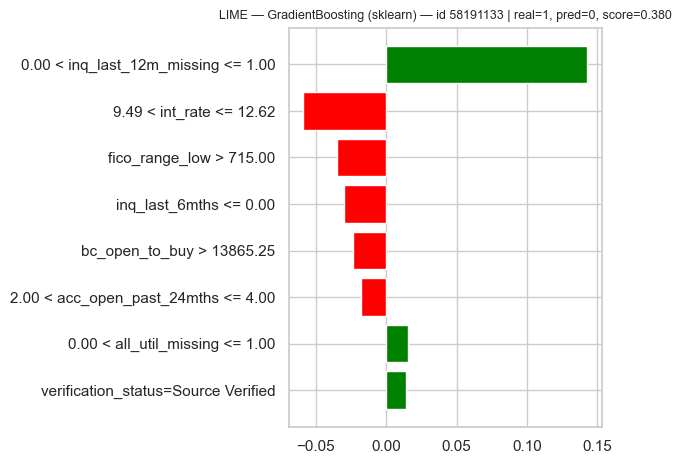

,condicion,peso_hacia_Charged_Off
0,0.00 < inq_last_12m_missing <= 1.00,0.142930
1,9.49 < int_rate <= 12.62,-0.059173
2,fico_range_low > 715.00,-0.035064
3,inq_last_6mths <= 0.00,-0.029756
4,bc_open_to_buy > 13865.25,-0.023811
5,2.00 < acc_open_past_24mths <= 4.00,-0.018133
6,0.00 < all_util_missing <= 1.00,0.015722
7,verification_status=Source Verified,0.014056


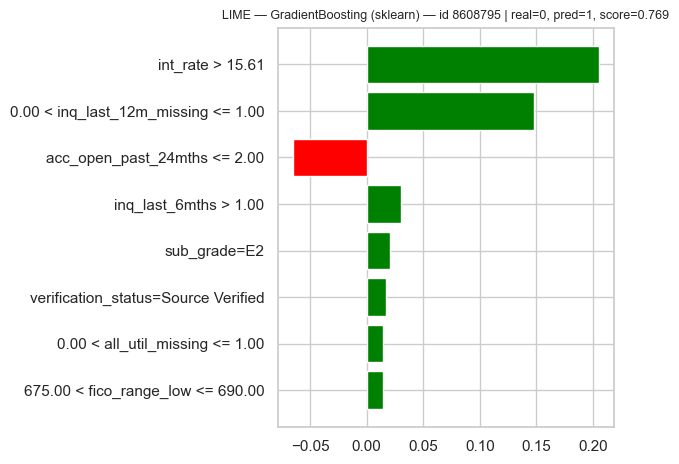

,condicion,peso_hacia_Charged_Off
0,int_rate > 15.61,0.205043
1,0.00 < inq_last_12m_missing <= 1.00,0.147957
2,acc_open_past_24mths <= 2.00,-0.065090
3,inq_last_6mths > 1.00,0.030475
4,sub_grade=E2,0.020386
5,verification_status=Source Verified,0.017007
6,0.00 < all_util_missing <= 1.00,0.014679
7,675.00 < fico_range_low <= 690.00,0.014270


In [62]:
# --- sklearn: instancias mal clasificadas por EL MEJOR MODELO DE SKLEARN ---
casos_sklearn = seleccionar_mal_clasificadas(id_test, y_test, sklearn_scores[mejor_sklearn], mejor_sklearn, "sklearn")
print(f"Instancias (id, real, score, pred) mal clasificadas por {mejor_sklearn} (sklearn): {casos_sklearn}")
for caso in casos_sklearn:
    explicar("sklearn", mejor_sklearn, caso, predict_fn_sklearn, NUM_SAMPLES_SKLEARN_LIME)

Instancias (id, real, score, pred) mal clasificadas por LogisticRegression (PySpark): [('85138321', 1, 0.4950967404325275, 0), ('42905253', 0, 0.7481761384615434, 1)]
[checkpoint] LogisticRegression: reajustando con sus mejores hiperparámetros para LIME (no se cronometra).


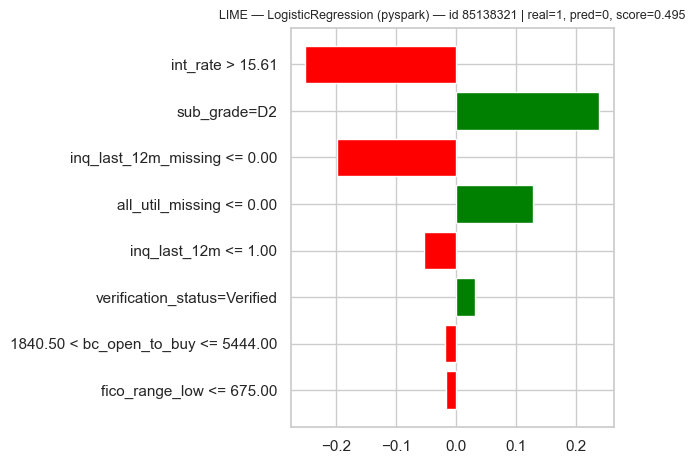

,condicion,peso_hacia_Charged_Off
0,int_rate > 15.61,-0.252078
1,sub_grade=D2,0.238452
2,inq_last_12m_missing <= 0.00,-0.199936
3,all_util_missing <= 0.00,0.127891
4,inq_last_12m <= 1.00,-0.053576
5,verification_status=Verified,0.031078
6,1840.50 < bc_open_to_buy <= 5444.00,-0.019042
7,fico_range_low <= 675.00,-0.017182


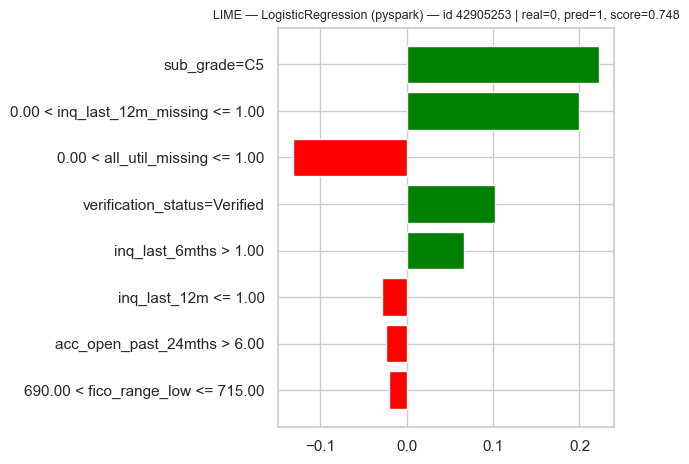

,condicion,peso_hacia_Charged_Off
0,sub_grade=C5,0.222264
1,0.00 < inq_last_12m_missing <= 1.00,0.199615
2,0.00 < all_util_missing <= 1.00,-0.131674
3,verification_status=Verified,0.102093
4,inq_last_6mths > 1.00,0.066067
5,inq_last_12m <= 1.00,-0.028947
6,acc_open_past_24mths > 6.00,-0.024594
7,690.00 < fico_range_low <= 715.00,-0.020596


,entorno,modelo,id,real,pred,score,num_samples,tiempo_s,top_3,html,png
0,sklearn,GradientBoosting,58191133,1,0,0.380264,5000,0.246984,0.00 < inq_last_12m_missing <= 1.00; 9.49 < in...,artifacts_modelado\lime\lime_sklearn_GradientB...,artifacts_modelado\lime\lime_sklearn_GradientB...
1,sklearn,GradientBoosting,8608795,0,1,0.768802,5000,0.089267,int_rate > 15.61; 0.00 < inq_last_12m_missing ...,artifacts_modelado\lime\lime_sklearn_GradientB...,artifacts_modelado\lime\lime_sklearn_GradientB...
2,pyspark,LogisticRegression,85138321,1,0,0.495097,500,26.231437,int_rate > 15.61; sub_grade=D2; inq_last_12m_m...,artifacts_modelado\lime\lime_pyspark_LogisticR...,artifacts_modelado\lime\lime_pyspark_LogisticR...
3,pyspark,LogisticRegression,42905253,0,1,0.748176,500,0.394971,sub_grade=C5; 0.00 < inq_last_12m_missing <= 1...,artifacts_modelado\lime\lime_pyspark_LogisticR...,artifacts_modelado\lime\lime_pyspark_LogisticR...


In [63]:
# --- PySpark: instancias mal clasificadas por EL MEJOR MODELO DE SPARK (a partir de sus propias predicciones) ---
spk_best = spark_scores_frames[mejor_spark]
casos_spark = seleccionar_mal_clasificadas(spk_best["id"].to_numpy(), spk_best["default"].to_numpy().astype(int),
                                           spk_best["score"].to_numpy(), mejor_spark, "spark")
print(f"Instancias (id, real, score, pred) mal clasificadas por {mejor_spark} (PySpark): {casos_spark}")
for caso in casos_spark:
    explicar("pyspark", mejor_spark, caso, predict_fn_spark, NUM_SAMPLES_SPARK_LIME)

lime_resumen_df = pd.DataFrame(lime_resumen)
display(lime_resumen_df)
lime_resumen_df.to_csv(ARTIFACTS_DIR / "lime_resumen.csv", index=False)

**Interpretación (LIME):** 

Se explicaron dos errores (un falso negativo y un falso positivo) del mejor modelo con probabilidades de cada entorno: GradientBoosting en sklearn y LogisticRegression en PySpark. LIME da una explicación local y legible de por qué el modelo se equivocó en un caso concreto, algo que las métricas globales no ofrecen. En los falsos negativos aparecen perfiles de bajo riesgo al originar el préstamo (tasa baja, FICO alto, sin consultas recientes) que incumplieron igualmente, lo que apunta a un límite de información: el modelo no ve lo que ocurre después. En los falsos positivos pesan una tasa alta (> 15.61) y el indicador de faltante, que dan un perfil de riesgo para un préstamo que sí se pagó. El indicador inq_last_12m_missing aparece entre las tres variables más influyentes en las cuatro explicaciones (pesos de 0.14 a 0.20), y como cuando falta el incumplimiento casi se duplica, conviene revisar si mide riesgo crediticio o la antigüedad del préstamo; en este último caso sería un proxy temporal. En el modelo lineal de Spark, inq_last_12m_missing y all_util_missing (que casi siempre faltan juntas) y int_rate frente a sub_grade reciben pesos de signo opuesto, un efecto probable de la colinealidad, por lo que solo su efecto conjunto es interpretable. Las limitaciones son que LIME opera en memoria local, y con Spark cada lote de perturbaciones es un trabajo distribuido (13.3 s por explicación frente a 0.2 s en sklearn), por lo que se usaron 500 perturbaciones frente a 5,000 y las explicaciones de Spark son menos estables. Además es estocástico, perturba cada variable por separado y genera combinaciones irreales con variables colineales, necesita una muestra de fondo y el modelo en el driver (no escala a todo el dataset), requiere reajustar el modelo de Spark en Windows sin winutils, y es una explicación local y aproximada, no causal.

## 9.10.4.8. Comparación final

Tabla con los seis modelos en ambos entornos (accuracy, precision, recall, F1, ROC-AUC, AUC-PR, umbral y tiempos de preprocesamiento,
entrenamiento, predicción y transferencia), tabla de tiempos por etapa, comparación de tiempos y de AUC, curvas ROC por
entorno y, como referencia, los heatmaps de DeLong de 9.10.4.6.1 (guardados en `artifacts_modelado/figuras`).

El tiempo de preprocesamiento es uno por entorno (se ajusta una sola vez y lo comparten los seis modelos). La
transferencia al driver solo existe en PySpark y **no se suma** al entrenamiento.

In [64]:
filas = []
for entorno, res, t_prep, lista in (("sklearn", sklearn_results, t_sklearn_prep, MODELOS),
                                    ("pyspark", spark_results, t_spark_prep, MODELOS_SPARK)):
    for m in lista:
        r = res[m]
        filas.append({"entorno": entorno, "modelo": m, "implementacion": r["implementacion"],
                      "accuracy": r["accuracy"], "precision": r["precision"], "recall": r["recall"], "f1": r["f1"],
                      "roc_auc": r["roc_auc"], "pr_auc": r["pr_auc"], "umbral": r["umbral"],
                      "tiempo_preprocesamiento_s": t_prep,
                      "tiempo_entrenamiento_s": r["tiempo_entrenamiento_s"],
                      "tiempo_prediccion_s": r["tiempo_prediccion_s"],
                      "tiempo_transferencia_s": r.get("tiempo_transferencia_s", np.nan)})
comparacion_final = pd.DataFrame(filas).sort_values(["modelo", "entorno"]).reset_index(drop=True)
display(comparacion_final.round(4))
comparacion_final.to_csv(ARTIFACTS_DIR / "comparacion_final.csv", index=False)

,entorno,modelo,implementacion,accuracy,precision,recall,f1,roc_auc,pr_auc,umbral,tiempo_preprocesamiento_s,tiempo_entrenamiento_s,tiempo_prediccion_s,tiempo_transferencia_s
0,pyspark,DecisionTree,DecisionTreeClassifier,0.7163,0.2222,0.5551,0.3174,0.6949,0.1999,0.5741,42.6056,106.6119,0.7114,1.2285
1,sklearn,DecisionTree,DecisionTreeClassifier,0.7262,0.2273,0.5435,0.3205,0.7126,0.2340,0.5961,19.5047,141.0503,0.1814,NaN
2,sklearn,GradientBoosting,HistGradientBoostingClassifier,0.7591,0.2464,0.4991,0.3299,0.7288,0.2567,0.5953,19.5047,112.4927,1.0036,NaN
3,pyspark,LinearSVC,LinearSVC,0.6381,0.1904,0.6295,0.2924,0.7123,0.2459,0.9996,42.6056,659.1831,0.8532,1.7842
4,sklearn,LinearSVC,LinearSVC,0.5995,0.1835,0.6874,0.2897,0.7091,0.2414,1.0000,19.5047,229.3024,0.1289,NaN
5,pyspark,LogisticRegression,LogisticRegression,0.7538,0.2468,0.5225,0.3352,0.7286,0.2537,0.5636,42.6056,168.8842,0.8404,2.0396
6,sklearn,LogisticRegression,LogisticRegression,0.7613,0.2484,0.4982,0.3315,0.7241,0.2523,0.5879,19.5047,86.3627,0.1951,NaN
7,pyspark,NaiveBayes,NaiveBayes,0.7191,0.2197,0.5345,0.3114,0.7024,0.2313,0.0250,42.6056,21.3126,0.7288,0.8820
8,sklearn,NaiveBayes,GaussianNB,0.7225,0.2207,0.5276,0.3112,0.7024,0.2311,0.0280,19.5047,12.3408,0.8153,NaN
9,pyspark,RandomForest,RandomForestClassifier,0.7219,0.2274,0.5591,0.3233,0.7203,0.2459,0.5637,42.6056,375.8205,2.8345,0.9849


entorno,pyspark,sklearn
etapa (suma de los 6 modelos cuando aplica),,
carga,77.46,255.37
preprocesamiento,42.61,19.5
entrenamiento,1331.81,23785.46
umbral_oof,483.6,7351.89
prediccion,5.97,13.11
transferencia_driver,6.92,no aplica


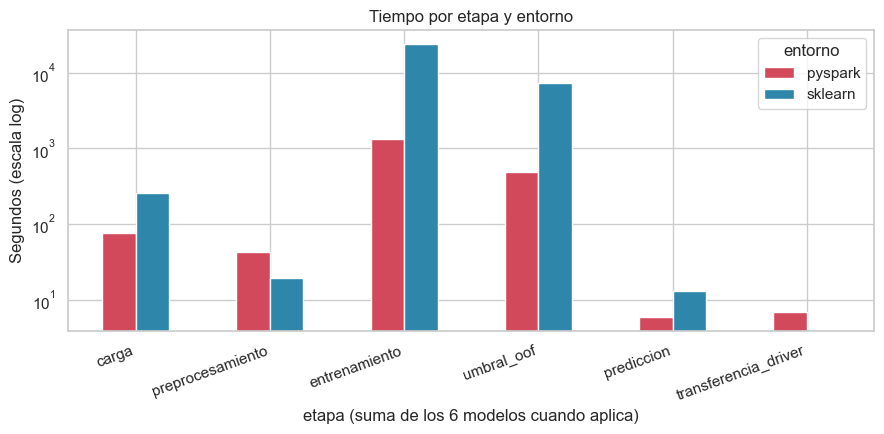

In [65]:
tiempos_df = pd.DataFrame(TIEMPOS)
tiempos_df.to_csv(ARTIFACTS_DIR / "tiempos_detalle.csv", index=False)
ORDEN_ETAPAS = ["carga", "preprocesamiento", "entrenamiento", "umbral_oof", "prediccion", "transferencia_driver"]
etapa_std = tiempos_df["etapa"].replace({"entrenamiento_gridsearchcv": "entrenamiento",
                                         "entrenamiento_crossvalidator": "entrenamiento"})
tiempos_etapa = (tiempos_df.assign(etapa=etapa_std).groupby(["etapa", "entorno"])["segundos"].sum()
                 .unstack("entorno").reindex(ORDEN_ETAPAS))
tiempos_etapa.index.name = "etapa (suma de los 6 modelos cuando aplica)"
display(tiempos_etapa.round(2).astype(object).where(tiempos_etapa.notna(), "no aplica"))
tiempos_etapa.to_csv(ARTIFACTS_DIR / "tiempos_por_etapa.csv")

ax = tiempos_etapa.fillna(0).plot(kind="bar", figsize=(9, 4.5), color=["#D1495B", "#2E86AB"], logy=True)
ax.set_ylabel("Segundos (escala log)")
ax.set_title("Tiempo por etapa y entorno")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
guardar_figura("tiempos_por_etapa")
plt.show()

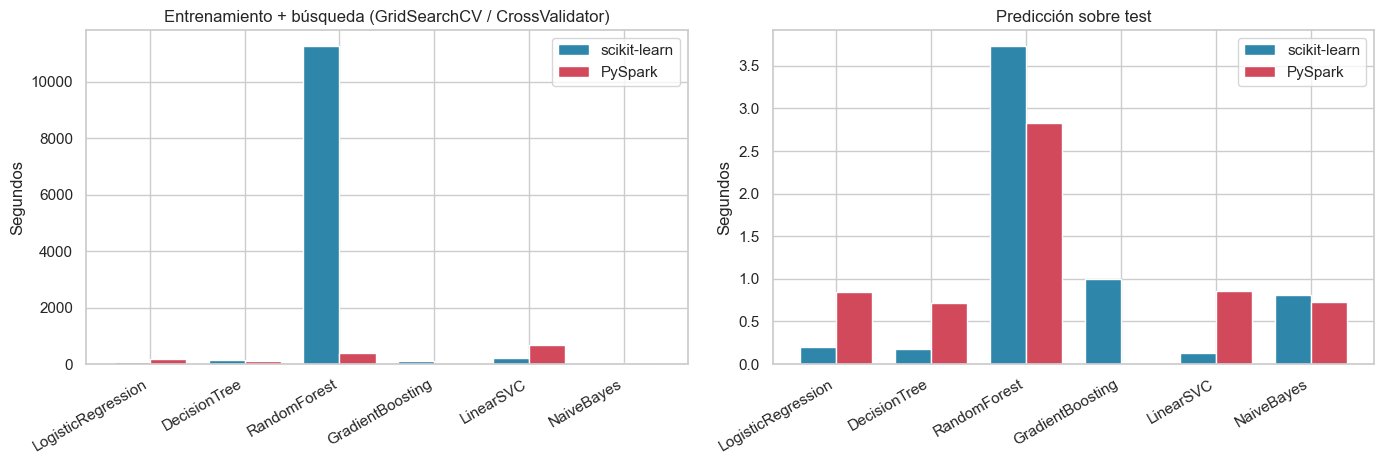

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
x = np.arange(len(MODELOS))
w = 0.38
for ax, col, titulo in ((axes[0], "tiempo_entrenamiento_s", "Entrenamiento + búsqueda (GridSearchCV / CrossValidator)"),
                        (axes[1], "tiempo_prediccion_s", "Predicción sobre test")):
    t_skl = [sklearn_results[m][col] for m in MODELOS]
    t_spk = [spark_results[m][col] if m in spark_results else np.nan for m in MODELOS]
    ax.bar(x - w / 2, t_skl, w, label="scikit-learn", color="#2E86AB")
    ax.bar(x + w / 2, t_spk, w, label="PySpark", color="#D1495B")
    ax.set_xticks(x)
    ax.set_xticklabels(MODELOS, rotation=30, ha="right")
    ax.set_ylabel("Segundos")
    ax.set_title(titulo)
    ax.legend()
plt.tight_layout()
guardar_figura("tiempos_por_modelo")
plt.show()

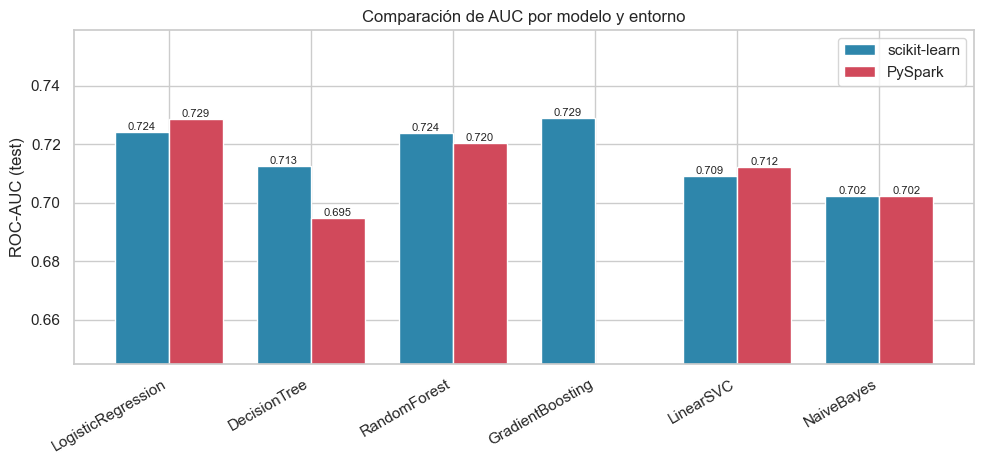

In [67]:
fig, ax = plt.subplots(figsize=(10, 4.8))
auc_skl = [sklearn_results[m]["roc_auc"] for m in MODELOS]
auc_spk = [spark_results[m]["roc_auc"] if m in spark_results else np.nan for m in MODELOS]
ax.bar(x - w / 2, auc_skl, w, label="scikit-learn", color="#2E86AB")
ax.bar(x + w / 2, auc_spk, w, label="PySpark", color="#D1495B")
for i, (a, b) in enumerate(zip(auc_skl, auc_spk)):
    ax.text(i - w / 2, a, f"{a:.3f}", ha="center", va="bottom", fontsize=8)
    if not np.isnan(b):
        ax.text(i + w / 2, b, f"{b:.3f}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(MODELOS, rotation=30, ha="right")
ax.set_ylim(max(0.0, np.nanmin(auc_skl + auc_spk) - 0.05), min(1.0, np.nanmax(auc_skl + auc_spk) + 0.03))
ax.set_ylabel("ROC-AUC (test)")
ax.set_title("Comparación de AUC por modelo y entorno")
ax.legend()
plt.tight_layout()
guardar_figura("comparacion_auc")
plt.show()

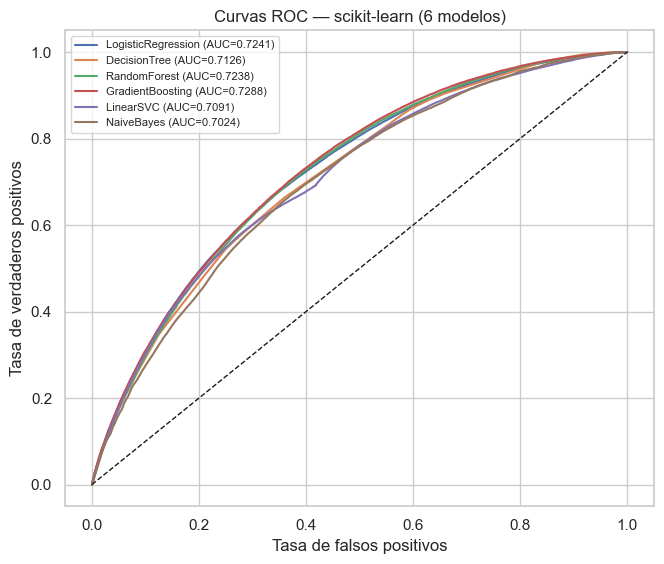

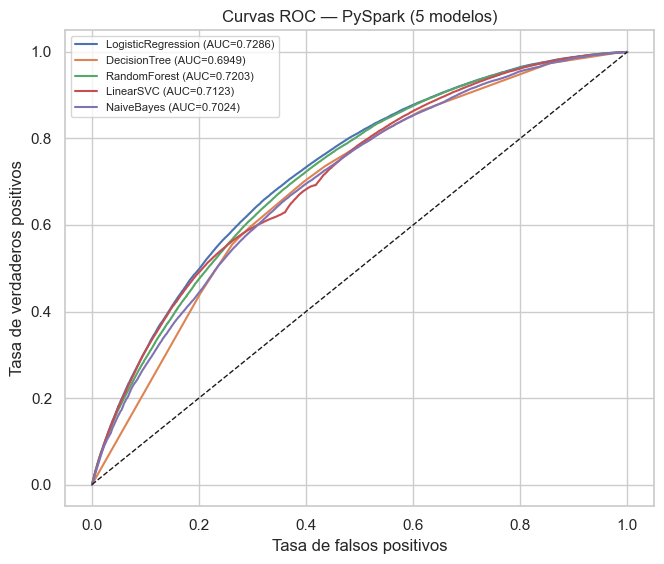

Heatmaps DeLong guardados: ['heatmap_delong_delta_sklearn.png', 'heatmap_delong_delta_spark.png', 'heatmap_delong_p_sklearn.png', 'heatmap_delong_p_spark.png']


In [68]:
def curva_roc_entorno(entorno, titulo, nombre_archivo, lista_modelos):
    plt.figure(figsize=(6.8, 5.8))
    for m in lista_modelos:
        fpr, tpr, _ = roc_curve(y_common, score_cols[(entorno, m)])
        plt.plot(fpr, tpr, label=f"{m} (AUC={roc_auc_score(y_common, score_cols[(entorno, m)]):.4f})")
    plt.plot([0, 1], [0, 1], "k--", lw=1)
    plt.xlabel("Tasa de falsos positivos")
    plt.ylabel("Tasa de verdaderos positivos")
    plt.title(titulo)
    plt.legend(fontsize=8)
    plt.tight_layout()
    guardar_figura(nombre_archivo)
    plt.show()


curva_roc_entorno("sklearn", f"Curvas ROC — scikit-learn ({len(MODELOS)} modelos)", "roc_sklearn", MODELOS)
curva_roc_entorno("spark", f"Curvas ROC — PySpark ({len(MODELOS_SPARK)} modelos)", "roc_pyspark", MODELOS_SPARK)
print("Heatmaps DeLong guardados:", sorted(p.name for p in FIG_DIR.glob("heatmap_delong_*.png")))

**Interpretación (comparación final):** 

Entre los 11 modelos (6 de sklearn y 5 de PySpark) no hay un entorno sistemáticamente más preciso. El mejor AUC es el boosting de sklearn (0.7288), apenas 0.0002 por encima de la regresión logística de Spark (0.7286), que a su vez tiene el mejor F1 (0.335). De los 5 modelos presentes en ambos entornos, sklearn gana en el árbol y el RandomForest, Spark en la regresión logística y LinearSVC, y NaiveBayes empata. Solo la diferencia del árbol (0.7126 frente a 0.6949) supera el margen práctico de 0.005. En tiempos, el resultado depende de la etapa: Spark carga los datos unas 6 veces más rápido (39.7 s frente a 255.4 s), pero sklearn preprocesa en menos de la mitad del tiempo (19.5 s frente a 42.6 s) y entrena unas 2 veces más rápido los cuatro modelos comparables sin RandomForest (469 s frente a 956 s). Por modelo, sklearn es más rápido en regresión logística, LinearSVC y NaiveBayes, y Spark solo en el árbol. El RandomForest no es comparable (11,255 s en sklearn frente a 376 s en Spark), porque las mallas difieren (9 combinaciones frente a 4), y el total de sklearn (11,836 s) está dominado por ese único modelo, de modo que no debe leerse como que Spark es 9 veces más rápido. La transferencia de resultados al driver es despreciable (6.9 s en total). GradientBoosting de PySpark no se completó, por lo que las comparaciones entre entornos se hacen sobre 5 modelos.

### 9.10.4.8.1. Experimento adicional: ¿a partir de qué volumen PySpark supera a scikit-learn?

**Este benchmark NO sustituye el entrenamiento principal.** Los modelos oficiales del proyecto (secciones 9.10.4.4 y
9.10.4.5) se entrenaron con **todas** las filas de train. Aquí, solo para medir tiempos, se entrena un único modelo
representativo —**regresión logística L2** con los mismos parámetros en ambos entornos (`regParam` fijo,
`C = 1/(regParam·n)`, máximo 100 iteraciones, sin búsqueda de hiperparámetros)— sobre subconjuntos crecientes y
anidados del **train** (100 000, 250 000, 500 000, 1 000 000 y el train completo), usando las mismas matrices ya
preprocesadas de cada entorno. Se mide únicamente el ajuste del modelo; en Spark el subconjunto se persiste y se
materializa antes de cronometrar.

n=   100,000 | sklearn=    0.73 s | PySpark=   21.16 s
n=   250,000 | sklearn=    2.97 s | PySpark=   17.93 s
n=   500,000 | sklearn=    2.87 s | PySpark=   15.31 s
n= 1,000,000 | sklearn=    5.06 s | PySpark=   12.54 s
n= 1,808,560 | sklearn=    8.45 s | PySpark=   17.02 s


,n_filas,sklearn_s,pyspark_s,ratio_spark_sobre_sklearn,mas_rapido
0,100000,0.733551,21.156164,28.840754,scikit-learn
1,250000,2.968837,17.932896,6.040377,scikit-learn
2,500000,2.868771,15.311254,5.337217,scikit-learn
3,1000000,5.057681,12.536377,2.478681,scikit-learn
4,1808560,8.453159,17.023529,2.013866,scikit-learn


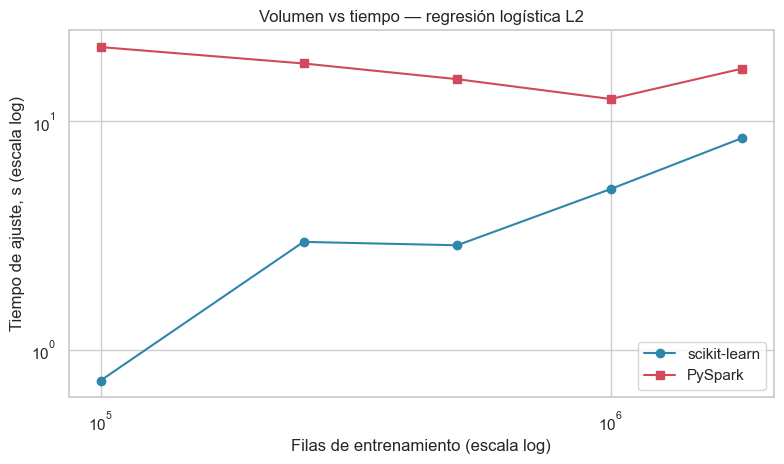

Con este hardware PySpark nunca superó a scikit-learn en el rango probado (hasta 1,808,560 filas).


In [69]:
BENCH_SIZES = [100_000, 250_000, 500_000, 1_000_000]   # + train completo
BENCH_REG_PARAM = 1e-5
BENCH_MAX_ITER = 100
BENCH_REPEATS = 1   # subir a 3 para reportar la mediana si el tiempo lo permite

# Orden aleatorio fijo de las filas de train -> subconjuntos anidados. Solo para este experimento de tiempos.
rng_bench = np.random.default_rng(RANDOM_STATE)
perm_bench = rng_bench.permutation(N_TRAIN)
bench_rank = np.empty(N_TRAIN, dtype=np.int64)
bench_rank[perm_bench] = np.arange(N_TRAIN)
BENCH_PATH = ARTIFACTS_DIR / "benchmark_orden_train.parquet"
pd.DataFrame({"id": train_df["id"].to_numpy(), "bench_rank": bench_rank}).to_parquet(BENCH_PATH, index=False)
sdf_bench_base = sdf_train_feat.join(spark.read.parquet(Path(BENCH_PATH).resolve().as_uri()), on="id", how="inner")

tamanos = sorted({s for s in BENCH_SIZES if s < N_TRAIN} | {N_TRAIN})
filas_bench = []
for n in tamanos:
    pos = np.sort(perm_bench[:n])   # filas de X_train con bench_rank < n
    X_sub, y_sub = X_train[pos], y_train[pos]
    sdf_sub = (sdf_bench_base.filter(F.col("bench_rank") < n).select("default", "features")
               .persist(StorageLevel.MEMORY_AND_DISK))
    assert sdf_sub.count() == n   # materializa el caché (no se cronometra)

    t_skl, t_spk = [], []
    for _ in range(BENCH_REPEATS):
        t0 = time.perf_counter()
        LogisticRegression(C=1.0 / (BENCH_REG_PARAM * n), solver="lbfgs", max_iter=BENCH_MAX_ITER).fit(X_sub, y_sub)
        t_skl.append(time.perf_counter() - t0)
        t0 = time.perf_counter()
        SparkLR(regParam=BENCH_REG_PARAM, elasticNetParam=0.0, maxIter=BENCH_MAX_ITER, labelCol="default",
                featuresCol="features").fit(sdf_sub)
        t_spk.append(time.perf_counter() - t0)
    sdf_sub.unpersist()
    filas_bench.append({"n_filas": n, "sklearn_s": float(np.median(t_skl)), "pyspark_s": float(np.median(t_spk))})
    print(f"n={n:>10,} | sklearn={filas_bench[-1]['sklearn_s']:8.2f} s | PySpark={filas_bench[-1]['pyspark_s']:8.2f} s")

benchmark_df = pd.DataFrame(filas_bench)
benchmark_df["ratio_spark_sobre_sklearn"] = benchmark_df["pyspark_s"] / benchmark_df["sklearn_s"]
benchmark_df["mas_rapido"] = np.where(benchmark_df["pyspark_s"] < benchmark_df["sklearn_s"], "PySpark", "scikit-learn")
display(benchmark_df)
benchmark_df.to_csv(ARTIFACTS_DIR / "benchmark_volumen_tiempo.csv", index=False)

plt.figure(figsize=(8, 4.8))
plt.plot(benchmark_df["n_filas"], benchmark_df["sklearn_s"], "o-", label="scikit-learn", color="#2E86AB")
plt.plot(benchmark_df["n_filas"], benchmark_df["pyspark_s"], "s-", label="PySpark", color="#D1495B")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Filas de entrenamiento (escala log)")
plt.ylabel("Tiempo de ajuste, s (escala log)")
plt.title("Volumen vs tiempo — regresión logística L2")
plt.legend()
plt.tight_layout()
guardar_figura("benchmark_volumen_tiempo")
plt.show()

spark_gana = benchmark_df[benchmark_df["pyspark_s"] < benchmark_df["sklearn_s"]]
if spark_gana.empty:
    conclusion_volumen = (f"Con este hardware PySpark nunca superó a scikit-learn en el rango probado "
                          f"(hasta {benchmark_df['n_filas'].max():,} filas).")
else:
    n_cruce = int(spark_gana["n_filas"].min())
    se_mantiene = bool((benchmark_df.loc[benchmark_df["n_filas"] >= n_cruce, "mas_rapido"] == "PySpark").all())
    conclusion_volumen = (f"PySpark empezó a ser más rápido a partir de ~{n_cruce:,} filas"
                          + (" y se mantuvo más rápido en los tamaños mayores." if se_mantiene
                             else ", pero no en todos los tamaños mayores (resultado no monótono)."))
print(conclusion_volumen)

**Interpretación (volumen):** 

El experimento entrenó una regresión logística L2 idéntica en ambos entornos (regParam = 1e-5, 100 iteraciones, sin búsqueda) sobre subconjuntos anidados de train, de 100,000 a 1,808,560 filas. PySpark no superó a scikit-learn en ningún tamaño probado. El tiempo de Spark es casi plano (entre 12.5 y 21.2 s), porque domina un costo fijo de planificación, serialización y arranque de tareas, mientras que el de sklearn crece de forma aproximadamente lineal (de 0.73 a 8.45 s). Por eso la razón Spark/sklearn baja de 28.8× a 2.0×, pero no llega a invertirse. Con estos datos no se puede estimar un punto de cruce: se hizo una sola repetición y el tiempo de Spark no es monótono (21.2, 17.9, 15.3, 12.5 y 17.0 s), con los primeros valores probablemente inflados por el calentamiento de la JVM. Además, entre 1 M y 1.8 M de filas el tiempo de Spark crece más rápido que el de sklearn (≈ 5.5 frente a 4.2 s por millón de filas), así que una extrapolación lineal tampoco produce cruce. Hay otras limitaciones: todo corre en una sola máquina (local[*]) con datos que caben en RAM (≈ 255 MB de matriz dispersa), donde Spark no tiene la ventaja para la que fue diseñado (escalar horizontalmente o manejar datos que no caben en un nodo); y el experimento mide un solo modelo, no el flujo completo con validación cruzada. En conclusión, con este hardware y hasta ≈ 1.8 millones de filas scikit-learn es más rápido, y el volumen a partir del cual Spark compensaría su sobrecosto no se alcanzó y requeriría más datos o más nodos.

## 9.10.5. Reflexión crítica

La celda siguiente **se completa automáticamente con los resultados reales** de esta ejecución (no hay cifras
escritas a mano). Debajo quedan las preguntas cualitativas para redactar con esos resultados.

In [70]:
def lista_md(items):
    return "\n".join(f"  - {i}" for i in items) if items else "  - ninguna"


t_ent = comparacion_final.groupby("entorno")["tiempo_entrenamiento_s"].sum()
rapido_por_modelo = [f"{m}: {'sklearn' if sklearn_results[m]['tiempo_entrenamiento_s'] < spark_results[m]['tiempo_entrenamiento_s'] else 'PySpark'}"
                     for m in MODELOS_AMBOS]
nota_faltantes = ("" if not MODELOS_FALTANTES_SPARK else
                  f"> **Limitación de esta ejecución:** los modelos de PySpark {MODELOS_FALTANTES_SPARK} no pudieron "
                  f"completarse en el equipo disponible (~7 GB de RAM; la JVM cayó tras 158 min). Las comparaciones entre "
                  f"entornos se realizan sobre los {len(MODELOS_AMBOS)} modelos presentes en ambos.")
mejor_global = comparacion_final.loc[comparacion_final["roc_auc"].idxmax()]
mejor_f1 = comparacion_final.loc[comparacion_final["f1"].idxmax()]


def sig_rel(tabla):
    sig = tabla[tabla["significativo_holm"]]
    rel = sig[sig["relevante_practica"]]
    return ([f"{r.modelo_1} vs {r.modelo_2}: ΔAUC={r.delta_auc:+.4f}, p Holm={r.p_ajustado_holm:.2e}" for r in sig.itertuples()],
            [f"{r.modelo_1} vs {r.modelo_2}: ΔAUC={r.delta_auc:+.4f}" for r in rel.itertuples()])


lineas_lime = [f"{r.entorno} / {r.modelo} / id {r.id}: {r.top_3}" for r in lime_resumen_df.itertuples()]
t_lime_skl = lime_resumen_df.loc[lime_resumen_df["entorno"] == "sklearn", "tiempo_s"].mean()
t_lime_spk = lime_resumen_df.loc[lime_resumen_df["entorno"] == "pyspark", "tiempo_s"].mean()
conteo_interp = resumen_tres_pruebas["interpretacion"].value_counts().to_dict()
n_misma = int((resumen_tres_pruebas["DeLong_vs_Boot_AUC"] == "misma conclusión").sum())
t_ent_skl, t_ent_spk = t_ent.get("sklearn", np.nan), t_ent.get("pyspark", np.nan)
impl_gb = sklearn_results["GradientBoosting"]["implementacion"]
bloques = []
for nombre, tabla in (("A. Entre entornos", delong_entre_entornos), ("B. Dentro de sklearn", delong_sklearn),
                      ("C. Dentro de PySpark", delong_spark)):
    sig, rel = sig_rel(tabla)
    bloques.append(f"- **{nombre}** — significativas tras Holm: {len(sig)} de {len(tabla)}; además relevantes "
                   f"(|ΔAUC| ≥ {PRACTICAL_AUC_MARGIN}): {len(rel)}\n{lista_md(rel)}")

texto = f"""
### Resultados observados en esta ejecución

**Hardware:** {hardware['sistema_operativo']}, Python {hardware['python']}, {hardware['cpu_fisicas']} CPU físicas /
{hardware['cpu_logicas']} lógicas, {hardware['ram_total_gb']} GB de RAM ({hardware['ram_disponible_gb']} GB disponibles al inicio).
Gradient boosting en sklearn: `{impl_gb}`.

{nota_faltantes}

**1. ¿Qué entorno fue más rápido?** Suma de entrenamiento + búsqueda de hiperparámetros: sklearn = {t_ent_skl:,.1f} s,
PySpark = {t_ent_spk:,.1f} s. Carga: sklearn = {t_sklearn_carga:,.1f} s, PySpark = {t_spark_carga:,.1f} s.
Preprocesamiento: sklearn = {t_sklearn_prep:,.1f} s, PySpark = {t_spark_prep:,.1f} s. Más rápido por modelo:
{lista_md(rapido_por_modelo)}

**2. ¿Cuál fue más preciso?** Mayor ROC-AUC: {mejor_global['modelo']} ({mejor_global['entorno']}) = {mejor_global['roc_auc']:.4f}.
Mayor F1: {mejor_f1['modelo']} ({mejor_f1['entorno']}) = {mejor_f1['f1']:.4f}.

**3–4. Diferencias de AUC (DeLong) significativas tras Holm y relevantes en la práctica:**
{chr(10).join(bloques)}

**5. Concordancia de las tres pruebas (DeLong, McNemar, bootstrap):** {conteo_interp}.
DeLong y bootstrap-ΔAUC con la misma conclusión en {n_misma} de {len(resumen_tres_pruebas)} comparaciones.

**6. Volumen:** {conclusion_volumen}

**7. LIME:** mejor modelo con probabilidades — sklearn: {mejor_sklearn}, PySpark: {mejor_spark}. Tiempo medio por explicación —
sklearn: {t_lime_skl:,.1f} s ({NUM_SAMPLES_SKLEARN_LIME} muestras),
PySpark: {t_lime_spk:,.1f} s ({NUM_SAMPLES_SPARK_LIME} muestras). Variables más influyentes:
{lista_md(lineas_lime)}
"""
display(Markdown(texto))
(ARTIFACTS_DIR / "reflexion_resultados_automaticos.md").write_text(texto, encoding="utf-8")


### Resultados observados en esta ejecución

**Hardware:** Windows 10, Python 3.9.25, 6 CPU físicas /
12 lógicas, 7.27 GB de RAM (0.52 GB disponibles al inicio).
Gradient boosting en sklearn: `HistGradientBoostingClassifier`.

> **Limitación de esta ejecución:** los modelos de PySpark ['GradientBoosting'] no pudieron completarse en el equipo disponible (~7 GB de RAM; la JVM cayó tras 158 min). Las comparaciones entre entornos se realizan sobre los 5 modelos presentes en ambos.

**1. ¿Qué entorno fue más rápido?** Suma de entrenamiento + búsqueda de hiperparámetros: sklearn = 11,836.5 s,
PySpark = 1,331.8 s. Carga: sklearn = 255.4 s, PySpark = 39.7 s.
Preprocesamiento: sklearn = 19.5 s, PySpark = 42.6 s. Más rápido por modelo:
  - LogisticRegression: sklearn
  - DecisionTree: PySpark
  - RandomForest: PySpark
  - LinearSVC: sklearn
  - NaiveBayes: sklearn

**2. ¿Cuál fue más preciso?** Mayor ROC-AUC: GradientBoosting (sklearn) = 0.7288.
Mayor F1: LogisticRegression (pyspark) = 0.3352.

**3–4. Diferencias de AUC (DeLong) significativas tras Holm y relevantes en la práctica:**
- **A. Entre entornos** — significativas tras Holm: 4 de 5; además relevantes (|ΔAUC| ≥ 0.005): 1
  - sklearn:DecisionTree vs spark:DecisionTree: ΔAUC=+0.0177
- **B. Dentro de sklearn** — significativas tras Holm: 14 de 15; además relevantes (|ΔAUC| ≥ 0.005): 12
  - sklearn:LogisticRegression vs sklearn:DecisionTree: ΔAUC=+0.0115
  - sklearn:LogisticRegression vs sklearn:LinearSVC: ΔAUC=+0.0150
  - sklearn:LogisticRegression vs sklearn:NaiveBayes: ΔAUC=+0.0217
  - sklearn:DecisionTree vs sklearn:RandomForest: ΔAUC=-0.0112
  - sklearn:DecisionTree vs sklearn:GradientBoosting: ΔAUC=-0.0163
  - sklearn:DecisionTree vs sklearn:NaiveBayes: ΔAUC=+0.0102
  - sklearn:RandomForest vs sklearn:GradientBoosting: ΔAUC=-0.0050
  - sklearn:RandomForest vs sklearn:LinearSVC: ΔAUC=+0.0148
  - sklearn:RandomForest vs sklearn:NaiveBayes: ΔAUC=+0.0214
  - sklearn:GradientBoosting vs sklearn:LinearSVC: ΔAUC=+0.0198
  - sklearn:GradientBoosting vs sklearn:NaiveBayes: ΔAUC=+0.0264
  - sklearn:LinearSVC vs sklearn:NaiveBayes: ΔAUC=+0.0067
- **C. Dentro de PySpark** — significativas tras Holm: 10 de 10; además relevantes (|ΔAUC| ≥ 0.005): 10
  - spark:LogisticRegression vs spark:DecisionTree: ΔAUC=+0.0337
  - spark:LogisticRegression vs spark:RandomForest: ΔAUC=+0.0083
  - spark:LogisticRegression vs spark:LinearSVC: ΔAUC=+0.0163
  - spark:LogisticRegression vs spark:NaiveBayes: ΔAUC=+0.0262
  - spark:DecisionTree vs spark:RandomForest: ΔAUC=-0.0254
  - spark:DecisionTree vs spark:LinearSVC: ΔAUC=-0.0175
  - spark:DecisionTree vs spark:NaiveBayes: ΔAUC=-0.0075
  - spark:RandomForest vs spark:LinearSVC: ΔAUC=+0.0080
  - spark:RandomForest vs spark:NaiveBayes: ΔAUC=+0.0179
  - spark:LinearSVC vs spark:NaiveBayes: ΔAUC=+0.0099

**5. Concordancia de las tres pruebas (DeLong, McNemar, bootstrap):** {'coinciden': 6, 'coinciden parcialmente': 1}.
DeLong y bootstrap-ΔAUC con la misma conclusión en 7 de 7 comparaciones.

**6. Volumen:** Con este hardware PySpark nunca superó a scikit-learn en el rango probado (hasta 1,808,560 filas).

**7. LIME:** mejor modelo con probabilidades — sklearn: GradientBoosting, PySpark: LogisticRegression. Tiempo medio por explicación —
sklearn: 0.2 s (5000 muestras),
PySpark: 13.3 s (500 muestras). Variables más influyentes:
  - sklearn / GradientBoosting / id 58191133: 0.00 < inq_last_12m_missing <= 1.00; 9.49 < int_rate <= 12.62; fico_range_low > 715.00
  - sklearn / GradientBoosting / id 8608795: int_rate > 15.61; 0.00 < inq_last_12m_missing <= 1.00; acc_open_past_24mths <= 2.00
  - pyspark / LogisticRegression / id 85138321: int_rate > 15.61; sub_grade=D2; inq_last_12m_missing <= 0.00
  - pyspark / LogisticRegression / id 42905253: sub_grade=C5; 0.00 < inq_last_12m_missing <= 1.00; 0.00 < all_util_missing <= 1.00


3856

### Preguntas para completar con los resultados de arriba

1. ¿Qué entorno fue más rápido y por qué? Depende de la etapa. Spark fue ≈ 6 veces más rápido en la carga de los 2.26 M
de filas (39.7 s frente a 255.4 s); sklearn fue más rápido en el preprocesamiento (19.5 s frente a 42.6 s) y en el
entrenamiento de los modelos comparables: en LR, LinearSVC y NaiveBayes por 1.7–2.9×, y en conjunto sin RF por ≈ 2×
(469 s frente a 956 s). Spark solo ganó en el árbol de decisión (1.3×) y en el RandomForest (376 s frente a 11,255 s), pero
esta última cifra no es comparable: la malla de Spark tiene 4 combinaciones y la de sklearn 9, e incluye numTrees = 100
y maxDepth = 15, las más caras. Razones: en modo local con 12 núcleos y datos que caben en RAM, Spark paga costos fijos de
planificación, serialización entre la JVM y Python y persistencia en memoria y disco, mientras que sklearn trabaja
directamente sobre arreglos en memoria; CrossValidator(parallelism=2) ejecuta solo 2 modelos a la vez frente al
GridSearchCV(n_jobs=-1) con hasta 12; y los árboles de Spark discretizan en 32 intervalos, lo que lo favorece frente a los
cortes exactos de sklearn. La paginación a disco por la escasa RAM (0.52 GB libres al iniciar) afectó a ambos.

2. ¿Cuál fue más preciso? Ninguno de forma sistemática. El mejor AUC es el boosting de sklearn (0.7288), a solo 0.0002 de
la regresión logística de Spark (0.7286), y el mejor F1 es el de LR en Spark (0.335). Entre los 5 modelos comunes, sklearn
gana en DT (+0.0177) y RF (+0.0035), Spark en LR (+0.0045) y LinearSVC (+0.0033), y NaiveBayes empata. La exactitud no es
informativa (ver pregunta 13).

3. ¿Qué diferencias de AUC fueron significativas tras Holm? Entre entornos, 4 de 5 (todas menos NaiveBayes). Dentro de
sklearn, 14 de 15 (la excepción es LR–RF). Dentro de PySpark, 10 de 10.

4. ¿Cuáles fueron además relevantes (|ΔAUC| ≥ 0.005)? Entre entornos, solo el DecisionTree (+0.0177). Dentro de sklearn,
12 de 15 (no lo son LR–RF, LR–GB y DT–LinearSVC; RF–GB está en el margen, 0.0050). Dentro de PySpark, las 10. La mayor parte
de las diferencias entre entornos es estadísticamente real pero pequeña.

5. ¿Qué diferencias de implementación pueden explicar las discrepancias?
- Árboles (maxBins = 32): Spark discretiza cada variable continua y sklearn busca cortes exactos. Es la explicación
  más plausible de la mayor diferencia (DT, 0.0177), y se agrava porque un árbol de profundidad 5 tiene como máximo 32
  hojas: el de Spark produce solo 11 scores distintos, lo que limita su capacidad de ordenar. Con RF el efecto se diluye
  al promediar árboles, y la diferencia baja a 0.0035 (además influye la malla menor de Spark).
- LR y LinearSVC: en sklearn la regularización eligió C = 0.00553 (la más fuerte) y en Spark regParam = 1e-6 (la más
  débil); la relación C = 1/(regParam·n) es solo aproximada. Además hay optimizadores distintos (lbfgs y liblinear
  frente a L-BFGS y OWLQN), distinto criterio de parada y estandarización interna en Spark. LinearSVC usa hinge en ambos.
- Preprocesamiento: mediana exacta (sklearn) frente a aproximada (Imputer de Spark) y moda frente a categoría «keep»
  para categorías faltantes; los scores de LR de sklearn y Spark tienen correlación 0.992, no 1.
- Validación cruzada: sklearn usa pliegues contiguos y Spark pliegues aleatorios (hipótesis, ver libro 2).
- Boosting: HistGradientBoosting (bins y paralelo) frente a GradientBoostingClassifier; sin contraparte en Spark.
- NaiveBayes: mismo algoritmo, sin diferencias (correlación 1.0000).

6. ¿Qué limitaciones tiene DeLong? (a) Solo captura la variabilidad del muestreo del test, no la del entrenamiento: el mismo
DT de Spark varió ≈ 0.002 de AUC entre dos ejecuciones; (b) supone observaciones independientes; (c) el AUC resume todos los
umbrales y puede no reflejar el umbral operativo; (d) con scores muy empatados (DT) la varianza es menos fiable; (e) con
452 mil observaciones, casi todo es significativo, por lo que se usó el margen de 0.005.

7. ¿Cómo complementan McNemar y el bootstrap? McNemar compara decisiones concretas en el umbral de cada modelo, sin
suponer normalidad ni un AUC; es sensible a la elección del umbral y trata todos los errores por igual, lo que con 12 % de
incumplimientos significa que domina el conteo de falsos positivos. El bootstrap pareado no necesita fórmula de varianza y
extiende la comparación a ΔAUC-PR y ΔF1, que son las métricas relevantes para la clase minoritaria. Hay que tener cuidado
con el AUC-PR trapezoidal cuando hay pocos umbrales (caso del árbol).

8. ¿Coinciden las tres pruebas? DeLong y el bootstrap-ΔAUC coinciden en 7 de 7 comparaciones, y McNemar es significativo
en las 7. La única discrepancia es NaiveBayes entre entornos (sin diferencia en AUC pero McNemar significativo por umbrales
distintos, 0.0280 y 0.0250). Es la señal de que McNemar mide puntos de operación; otro ejemplo es GB vs LR de sklearn, donde
AUC favorece a GB y McNemar y ΔF1 favorecen a LR.

9. ¿A partir de qué volumen supera PySpark a scikit-learn? No lo superó en ningún tamaño probado (100 mil a 1.81 M
filas). La razón Spark/sklearn bajó de 28.8× a 2.0×, pero con una repetición y un solo nodo no se puede estimar un cruce. Ver
la sección G.

10. ¿Qué aporta LIME? Explica errores concretos: en los falsos negativos revela que el modelo veía perfiles de bajo riesgo
(tasa baja, FICO alto) que incumplieron igualmente, un límite de información al originar el préstamo; y permite detectar que
el indicador de faltante inq_last_12m_missing es una de las señales locales dominantes, lo que obliga a revisar si mide riesgo o
antigüedad del préstamo. También deja ver la colinealidad en el modelo lineal (pesos de signo opuesto en variables que casi
siempre faltan juntas).

11. ¿Qué limitaciones tiene LIME en Spark? Opera en memoria local aunque el modelo sea distribuido: cada lote de
perturbaciones es un trabajo de Spark (13.3 s por explicación frente a 0.2 s), por eso se usaron 500 perturbaciones en lugar
de 5,000 y las explicaciones son menos estables; necesita el modelo y una muestra de fondo en el driver (no escala a todo el
dataset); en Windows sin winutils el modelo no se guarda y se reajusta; y como técnica general perturba variables por
separado (combinaciones irreales con variables colineales) y es local y no causal.

12. ¿Qué efecto tuvieron las condiciones obligatorias?
- Partición común por id (Parquet): hace válidas las pruebas pareadas: mismas 452,141 observaciones y 53,712 positivos
  en ambos entornos (8 comprobaciones verificadas); sin esto DeLong y McNemar no tendrían sentido.
- Sin toPandas()/collect() antes de entrenar y persist tras el ensamblado: los datos permanecen en Spark; la
  transferencia posterior de solo id, default y score cuesta 0.9–2.0 s por modelo (6.9 s en total).
- Configuración de Spark (4g y 64 particiones en lugar de 8g y 400): se ajustó a 7.27 GB de RAM; con 8g se paginaba y
  la JVM caía. Los resultados de modelado no cambian (la partición es por id), solo los tiempos. Aun así, el GBT no
  completó.
- GridSearchCV sin Pipeline: el preprocesamiento se ajusta una vez con todo train, de modo que el CV queda
  ligeramente optimista, pero el test queda intacto.
- n_jobs=-1 frente a parallelism=2: asimetría de paralelismo que favorece a sklearn en tiempos.
- Dataset completo, sin remuestreo: hace caro el RF de sklearn (3.1 h) y el GBT de Spark (no completó); es lo que
  vuelve relevante la elección del algoritmo por su costo.
- Mismos pesos de clase en ambos entornos: garantizan que las diferencias no vengan del tratamiento del desbalance.

13. ¿Cómo se trató el desbalance y qué efecto tuvo? Con pesos «balanced» (w₀ = 0.567, w₁ = 4.209; razón 7.42), sin
remuestreo, y un umbral por modelo que maximiza el F1 de la clase minoritaria con predicciones out-of-fold de train. La
línea base «predecir siempre 0» da exactitud 0.881, recall 0 y F1 0. Los modelos bajan la exactitud a 0.60–0.76 pero
detectan entre 50 % y 69 % de los incumplimientos (F1 de 0.29 a 0.335) con precisiones de 0.18–0.25, es decir 1.5–2.1 veces la
tasa base: el compromiso precisión/recall es evidente (LinearSVC: máximo recall, mínima precisión). Los umbrales resultantes
(≈ 0.56–0.60 en los modelos de probabilidad con pesos, 0.025 en NaiveBayes, ≈ 1.0 en el margen de LinearSVC) reflejan que
los pesos desplazan las probabilidades y que NaiveBayes y SVM no producen probabilidades calibradas. McNemar compara puntos de
operación distintos por modelo, por eso hay que leerlo junto con DeLong. Nota: no se ejecutó una corrida sin pesos, así que
«el AUC cambia poco con los pesos» es una expectativa teórica y no un resultado medido; no la afirmes como dato.



## Validación final automática

Comprueba las condiciones del enunciado con los objetos de esta ejecución y, cuando hace falta, revisando el código
fuente del propio notebook (se ignoran los comentarios y esta celda). Cada fila indica si la condición se cumple.

In [71]:
# @validacion_final  (esta celda se excluye de la revisión del código fuente)
import json as _json
import re as _re

checks = []


def check(nombre, ok, detalle=""):
    checks.append({"condicion": nombre, "cumple": bool(ok), "detalle": detalle})


# --- Código fuente del notebook (sin comentarios ni esta celda) ---
nb_path = next((p for p in [Path("2_Modelado.ipynb")] + sorted(Path(".").glob("*Modelado*.ipynb")) if p.exists()), None)
codigo = None
if nb_path is not None:
    celdas = _json.loads(nb_path.read_text(encoding="utf-8"))["cells"]
    lineas = []
    for c in celdas:
        fuente = "".join(c["source"])
        if c["cell_type"] != "code" or "@validacion_final" in fuente:
            continue
        lineas += [ln.split("#")[0] for ln in fuente.splitlines()]
    codigo = "\n".join(lineas)


def no_aparece(patron):
    return None if codigo is None else _re.search(patron, codigo) is None


def fuente_ok(valor):
    if valor is None:
        return False, "no verificable: no se encontró 2_Modelado.ipynb guardado en la carpeta de trabajo"
    return valor, ""


check("No se redujeron filas en el modelado principal (sklearn)", X_train.shape[0] + X_test.shape[0] == N_TOTAL,
      f"{X_train.shape[0]:,} + {X_test.shape[0]:,} = {N_TOTAL:,}")
check("No se redujeron filas en el modelado principal (Spark)", n_train_spark + n_test_spark == N_TOTAL,
      f"{n_train_spark:,} + {n_test_spark:,} = {N_TOTAL:,}")
check("sklearn y Spark usan exactamente el mismo test",
      set(scores_all["id"]) == set(ids_test) and len(scores_all) == len(ids_test) == n_test_spark)
check("split_assignment.parquet con columnas id y split", list(pd.read_parquet(SPLIT_PATH).columns) == ["id", "split"])
check("GridSearchCV cv=3", all(g.cv == 3 for g in sklearn_gridsearch.values()))
check('GridSearchCV scoring="roc_auc"', all(g.scoring == "roc_auc" for g in sklearn_gridsearch.values()))
check("GridSearchCV n_jobs=-1", all(g.n_jobs == -1 for g in sklearn_gridsearch.values()))
check("No se usa Pipeline en GridSearchCV de sklearn",
      not any(isinstance(g.estimator, SkPipeline) for g in sklearn_gridsearch.values()))
check("RandomForest sklearn con n_jobs=1 (sin paralelización anidada)",
      sklearn_gridsearch["RandomForest"].estimator.n_jobs == 1)
ok, det = fuente_ok(None if codigo is None else codigo.count("ParamGridBuilder()") >= 6)
check("Spark usa ParamGridBuilder (6 modelos)", ok, det)
check("Spark usa CrossValidator numFolds=3", all(cv.getNumFolds() == 3 for cv in spark_cv.values()))
check('Spark evaluator areaUnderROC', all(cv.getEvaluator().getMetricName() == "areaUnderROC" for cv in spark_cv.values()))
check("Spark usa cache/persist", sdf_train_feat.is_cached and sdf_test_feat.is_cached)
ok, det = fuente_ok(no_aparece(r"\.randomSplit\("))
check("Spark no usa randomSplit", ok, det)
ok, det = fuente_ok(None if codigo is None else all(
    no_aparece(p) for p in (r"monotonically_increasing_id", r"row_number\(", r"Window\.orderBy")))
check("Spark no recrea IDs (monotonically_increasing_id / row_number / Window.orderBy)", ok, det)
if codigo is not None:
    pos_fit = codigo.find("cv.fit(")
    pos_transfer = [m.start() for m in _re.finditer(r"\.toPandas\(|\.collect\(", codigo)]
    ok_transfer = pos_fit >= 0 and all(p > pos_fit for p in pos_transfer)
else:
    ok_transfer = None
ok, det = fuente_ok(ok_transfer)
check("Sin toPandas/collect antes del entrenamiento (código)", ok, det)
check("Transferencias solo del test (id, default, score)",
      len(TRANSFER_LOG) == len(MODELOS_SPARK) and all(t["filas"] == n_test_spark and t["columnas"] == ["id", "default", "score"]
                                     for t in TRANSFER_LOG))
check(f"Modelos por entorno (sklearn {len(MODELOS)} / PySpark {len(MODELOS_SPARK)})",
      list(sklearn_results) == MODELOS and list(spark_results) == MODELOS_SPARK,
      f"ausentes en PySpark: {MODELOS_FALTANTES_SPARK or 'ninguno'}")
check("Desbalance: pesos de clase en los seis modelos de sklearn",
      all(str(r.get("pesos", "")).startswith(("class_weight", "sample_weight")) for r in sklearn_results.values()))
check("Desbalance: weightCol='peso' en los seis estimadores de Spark",
      all(cv.getEstimator().getWeightCol() == "peso" for cv in spark_cv.values()))
check("Pesos de clase idénticos en sklearn y Spark", bool(np.allclose(pesos_sklearn, [PESO_NEG, PESO_POS])))
check("Umbral por (entorno, modelo) definido con train (out-of-fold)",
      all(("sklearn", m) in UMBRALES for m in MODELOS) and all(("spark", m) in UMBRALES for m in MODELOS_SPARK))
check("accuracy, precision, recall, F1 y ROC AUC presentes",
      {"accuracy", "precision", "recall", "f1", "roc_auc"} <= set(comparacion_final.columns))
check(f"Matrices de confusión ({len(MODELOS) + len(MODELOS_SPARK)})", all(len(r["matriz_confusion"]) == 2 for r in
                                         list(sklearn_results.values()) + list(spark_results.values())))
check("Scores continuos con ID guardados", all("id" in pd.read_parquet(ARTIFACTS_DIR / f).columns
                                               for f in ("sklearn_scores_test.parquet", "spark_scores_test.parquet")))
check("Fast DeLong validado contra DeLong directo", DELONG_VALIDACION_OK,
      f"dif. máx = {validacion_delong['dif_abs'].max():.1e}")
check(f"{N_PARES_EE} comparaciones DeLong entre entornos", len(delong_entre_entornos) == N_PARES_EE)
check("Comparaciones DeLong internas por entorno", len(delong_sklearn) == N_PARES_SKL and len(delong_spark) == N_PARES_SPK,
      f"sklearn={N_PARES_SKL}, PySpark={N_PARES_SPK}")
check("Holm aplicado (DeLong, McNemar, bootstrap)",
      "p_ajustado_holm" in delong_todas and "p_ajustado_holm" in mcnemar_df and "delta_auc_p_holm" in bootstrap_df)
check("Margen de relevancia práctica 0.005", PRACTICAL_AUC_MARGIN == 0.005 and "relevante_practica" in delong_todas)
check("McNemar incluido (entre entornos + top-2 sklearn + top-2 Spark)", len(mcnemar_df) == len(MODELOS_AMBOS) + 2)
check("Bootstrap con al menos 2000 iteraciones", (bootstrap_df["B"] >= 2000).all())
check("Bootstrap incluye ROC-AUC, AUC-PR y F1",
      {"delta_auc_media", "delta_auc_pr_media", "delta_f1_media"} <= set(bootstrap_df.columns))
check("LIME en ambos entornos (HTML y PNG)",
      set(lime_resumen_df["entorno"]) == {"sklearn", "pyspark"}
      and all(Path(p).exists() for p in lime_resumen_df["html"]) and all(Path(p).exists() for p in lime_resumen_df["png"]))
check("Tiempos requeridos medidos",
      {("sklearn", e) for e in ("carga", "preprocesamiento", "entrenamiento_gridsearchcv", "prediccion")}
      | {("pyspark", e) for e in ("carga", "preprocesamiento", "entrenamiento_crossvalidator", "prediccion",
                                   "transferencia_driver")}
      <= set(zip(tiempos_df["entorno"], tiempos_df["etapa"])))
check("Hardware real reportado (hardware.csv)", (ARTIFACTS_DIR / "hardware.csv").exists())
check("Curvas ROC por entorno", (FIG_DIR / "roc_sklearn.png").exists() and (FIG_DIR / "roc_pyspark.png").exists())
check("Heatmaps DeLong (4)", len(list(FIG_DIR.glob("heatmap_delong_*.png"))) == 4)
check("Tabla comparativa final", (ARTIFACTS_DIR / "comparacion_final.csv").exists() and len(comparacion_final) == len(MODELOS) + len(MODELOS_SPARK))
check("Benchmark separado por volumen", (ARTIFACTS_DIR / "benchmark_volumen_tiempo.csv").exists()
      and benchmark_df["n_filas"].max() == N_TRAIN)

validacion_final = pd.DataFrame(checks)
validacion_final["cumple"] = validacion_final["cumple"].map({True: "✔", False: "✘"})
display(validacion_final)
validacion_final.to_csv(ARTIFACTS_DIR / "validacion_final.csv", index=False)
n_fallos = int((validacion_final["cumple"] == "✘").sum())
print("Todas las condiciones se cumplen." if n_fallos == 0 else f"ATENCIÓN: {n_fallos} condición(es) sin cumplir.")

,condicion,cumple,detalle
0,No se redujeron filas en el modelado principal...,✔,"1,808,560 + 452,141 = 2,260,701"
1,No se redujeron filas en el modelado principal...,✔,"1,808,560 + 452,141 = 2,260,701"
2,sklearn y Spark usan exactamente el mismo test,✔,
3,split_assignment.parquet con columnas id y split,✔,
4,GridSearchCV cv=3,✔,
5,"GridSearchCV scoring=""roc_auc""",✔,
6,GridSearchCV n_jobs=-1,✔,
7,No se usa Pipeline en GridSearchCV de sklearn,✔,
8,RandomForest sklearn con n_jobs=1 (sin paralel...,✔,
9,Spark usa ParamGridBuilder (6 modelos),✔,


ATENCIÓN: 2 condición(es) sin cumplir.


Con el dataset completo (2.26 M de préstamos, 11.9 % incumple) los once modelos comparados discriminan de forma moderada y
muy parecida (AUC 0.695–0.729): lo que limita el rendimiento es la información disponible al originar el préstamo más que el
algoritmo o el entorno. scikit-learn y PySpark son equivalentes en precisión (la única diferencia relevante es el árbol de
decisión, por discretización en maxBins) y scikit-learn es más rápido en la mayoría de los modelos comparables (LR,
LinearSVC y NaiveBayes; solo el árbol de decisión fue algo más rápido en Spark) y en todos los volúmenes probados,
hasta 1.8 M de filas en una sola máquina. El costo computacional es muy desigual entre modelos: la
regresión logística (86 s) iguala al RandomForest (3.1 h), y el boosting es lo único que no pudo ejecutarse en PySpark con
7 GB de RAM. Las diferencias estadísticamente significativas son abundantes por el tamaño del test, y solo unas pocas superan
el margen de relevancia práctica de 0.005. LIME muestra que los errores vienen de perfiles de bajo riesgo que incumplen y de
una fuerte dependencia del indicador de faltante, lo que merece revisión antes de usar el modelo en producción.
